# *Global Settings*

In [1]:
# import pandas as pd
# df_matlab = pd.read_csv(r"Inputs\GPS User Data\Datos de MATLAB GPS.csv")

# print(df_matlab.head(10).to_markdown())

In [2]:
# import pandas as pd
# df_veraset = pd.read_parquet(r"Inputs\GPS User Data\prueba_dummy_3.parquet")

# print(df_veraset.head(10).to_markdown())

In [3]:
import pandas as pd
import numpy as np
import osmnx as ox
import geopandas as gpd
from pathlib import Path
import pickle
import os
import warnings
import networkx as nx
import igraph as ig

warnings.filterwarnings('ignore')

# ==============================================================================
# 0. CONFIGURACIÓN DE RUTAS PORTABLES
# ==============================================================================
BASE_DIR = Path.cwd()

# --- DEFINICIÓN DE CARPETAS --- 
INPUTS_DIR = BASE_DIR / "Inputs"
INFRA_DIR = INPUTS_DIR / "Infrastructure"
CACHE_INFRA_DIR = INFRA_DIR / "Cache_Optimizado" # <-- Nueva carpeta de caché
RATES_DIR = INPUTS_DIR / "Emission rates"
GPS_DIR = INPUTS_DIR / "GPS User Data"

OUTPUTS_DIR = BASE_DIR / "Outputs"
INTERMEDIATE_DIR = OUTPUTS_DIR / "Intermediate Outputs"
FINAL_DIR = OUTPUTS_DIR / "Final Outputs"

# Creación automática de carpetas
for folder in [INFRA_DIR, CACHE_INFRA_DIR, RATES_DIR, GPS_DIR, INTERMEDIATE_DIR, FINAL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# --- DEFINICIÓN DE ARCHIVOS BASE ---
FILE_GRAFO = INFRA_DIR / "monterrey_drive_network_V1.pkl"
FILE_GRAFO_WALK = INFRA_DIR / "monterrey_walk_network_EydanV1.pkl" 
FILE_METRO = INFRA_DIR / "lineas_metrorrey.csv"
FILE_BUS = INFRA_DIR / "rutas_buses_ZMM_oficial.geojson"

# Veraset data.
# FILE_GPS_ORIGINAL = GPS_DIR / "prueba_dummy_3.parquet"
FILE_GPS_ORIGINAL = GPS_DIR / "top_20users_1_month.parquet"
# MATLAB Data.
# FILE_GPS_ORIGINAL = GPS_DIR / "Datos de MATLAB GPS.csv"

FILE_MOVES = RATES_DIR / "cleaned_emission_rates_formatted_SB.parquet"

# --- ARCHIVOS DE CACHÉ (PARA OPTIMIZACIÓN) ---
# Estos archivos se generan la primera vez y ahorran 20 minutos en las siguientes
FILE_CACHE_EDGES_DRIVE = CACHE_INFRA_DIR / "edges_drive.parquet"
FILE_CACHE_EDGES_WALK = CACHE_INFRA_DIR / "edges_walk.parquet"
FILE_CACHE_IG_DRIVE = CACHE_INFRA_DIR / "ig_drive_y_map.pkl"
FILE_CACHE_IG_WALK = CACHE_INFRA_DIR / "ig_walk_y_map.pkl"

# --- ARCHIVOS DE SALIDA ---
FILE_INTERMEDIO = INTERMEDIATE_DIR / "Rutas_Completadas_Clasificadas_VERASET.parquet"
FILE_FINAL_PARQUET = FINAL_DIR / "Resultados_Datos_Emisiones_GPS_VERASET.parquet"
FILE_FINAL_CSV = FINAL_DIR / "Resultados_Mapa_Emisiones_GPS_Kepler_VERASET.csv"

print(f"Estructura de directorios lista en: {BASE_DIR}")

Estructura de directorios lista en: c:\Users\Eydan\OneDrive\Escritorio\ITESM\MAITEC Lab\Eventos Masivos\GPS_Emissions_Project_Pipeline-v2.0


# **MODULE 1: Código de Modos de Transporte**

## M1 Input files and settings

In [4]:
import pandas as pd
import numpy as np
import geopandas as gpd
from scipy.spatial import KDTree
from shapely import wkt
import shapely.geometry

print("Cargando infraestructura de transporte...")
bus_routes = gpd.read_file(FILE_BUS)
subway_df = pd.read_csv(FILE_METRO)

# Convertimos la columna de texto a geometría espacial
if 'geometry' in subway_df.columns:
    subway_df['geometry'] = subway_df['geometry'].apply(wkt.loads)
    subway_routes = gpd.GeoDataFrame(subway_df, geometry='geometry', crs="EPSG:4326")
elif 'WKT' in subway_df.columns:
    subway_df['geometry'] = subway_df['WKT'].apply(wkt.loads)
    subway_routes = gpd.GeoDataFrame(subway_df, geometry='geometry', crs="EPSG:4326")
elif 'lat' in subway_df.columns and 'lon' in subway_df.columns:
    subway_routes = gpd.GeoDataFrame(subway_df, geometry=gpd.points_from_xy(subway_df.lon, subway_df.lat), crs="EPSG:4326")
else:
    raise ValueError("¡ALERTA! Revisa las columnas del archivo del metro.")

# ---------------------------------------------------------
# CORRECCIÓN METODOLÓGICA: PROYECCIÓN Y CACHÉ ESPACIAL
# ---------------------------------------------------------
bus_routes = bus_routes.to_crs("EPSG:32614")
subway_routes = subway_routes.to_crs("EPSG:32614")

print("Generando Índices Espaciales (R-Trees) globales...")
_ = subway_routes.sindex 
_ = bus_routes.sindex
print("Infraestructura lista.")

Cargando infraestructura de transporte...
Generando Índices Espaciales (R-Trees) globales...
Infraestructura lista.


## M1 Functions y Asignación Modal

In [5]:
import networkx as nx

def calcular_cercania_infraestructura(df, subway_routes, bus_routes):
    """Calcula cercanía al metro/bus usando distancias MÉTRICAS exactas a la línea."""
    
    # 1. Proyectar temporalmente a UTM 14N
    gdf_pts = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")
    gdf_pts = gdf_pts.to_crs("EPSG:32614")
    
    RADIO_BUSQUEDA_METROS = 150
    
    # 2. Búsqueda Espacial Exacta (sjoin_nearest mide a la LÍNEA, no al centroide)
    # --- METRO ---
    metro_join = gpd.sjoin_nearest(gdf_pts, subway_routes, how='left', distance_col='dist_metro')
    metro_join = metro_join[~metro_join.index.duplicated(keep='first')] # Limpiar empates de distancia
    df['near_subway_line'] = (metro_join['dist_metro'] < RADIO_BUSQUEDA_METROS).astype(int)
    
    # --- BUS ---
    bus_join = gpd.sjoin_nearest(gdf_pts, bus_routes, how='left', distance_col='dist_bus')
    bus_join = bus_join[~bus_join.index.duplicated(keep='first')] 
    df['near_bus_route'] = (bus_join['dist_bus'] < RADIO_BUSQUEDA_METROS).astype(int)
    
    return df

def clasificar_viajes(df):
    """Modelo Bayesiano completo (4 variables) original, 100% Vectorizado y Normalizado."""
    modos = ['Carro', 'Bus', 'Metro', 'Caminar']
    
    # --- MATRICES ORIGINALES (Tomadas de 4_Clasificación.ipynb) ---
    Cercania = np.array([[0.10, 0.10, 0.80, 0.00],
                        [0.10, 0.80, 0.00, 0.10],
                        [0.40, 0.25, 0.05, 0.30]])

    Velocidad = np.array([[0.05, 0.10, 0.15, 0.60],
                        [0.47, 0.38, 0.05, 0.10],
                        [0.50, 0.30, 0.20, 0.00],
                        [1.00, 0.00, 0.00, 0.00]])

    Distancia = np.array([[0.10, 0.20, 0.30, 0.40],
                        [0.25, 0.25, 0.30, 0.20],
                        [0.40, 0.15, 0.25, 0.20],
                        [0.60, 0.30, 0.00, 0.10],
                        [0.40, 0.40, 0.00, 0.20]])

    Velprom = np.array([[0.10, 0.10, 0.20, 0.60],
                        [0.40, 0.25, 0.25, 0.10]])

    # --- PREPARAR VARIABLES FALTANTES POR VIAJE ---
    # Calculamos la distancia total y velocidad promedio del viaje al vuelo para este usuario
    mask_viajes = df['trip'] > 0
    df['dist_total_km'] = 0.0
    df['avg_speed_trip'] = 0.0
    
    if mask_viajes.any():
        df.loc[mask_viajes, 'dist_total_km'] = df[mask_viajes].groupby('trip')['dis lineal [m]'].transform('sum') / 1000.0
        df.loc[mask_viajes, 'avg_speed_trip'] = df[mask_viajes].groupby('trip')['Speed [km/h]'].transform('mean')

    # --- PASO 1: ÍNDICES VECTORIZADOS (Filtros de variables) ---
    # Cercanía: 0 (Metro), 1 (Bus), 2 (Ninguno)
    idx_c = np.where(df['near_subway_line'] == 1, 0, 
            np.where(df['near_bus_route'] == 1, 1, 2))

    idx_v = np.digitize(df['Speed [km/h]'].fillna(0), bins=[6.001, 20.001, 80.001])
    idx_d = np.digitize(df['dist_total_km'], bins=[1.0, 6.001, 10.001, 18.001])
    idx_vp = np.digitize(df['avg_speed_trip'], bins=[6.001])
    
    # --- PASO 2: BAYES Y NORMALIZACIÓN POR PUNTOS ---
    # Multiplicación matricial (No normalizada)
    P_unnorm = Cercania[idx_c] * Velocidad[idx_v] * Distancia[idx_d] * Velprom[idx_vp]
    
    # Normalización: Hacemos que las probabilidades de los 4 modos sumen 1.0 en cada fila
    suma_puntos = P_unnorm.sum(axis=1, keepdims=True)
    suma_puntos[suma_puntos == 0] = 1 # Prevenir división por cero
    P_norm_puntos = P_unnorm / suma_puntos
    
    df_probs = pd.DataFrame(P_norm_puntos, columns=modos, index=df.index)
    df_probs['trip'] = df['trip']
    
    # --- PASO 3: SUMA DE PROBABILIDADES Y VOTACIÓN POR VIAJE ---
    viajes_df = df_probs[df_probs['trip'] > 0]
    
    if not viajes_df.empty:
        # Acumulamos el peso probabilístico de todos los puntos GPS dentro de un mismo viaje
        suma_por_viaje = viajes_df.groupby('trip')[modos].sum()
        # Seleccionamos el modo que obtuvo la mayor probabilidad global para ese viaje
        modos_ganadores = suma_por_viaje.idxmax(axis=1) 
        df['modo_transporte'] = df['trip'].map(modos_ganadores)
    else:
        df['modo_transporte'] = np.nan
        
    # --- PASO 4: LIMPIEZA DE PARADAS Y MEMORIA ---
    df.loc[df['trip'] <= 0, 'modo_transporte'] = 'Parada'
    df.drop(columns=['dist_total_km', 'avg_speed_trip'], inplace=True, errors='ignore')
    
    return df

In [6]:
# import pandas as pd
# import numpy as np

# def inyectar_datos_matlab_a_modulo2(FILE_GPS_ORIGINAL):
#     """
#     Carga los datos etiquetados manualmente de MATLAB y los formatea 
#     para que sean indistinguibles del output del Módulo 1.
#     """
#     print("Cargando Verdad Absoluta (Ground Truth) desde MATLAB...")
#     # low_memory=False evita el DtypeWarning que mencionaste
#     df = pd.read_csv(FILE_GPS_ORIGINAL, low_memory=False)
    
#     # 1. Renombrar columnas al estándar del Pipeline (Veraset + Mod 1)
#     # Tomamos 'etiqueta_transporte' porque asumo que es la decisión final manual/corregida.
#     renombrar = {
#         'lat': 'latitude',
#         'lon': 'longitude',
#         'Timestamp': 'local_timestamp',
#         'speed': 'Speed [km/h]',
#         'etiqueta_transporte': 'modo_transporte' 
#     }
#     df = df.rename(columns=renombrar)
    
#     # 2. Formateo de Tiempos (Crítico para calcular distancias/velocidades en ruteo)
#     df['local_timestamp'] = pd.to_datetime(df['local_timestamp'])
    
#     # 3. Estandarización de la variable 'modo_transporte'
#     # El Módulo 2 espera Capitalizadas: 'Caminar', 'Carro', 'Bus', 'Metro', 'Parada'
#     mapeo_modos = {
#         'caminar': 'Caminar',
#         'carro': 'Carro',
#         'bus': 'Bus',
#         'metro': 'Metro',
#         'parada': 'Parada'
#     }
#     # Forzamos minúsculas y quitamos espacios para evitar errores de tipeo en MATLAB
#     df['modo_transporte'] = df['modo_transporte'].astype(str).str.strip().str.lower()
#     df['modo_transporte'] = df['modo_transporte'].map(mapeo_modos)
    
#     # Asegurar la regla de oro: Si el viaje es <= 0, es parada.
#     df.loc[df['trip'] <= 0, 'modo_transporte'] = 'Parada'
    
#     # 4. Ordenamiento Geométrico/Cronológico (VITAL para Viterbi/HMM)
#     # Si los puntos no están en orden, el ruteo va a crear telarañas.
#     df = df.sort_values(by=['caid', 'local_timestamp']).reset_index(drop=True)
    
#     # 5. Filtrar solo las columnas necesarias para no saturar la RAM
#     columnas_requeridas = [
#         'caid', 'latitude', 'longitude', 'local_timestamp', 
#         'Speed [km/h]', 'trip', 'modo_transporte'
#     ]
    
#     df_limpio = df[columnas_requeridas].copy()
    
#     print(f"Datos listos: {len(df_limpio)} registros procesados.")
#     print("Distribución de Modos Inyectada:")
#     print(df_limpio['modo_transporte'].value_counts())
    
#     return df_limpio

# # ==========================================
# # CÓMO USARLO EN TU NOTEBOOK
# # ==========================================
# # ruta = r"Inputs\GPS User Data\Datos de MATLAB GPS.csv"
# # # df_para_ruteo = inyectar_datos_matlab_a_modulo2(FILE_GPS_ORIGINAL)

# # A partir de aquí, metes `df_para_ruteo` directamente a tus funciones de HMM / Completado de Rutas.

# **MODULE 2: Completado de Rutas**

### M2 Input files and settings

In [7]:
import pandas as pd
import numpy as np
import osmnx as ox
import igraph as ig
import json
import geopandas as gpd
from joblib import Parallel, delayed
from datetime import timedelta
import pyproj
from shapely.ops import transform, substring
from shapely import wkt
from shapely.geometry import Point, LineString
from pyproj import Transformer
from shapely.geometry import Point, LineString
import networkx as nx

# ---------------------------------------------------------
# TRANSFORMADORES GLOBALES
# ---------------------------------------------------------
TRANSFORMER_TO_UTM = Transformer.from_crs("EPSG:4326", "EPSG:32614", always_xy=True)
TRANSFORMER_TO_WGS = Transformer.from_crs("EPSG:32614", "EPSG:4326", always_xy=True)

# Guardamos una versión proyectada global del metro para la interpolación
subway_routes_proj = subway_routes.to_crs("EPSG:32614")

### M2 Functions

In [8]:
import networkx as nx
import numpy as np
import pandas as pd

def haversine_vectorized(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return 6371 * c  

def get_ids(df):
    return np.array(df['caid'].unique())

def assign_trips(df):
    """
    Segmentación con Filtro Anti-Teletransportación y 
    Acumulador de Tiempo Estacionario (Low-Pass Filter) Corregido.
    """
    df = df.copy()
    df = df.sort_values(by=['caid', 'local_timestamp'])
    
    if 'date' not in df.columns:
        df['date'] = df['local_timestamp'].dt.date
        
    if 'dis lineal [m]' not in df.columns or 'Speed [km/h]' not in df.columns:
        df['lat_end'] = df.groupby(['caid', 'date'])['latitude'].shift(-1)
        df['lon_end'] = df.groupby(['caid', 'date'])['longitude'].shift(-1)
        df['ts_end'] = df.groupby(['caid', 'date'])['local_timestamp'].shift(-1)
        
        mask_next = df['lat_end'].notna()
        if 'dis lineal [m]' not in df.columns:
            df['dis lineal [m]'] = 0.0
            if mask_next.any():
                df.loc[mask_next, 'dis lineal [m]'] = haversine_vectorized(
                    df.loc[mask_next, 'latitude'].values, df.loc[mask_next, 'longitude'].values,
                    df.loc[mask_next, 'lat_end'].values, df.loc[mask_next, 'lon_end'].values
                ) * 1000.0
        
        if 'Speed [km/h]' not in df.columns:
            df['Speed [km/h]'] = 0.0
            dt_sec = (df['ts_end'] - df['local_timestamp']).dt.total_seconds()
            mask_speed = mask_next & (dt_sec > 0)
            if mask_speed.any():
                df.loc[mask_speed, 'Speed [km/h]'] = (df.loc[mask_speed, 'dis lineal [m]'] / 1000.0) / (dt_sec[mask_speed] / 3600.0)
        
        df = df.drop(columns=['lat_end', 'lon_end', 'ts_end'], errors='ignore')

    if 'travel time' not in df.columns:
        if 'caid' in df.columns and 'date' in df.columns:
            df['travel time'] = df.groupby(['caid', 'date'])['local_timestamp'].shift(-1) - df['local_timestamp']
        else: df['travel time'] = df['local_timestamp'].shift(-1) - df['local_timestamp']
        
    df['Speed [km/h]'] = df['Speed [km/h]'].fillna(0.0)
    df['dis lineal [m]'] = df['dis lineal [m]'].fillna(0.0)
    df['travel time'] = df['travel time'].fillna(pd.Timedelta(seconds=0))

    speeds = df['Speed [km/h]'].tolist()
    travel_times = df['travel time'].dt.total_seconds().tolist() 
    distances = df['dis lineal [m]'].tolist()

    trips = []
    trip_counter = 0
    stop_counter = 0
    
    STOP_SPEED = 3.0  
    STOP_TIME = 300   
    T_MAX_TELEPORT = 1800 

    accumulated_stop_time = 0

    for i in range(len(speeds)):
        speed = speeds[i]
        tt = travel_times[i]
        dist = distances[i]
        
        previous_trip = trips[-1] if i > 0 else None

        # 1. Filtro Anti-Teletransportación
        if tt > T_MAX_TELEPORT:
            stop_counter -= 1
            current_trip = stop_counter
            accumulated_stop_time = 0
            
        else:
            # 2. Detección de quietud
            if speed < STOP_SPEED and dist < 100:
                accumulated_stop_time += tt # Sumamos el tiempo de este pequeño ping
                
                if accumulated_stop_time > STOP_TIME:
                    # Ya estuvo quieto más de 5 mins acumulados. Es una Parada real.
                    if previous_trip is None or previous_trip > 0:
                        stop_counter -= 1
                        current_trip = stop_counter
                    else:
                        current_trip = previous_trip
                else:
                    # Está quieto, pero lleva menos de 5 mins. Sigue siendo Viaje.
                    current_trip = previous_trip if previous_trip is not None else 1
                    
            # 3. Detección de movimiento
            else:
                accumulated_stop_time = 0 
                
                if previous_trip is None or previous_trip < 0:
                    trip_counter += 1
                    current_trip = trip_counter
                else:
                    current_trip = previous_trip
                    
        trips.append(current_trip)
        
    df['trip'] = trips
    return df


# Filtrado de identificadores con densidad de datos insuficiente
def delete_ids_with_few_rows(df, id_list, threshold=2):
    id_counts = df[df['caid'].isin(id_list)]['caid'].value_counts()
    valid_ids = id_counts[id_counts > threshold].index
    return df[df['caid'].isin(valid_ids)]
from shapely.ops import substring
from pyproj import Transformer
from shapely.geometry import Point, LineString

# Asegúrate de tener definidos tus transformadores a nivel global
# TRANSFORMER_TO_UTM = Transformer.from_crs("EPSG:4326", "EPSG:32614", always_xy=True)
# TRANSFORMER_TO_WGS = Transformer.from_crs("EPSG:32614", "EPSG:4326", always_xy=True)

def _obtener_tramo_metro(lon1, lat1, lon2, lat2, df_metro_proj):
    """
    Proyecta dos puntos GPS a la vía real del metro, elimina el ruido lateral
    y extrae la LineString de la ruta exacta y su distancia en metros.
    """
    # 1. Proyectar a UTM 14N
    x_start, y_start = TRANSFORMER_TO_UTM.transform(lon1, lat1)
    x_end, y_end = TRANSFORMER_TO_UTM.transform(lon2, lat2)
    pt_start = Point(x_start, y_start)
    pt_end = Point(x_end, y_end)
    
    # 2. Identificar la línea de metro más cercana al origen
    distancias_start = df_metro_proj.distance(pt_start)
    linea_mas_cercana_idx = distancias_start.idxmin()
    nearest_line = df_metro_proj.loc[linea_mas_cercana_idx, 'geometry']
    
    # 3. FILTRO DE RUIDO (Snap to track)
    d_start = nearest_line.project(pt_start)
    d_end = nearest_line.project(pt_end)
    
    # 4. Extraer el segmento de la curva original
    distancia_m = abs(d_end - d_start) # ¡Distancia exacta sobre las vías!
    
    if d_start <= d_end:
        sub_line_utm = substring(nearest_line, d_start, d_end)
    else:
        sub_line_utm = substring(nearest_line, d_end, d_start)
        # Invertir coordenadas para mantener la dirección correcta del vehículo
        sub_line_utm = LineString(list(sub_line_utm.coords)[::-1])
        
    # 5. Retornar a WGS84 para Kepler.gl
    x_coords, y_coords = sub_line_utm.xy
    lons, lats = TRANSFORMER_TO_WGS.transform(x_coords, y_coords)
    sub_line_wgs = LineString(zip(lons, lats))
    
    return sub_line_wgs.wkt, distancia_m


import pandas as pd
import numpy as np
import networkx as nx
from shapely.geometry import Point, LineString

def preparar_pares_candidatos(candidatos_origen, candidatos_destino):
    if not candidatos_origen or not candidatos_destino: return []
    pares = []
    for id_org, dist_org in candidatos_origen:
        for id_dest, dist_dest in candidatos_destino:
            pares.append({'origen': id_org, 'destino': id_dest, 'costo_espacial': dist_org + dist_dest})
    return sorted(pares, key=lambda x: x['costo_espacial'])


# import pandas as pd
# import numpy as np
# import networkx as nx
# from shapely.geometry import Point, LineString

# def complete_route(id, registros_person, 
#                 G_drive, G_walk,
#                 ig_drive, ig_walk,      
#                 map_drive, map_walk,    
#                 geometry_metro=None):
#     """
#     Realiza el map-matching con iGraph usando una ventana dinámica (while loop)
#     y escudos de amnesia temporal/spatial skip.
#     Implementa un sistema de Strikes para evitar Deadlocks por anclas corruptas.
#     Física estricta: Si CUALQUIER arista rompe la velocidad máxima, se descarta el ruteo.
#     """ 
#     rpc_list = []

#     # Safe fallback if input is too small
#     n_registros = len(registros_person)
#     columnas_esperadas = ['caid', 'trip', 'modo_transporte', 'distance_m', 'highway', 'ruteo_fallido', 'corregido_espacialmente', 'Speed [km/h]', 'geometry', 'local_timestamp', 'latitude', 'longitude', 'start_node', 'end_node', 'osmid', 'flag_auditoria']
    
#     if n_registros < 2:
#         return pd.DataFrame(columns=columnas_esperadas)

#     trips_arr = registros_person['trip'].to_numpy()
#     lats_arr = registros_person['lat_ruteo'].to_numpy() if 'lat_ruteo' in registros_person.columns else registros_person['latitude'].to_numpy()
#     lons_arr = registros_person['lon_ruteo'].to_numpy() if 'lon_ruteo' in registros_person.columns else registros_person['longitude'].to_numpy()

#     drive_ids_arr = registros_person['drive_ids'].to_numpy() 
#     drive_dists_arr = registros_person['drive_dists'].to_numpy()
#     walk_ids_arr = registros_person['walk_ids'].to_numpy()
#     walk_dists_arr = registros_person['walk_dists'].to_numpy()
    
#     timestamps_list = registros_person['local_timestamp'].tolist() 
    
#     if 'modo_transporte' in registros_person.columns:
#         modos_arr = registros_person['modo_transporte'].to_numpy()
#     else:
#         modos_arr = np.array(['Carro'] * n_registros)

#     nodo_final_anterior = None
#     trip_anterior = None
#     limites_kmh = {'Caminar': 20.0, 'Bus': 100, 'Metro': 100.0, 'Carro': 150.0, 'Parada': 4.0}
#     limites_kmhlazy = {'Caminar': 5.0, 'Bus': 20.0, 'Metro': 40.0, 'Carro': 35.0, 'Parada': 3.0}

#     origen_idx = 0
#     destino_idx = 1
#     strikes = 0
#     nodos_envenenados = set() # Memoria para evitar bucles infinitos en el rollback
    

#     while destino_idx < n_registros:
#         trip_id = trips_arr[origen_idx]
#         trip_dest = trips_arr[destino_idx]
        
#         modo_actual = modos_arr[origen_idx]
#         max_speed_kmh = limites_kmh.get(modo_actual, 160.0)
        
#         # Paradas
#         if trip_id <= 0:
#             lat_org, lon_org = lats_arr[origen_idx], lons_arr[origen_idx]
#             geom_wkt = f'POINT ({lon_org} {lat_org})'
#             rpc_list.append({
#                 'caid': id, 'trip': trip_id,         
#                 'latitude': lat_org, 'longitude': lon_org, 
#                 'Speed [km/h]': 0.0, 
#                 'local_timestamp': timestamps_list[origen_idx],
#                 'start_node': 'N/A', 'end_node': 'N/A', 
#                 'osmid': 'N/A', 'highway': 'parada_inactiva', 
#                 'geometry': geom_wkt, 'distance_m': 0.0, 
#                 'modo_transporte': modo_actual,
#                 'ruteo_fallido': False,
#                 'corregido_espacialmente': False,
#                 'flag_auditoria': 'None'
#             })
#             nodo_final_anterior = None
#             trip_anterior = trip_id
#             origen_idx = destino_idx
#             destino_idx += 1
#             strikes = 0
#             continue

#         es_peaton = (str(modo_actual).lower() == 'caminar')
#         G_actual = G_walk if es_peaton else G_drive
#         ig_actual = ig_walk if es_peaton else ig_drive 
#         map_actual = map_walk if es_peaton else map_drive 
        
#         lat1, lon1 = lats_arr[origen_idx], lons_arr[origen_idx]
#         lat2, lon2 = lats_arr[destino_idx], lons_arr[destino_idx]
        
#         # Calculamos distancia con haversine
#         distancia_haversine_km = haversine_vectorized(lat1, lon1, lat2, lon2)

#         # -------------------------------------------------------------
#         # Escudo 1: Spatial Skip (Burbuja de Incertidumbre)
#         # -------------------------------------------------------------
#         if distancia_haversine_km < 0.010:
#             geom_wkt = f'POINT ({lon2} {lat2})'
#             rpc_list.append({
#                 'caid': id, 'trip': trip_dest,         
#                 'latitude': lat2, 'longitude': lon2, 
#                 'Speed [km/h]': 0.0, 
#                 'local_timestamp': timestamps_list[destino_idx],
#                 'start_node': 'N/A', 'end_node': 'N/A', 
#                 'osmid': 'N/A', 'highway': 'Fallback: Spatial_Skip (Ruido)', 
#                 'geometry': geom_wkt, 'distance_m': 0.0, 
#                 'modo_transporte': modos_arr[destino_idx],
#                 'ruteo_fallido': True,
#                 'corregido_espacialmente': False,
#                 'flag_auditoria': 'Spatial_Skip'
#             })
#             destino_idx += 1
#             strikes = 0
#             continue
            
#         # -------------------------------------------------------------
#         # RUTEO TOPOLÓGICO Y SELECCIÓN DE CANDIDATOS
#         # -------------------------------------------------------------
#         if es_peaton:
#             cands_org = list(zip(walk_ids_arr[origen_idx], walk_dists_arr[origen_idx]))
#             cands_dest = list(zip(walk_ids_arr[destino_idx], walk_dists_arr[destino_idx]))
#         else:
#             cands_org = list(zip(drive_ids_arr[origen_idx], drive_dists_arr[origen_idx]))
#             cands_dest = list(zip(drive_ids_arr[destino_idx], drive_dists_arr[destino_idx]))
        
#         if trip_id == trip_anterior and nodo_final_anterior is not None:
#             cands_org = [(nodo_final_anterior, 0.0)]
        
#         pares_evaluacion = preparar_pares_candidatos(cands_org, cands_dest)

#         time_real = (timestamps_list[destino_idx] - timestamps_list[origen_idx]).total_seconds()
#         delta_t_horas = time_real / 3600.0 if time_real > 0 else 0
#         current_time = timestamps_list[origen_idx]
        
#         best_route = None
#         time_calc_best = 0
#         ruta_exitosa = False
#         flag_auditoria = 'None'
#         candidatos_validos = []
        
#         # --- NUEVO: Rastreador de fallas de velocidad en Nivel 2 ---
#         rutas_rechazadas_por_velocidad = 0 
        
        
        
#         if pares_evaluacion:
#             for par in pares_evaluacion:
#                 u, v = par['origen'], par['destino']
#                 if u == v: continue
            
#                 try:
#                     ig_u, ig_v = map_actual[u], map_actual[v]
#                     route_ig = ig_actual.get_shortest_paths(ig_u, to=ig_v, weights='length', output='vpath')[0]
#                     if len(route_ig) < 2: continue
#                     route = [ig_actual.vs[nx_id]['_nx_name'] for nx_id in route_ig]
                
#                     distancia_m = sum(G_actual[route[n]][route[n+1]][0].get('length', 0) for n in range(len(route)-1))
#                     distancia_grafo_km = distancia_m / 1000.0
#                     vel_ruta_kmh = distancia_grafo_km / delta_t_horas if delta_t_horas > 0 else 0
                
#                     # Nivel 1: Lazy Selection
#                     limite_distancia = max(distancia_haversine_km * 1.5, distancia_haversine_km + 0.25)
                    
#                     if (distancia_grafo_km <= limite_distancia) and (vel_ruta_kmh <= limites_kmhlazy.get(modo_actual, 60.0)):
#                         best_route = route
#                         time_calc_best = sum(G_actual[best_route[n]][best_route[n+1]][0].get('travel_time', 0) for n in range(len(best_route)-1))
#                         flag_auditoria = 'Nivel1_Lazy'
#                         ruta_exitosa = True
#                         break
                    
#                     # ---------------------------------------------------------
#                     # FILTRO DE CIRCUIDAD (ANTI-DESVÍOS MASIVOS)
#                     # ---------------------------------------------------------
#                     # Evitamos división por cero sumando un epsilon minúsculo
#                     ratio_desvio = distancia_grafo_km / (distancia_haversine_km + 0.0001)

#                     # Alternativa C: Rechazar si el desvío es 4x mayor a la línea recta 
#                     # Y además nos hace conducir casi 1 km extra (protege micro-movimientos)
#                     if ratio_desvio > 4.0 and distancia_grafo_km > 0.8:
#                         # Registramos que falló por topología absurda para el diagnóstico
#                         rutas_rechazadas_por_velocidad += 1 # O puedes crear un contador específico
#                         continue # Saltamos a evaluar el siguiente candidato, esta ruta es basura
                
#                     # Nivel 2: Validación Física
#                     if vel_ruta_kmh <= limites_kmh.get(modo_actual, 160.0):
#                         candidatos_validos.append({'ruta': route, 'dist': distancia_grafo_km, 'vel': vel_ruta_kmh})
#                     else:
#                         # Sabemos que la calle existe, pero es matemáticamente imposible cruzarla en tan poco tiempo
#                         rutas_rechazadas_por_velocidad += 1 
                
#                 except Exception:
#                     continue

#         if not ruta_exitosa and candidatos_validos:
#             candidatos_validos.sort(key=lambda x: x['dist'])
#             ganador = candidatos_validos[0]
#             best_route = ganador['ruta']
#             time_calc_best = sum(G_actual[best_route[n]][best_route[n+1]][0].get('travel_time', 0) for n in range(len(best_route)-1))
#             flag_auditoria = 'Nivel2_Exhaustivo'
#             ruta_exitosa = True

#         # -------------------------------------------------------------
#         # Escudo 2 ESTRICTO: Amnesia Temporal 
#         # (Se descarta si CUALQUIER tramo de la ruta viola la física)
#         # -------------------------------------------------------------
#         velocidad_excedida_subsegmento = False
#         if ruta_exitosa:
#             try:
#                 attrs = G_actual[best_route[0]][best_route[1]][0]
#                 maxspeed_osm = attrs.get('maxspeed', 40)
#                 if isinstance(maxspeed_osm, list): maxspeed_osm = maxspeed_osm[0]
#                 limite_calle = float(str(maxspeed_osm).split()[0]) if str(maxspeed_osm).replace('.','',1).isdigit() else 40.0
#             except:
#                 limite_calle = 40.0
            
#             v_techo = limite_calle if modo_actual not in ['Caminar', 'Parada'] else max_speed_kmh
#             techo_final = max(v_techo, max_speed_kmh)
            
#             # Validación global del viaje
#             distancia_m_best = sum(G_actual[best_route[n]][best_route[n+1]][0].get('length', 0) for n in range(len(best_route)-1))
#             vel_final_ruta = (distancia_m_best / 1000.0) / delta_t_horas if delta_t_horas > 0 else 0
            
#             if vel_final_ruta > techo_final:
#                 velocidad_excedida_subsegmento = True
#             else:
#                 # Validación local (sub-segmento por sub-segmento)
#                 for i in range(len(best_route)-1):
#                     u_test, v_test = best_route[i], best_route[i+1]
#                     edge_test = G_actual[u_test][v_test][0]
#                     l_test = edge_test.get('length', 0)
#                     t_ideal_test = edge_test.get('travel_time', 1) 
                    
#                     t_alloc_test = time_real * (t_ideal_test / time_calc_best) if time_calc_best > 0 else (time_real / (len(best_route)-1))
#                     vel_local = (l_test / 1000.0) / (t_alloc_test / 3600.0) if t_alloc_test > 0 else 0
                    
#                     if vel_local > techo_final:
#                         velocidad_excedida_subsegmento = True
#                         break # ¡Rompe la física! Abortamos todo este ruteo
                    
                    
#         if not ruta_exitosa or velocidad_excedida_subsegmento:
#                     strikes += 1
#                     salto_dinamico = strikes
                    
#                     # --- CORRECCIÓN DEL FALSO POSITIVO EN BANDERAS ---
#                     if velocidad_excedida_subsegmento:
#                         razon = 'Fisica_Rota_Subsegmento'
#                     elif rutas_rechazadas_por_velocidad > 0 and not ruta_exitosa:
#                         razon = 'Fisica_Rota_Nivel2 (>160kmh)'
#                     else:
#                         razon = 'OSM_Desconectado (Topologia)'
                    
#                     if (destino_idx + salto_dinamico) >= n_registros or strikes > 20:
#                         geom_wkt = f'POINT ({lon2} {lat2})'
#                         rpc_list.append({
#                             'caid': id, 'trip': trip_dest,         
#                             'latitude': lat2, 'longitude': lon2, 
#                             'Speed [km/h]': 0.0, 
#                             'local_timestamp': timestamps_list[destino_idx],
#                             'start_node': 'N/A', 'end_node': 'N/A', 
#                             'osmid': 'N/A', 'highway': f'Rendicion: {razon}', 
#                             'geometry': geom_wkt, 'distance_m': 0.0, 
#                             'modo_transporte': modos_arr[destino_idx],
#                             'ruteo_fallido': True,
#                             'corregido_espacialmente': False,
#                             'flag_auditoria': f'Amnesia_Definitiva ({razon})'
#                         })
#                         # BREAK DEADLOCK
#                         origen_idx = destino_idx
#                         destino_idx += 1
#                         strikes = 0
#                         nodo_final_anterior = None
#                     else:
#                         # REGISTRAMOS EL PUNTO DESCARTADO PARA TU AUDITORÍA
#                         geom_wkt = f'POINT ({lon2} {lat2})'
#                         rpc_list.append({
#                             'caid': id, 'trip': trip_dest,         
#                             'latitude': lat2, 'longitude': lon2, 
#                             'Speed [km/h]': 0.0, 
#                             'local_timestamp': timestamps_list[destino_idx],
#                             'start_node': 'N/A', 'end_node': 'N/A', 
#                             'osmid': 'N/A', 'highway': 'Lookahead_Skip', 
#                             'geometry': geom_wkt, 'distance_m': 0.0, 
#                             'modo_transporte': modos_arr[destino_idx],
#                             'ruteo_fallido': True,
#                             'corregido_espacialmente': False,
#                             'flag_auditoria': f'Lookahead_Skip ({razon})'
#                         })
                        
#                         # Amnesia normal con salto dinámico (Adaptive Lookahead)
#                         destino_idx += salto_dinamico
                        
#                     trip_anterior = trip_id
#                     continue

#         # -------------------------------------------------------------
#         # 3. Éxito Topológico
#         # -------------------------------------------------------------
#         for i in range(len(best_route)-1):
#             u, v = best_route[i], best_route[i+1]
#             edge_data = G_actual[u][v][0] 
            
#             l_row = edge_data.get('length', 0)
#             t_ideal = edge_data.get('travel_time', 1) 
#             time_alloc = time_real * (t_ideal / time_calc_best) if time_calc_best > 0 else (time_real / (len(best_route)-1))
            
#             # Cálculo PURO y ORIGINAL de la velocidad. 
#             # Ya sabemos que no excederá el límite porque fue validado arriba.
#             speed_kph = (l_row / 1000.0) / (time_alloc / 3600.0) if time_alloc > 0 else 0
            
#             if 'geometry' in edge_data: geom = edge_data['geometry'].wkt
#             else: geom = f"LINESTRING ({G_actual.nodes[u]['x']} {G_actual.nodes[u]['y']}, {G_actual.nodes[v]['x']} {G_actual.nodes[v]['y']})"

#             rpc_list.append({
#                 'caid': id, 'trip': trip_id,    
#                 'latitude': G_actual.nodes[u]['y'], 'longitude': G_actual.nodes[u]['x'],
#                 'Speed [km/h]': speed_kph,
#                 'local_timestamp': current_time,
#                 'start_node': u, 'end_node': v,
#                 'osmid': str(edge_data.get('osmid', 'N/A')),
#                 'highway': edge_data.get('highway', 'unclassified'), 
#                 'geometry': geom, 'distance_m': l_row,
#                 'modo_transporte': modo_actual,
#                 'ruteo_fallido': False, 
#                 'corregido_espacialmente': False,
#                 'flag_auditoria': flag_auditoria
#             })
#             current_time = current_time + pd.Timedelta(seconds=time_alloc)
            
#         nodo_final_anterior = best_route[-1]
#         trip_anterior = trip_id
        
#         # Avanzamos ambos punteros y REINICIAMOS strikes
#         origen_idx = destino_idx
#         destino_idx += 1
#         strikes = 0

#     # ---------------------------------------------------------
#     # FORMATO DE TIEMPO PARA VISUALIZACIÓN EN KEPLER.GL
#     # ---------------------------------------------------------
    
#     res_df = pd.DataFrame(rpc_list)
#     if res_df.empty:
#         return pd.DataFrame(columns=columnas_esperadas)
    
#     # Asegurar que las columnas existan
#     for col in columnas_esperadas:
#         if col not in res_df.columns:
#             res_df[col] = None

#     # Crear columna string pura compatible con el Time Playback de Kepler
#     if 'local_timestamp' in res_df.columns:
#         # Convertimos a Datetime por seguridad
#         res_df['local_timestamp'] = pd.to_datetime(res_df['local_timestamp'], errors='coerce')
#         # Formato ISO universal para Kepler: YYYY-MM-DD HH:MM:SS
#         res_df['kepler_time'] = res_df['local_timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

#     return res_df


import pandas as pd
import numpy as np
import networkx as nx
from shapely.geometry import Point, LineString

def complete_route(id, registros_person, 
                G_drive, G_walk,
                ig_drive, ig_walk,      
                map_drive, map_walk,    
                geometry_metro=None):
    """
    Realiza el map-matching con iGraph usando una ventana dinámica (while loop)
    y escudos de amnesia temporal/spatial skip.
    Implementa un sistema de Strikes para evitar Deadlocks por anclas corruptas (Rollback).
    Física estricta: Si CUALQUIER arista rompe la velocidad máxima, se descarta el ruteo.
    """ 
    rpc_list = []

    # Safe fallback if input is too small
    n_registros = len(registros_person)
    columnas_esperadas = ['caid', 'trip', 'modo_transporte', 'distance_m', 'highway', 'ruteo_fallido', 'corregido_espacialmente', 'Speed [km/h]', 'geometry', 'local_timestamp', 'latitude', 'longitude', 'start_node', 'end_node', 'osmid', 'flag_auditoria']
    
    if n_registros < 2:
        return pd.DataFrame(columns=columnas_esperadas)

    trips_arr = registros_person['trip'].to_numpy()
    lats_arr = registros_person['lat_ruteo'].to_numpy() if 'lat_ruteo' in registros_person.columns else registros_person['latitude'].to_numpy()
    lons_arr = registros_person['lon_ruteo'].to_numpy() if 'lon_ruteo' in registros_person.columns else registros_person['longitude'].to_numpy()

    drive_ids_arr = registros_person['drive_ids'].to_numpy() 
    drive_dists_arr = registros_person['drive_dists'].to_numpy()
    walk_ids_arr = registros_person['walk_ids'].to_numpy()
    walk_dists_arr = registros_person['walk_dists'].to_numpy()
    
    timestamps_list = registros_person['local_timestamp'].tolist() 
    
    if 'modo_transporte' in registros_person.columns:
        modos_arr = registros_person['modo_transporte'].to_numpy()
    else:
        modos_arr = np.array(['Carro'] * n_registros)

    nodo_final_anterior = None
    trip_anterior = None
    limites_kmh = {'Caminar': 22.0, 'Bus': 100, 'Metro': 100.0, 'Carro': 150.0, 'Parada': 4.0}
    limites_kmhlazy = {'Caminar': 4.5, 'Bus': 20.0, 'Metro': 35.0, 'Carro': 35.0, 'Parada': 3.0}

    origen_idx = 0
    destino_idx = 1
    strikes = 0
    nodos_envenenados = set() # NUEVO: Memoria para evitar bucles infinitos en el rollback

    while destino_idx < n_registros:
        trip_id = trips_arr[origen_idx]
        trip_dest = trips_arr[destino_idx]
        
        modo_actual = modos_arr[origen_idx]
        max_speed_kmh = limites_kmh.get(modo_actual, 160.0)
        
        # Paradas
        if trip_id <= 0:
            lat_org, lon_org = lats_arr[origen_idx], lons_arr[origen_idx]
            geom_wkt = f'POINT ({lon_org} {lat_org})'
            rpc_list.append({
                'caid': id, 'trip': trip_id,         
                'latitude': lat_org, 'longitude': lon_org, 
                'Speed [km/h]': 0.0, 
                'local_timestamp': timestamps_list[origen_idx],
                'start_node': 'N/A', 'end_node': 'N/A', 
                'osmid': 'N/A', 'highway': 'parada_inactiva', 
                'geometry': geom_wkt, 'distance_m': 0.0, 
                'modo_transporte': modo_actual,
                'ruteo_fallido': False,
                'corregido_espacialmente': False,
                'flag_auditoria': 'None',
                'idx_origen': origen_idx,       # NUEVO: Rollback Tracking
                'idx_destino': destino_idx,     # NUEVO: Rollback Tracking
                'nodo_final': None              # NUEVO: Rollback Tracking
            })
            nodo_final_anterior = None
            trip_anterior = trip_id
            origen_idx = destino_idx
            destino_idx += 1
            strikes = 0
            continue

        # =============================================================
        # INYECTA EL BLOQUE DEL METRO AQUÍ MISMO
        # =============================================================

        # BYPASS TOPOLÓGICO PARA EL METRO (Snap to Track Geometry)
        if str(modo_actual).title() == 'Metro':
            lat1, lon1 = lats_arr[origen_idx], lons_arr[origen_idx]
            lat2, lon2 = lats_arr[destino_idx], lons_arr[destino_idx]
            
            time_real = (timestamps_list[destino_idx] - timestamps_list[origen_idx]).total_seconds()
            
            try:
                # 1. Ejecutamos tu función mágica de ajuste a las vías
                geom_wkt, distancia_m = _obtener_tramo_metro(lon1, lat1, lon2, lat2, geometry_metro)
                vel_metro = (distancia_m / 1000.0) / (time_real / 3600.0) if time_real > 0 else 0
                flag = 'Metro_Topologico (Track Snapped)'
            except Exception:
                # 2. Airbag de seguridad: Si falla, trazamos línea recta
                dist_km = haversine_vectorized(lat1, lon1, lat2, lon2)
                distancia_m = dist_km * 1000.0
                vel_metro = dist_km / (time_real / 3600.0) if time_real > 0 else 0
                geom_wkt = f'LINESTRING ({lon1} {lat1}, {lon2} {lat2})'
                flag = 'Metro_Bypass_Haversine'
            
            rpc_list.append({
                'caid': id, 'trip': trip_id,         
                'latitude': lat2, 'longitude': lon2, 
                'Speed [km/h]': vel_metro, 
                'local_timestamp': timestamps_list[destino_idx],
                'start_node': 'Metro_Track', 'end_node': 'Metro_Track', 
                'osmid': 'Metro', 'highway': 'railway', 
                'geometry': geom_wkt, 'distance_m': distancia_m, 
                'modo_transporte': modo_actual,
                'ruteo_fallido': False,
                'corregido_espacialmente': True,
                'flag_auditoria': flag,
                'idx_origen': origen_idx,
                'idx_destino': destino_idx,
                'nodo_final': None 
            })
            
            nodo_final_anterior = None
            trip_anterior = trip_id
            origen_idx = destino_idx
            destino_idx += 1
            strikes = 0
            continue
        # =============================================================


        es_peaton = (str(modo_actual).lower() == 'caminar')
        G_actual = G_walk if es_peaton else G_drive
        ig_actual = ig_walk if es_peaton else ig_drive 
        map_actual = map_walk if es_peaton else map_drive 
        
        lat1, lon1 = lats_arr[origen_idx], lons_arr[origen_idx]
        lat2, lon2 = lats_arr[destino_idx], lons_arr[destino_idx]
        
        # Calculamos distancia con haversine
        distancia_haversine_km = haversine_vectorized(lat1, lon1, lat2, lon2)

        # -------------------------------------------------------------
        # Escudo 1: Spatial Skip (Burbuja de Incertidumbre)
        # -------------------------------------------------------------
        if distancia_haversine_km < 0.010:
            geom_wkt = f'POINT ({lon2} {lat2})'
            rpc_list.append({
                'caid': id, 'trip': trip_dest,         
                'latitude': lat2, 'longitude': lon2, 
                'Speed [km/h]': 0.0, 
                'local_timestamp': timestamps_list[destino_idx],
                'start_node': 'N/A', 'end_node': 'N/A', 
                'osmid': 'N/A', 'highway': 'Fallback: Spatial_Skip (Ruido)', 
                'geometry': geom_wkt, 'distance_m': 0.0, 
                'modo_transporte': modos_arr[destino_idx],
                'ruteo_fallido': True,
                'corregido_espacialmente': False,
                'flag_auditoria': 'Spatial_Skip',
                'idx_origen': origen_idx,       # NUEVO: Rollback Tracking
                'idx_destino': destino_idx,     # NUEVO: Rollback Tracking
                'nodo_final': nodo_final_anterior # NUEVO: Rollback Tracking
            })
            destino_idx += 1
            strikes = 0
            continue
            
        # -------------------------------------------------------------
        # RUTEO TOPOLÓGICO Y SELECCIÓN DE CANDIDATOS (CON ROLLBACK)
        # -------------------------------------------------------------
        # NUEVO: ROLLBACK - 1. Limpiamos la lista negra si cambiamos de viaje
        if trip_id != trip_anterior:
            nodos_envenenados.clear()

        # NUEVO: ROLLBACK - 2. Generamos la lista de candidatos
        if es_peaton:
            cands_base_org = [c for c in zip(walk_ids_arr[origen_idx], walk_dists_arr[origen_idx]) if c[0] not in nodos_envenenados]
            cands_dest = [c for c in zip(walk_ids_arr[destino_idx], walk_dists_arr[destino_idx]) if c[0] not in nodos_envenenados]
        else:
            cands_base_org = [c for c in zip(drive_ids_arr[origen_idx], drive_dists_arr[origen_idx]) if c[0] not in nodos_envenenados]
            cands_dest = [c for c in zip(drive_ids_arr[destino_idx], drive_dists_arr[destino_idx]) if c[0] not in nodos_envenenados]
        
        # ¡CORRECCIÓN VITAL! Mantenemos el ancla estrictamente para no romper la línea visual.
        # Solo se libera si es el inicio de un viaje o venimos de una Amnesia Definitiva.
        if trip_id == trip_anterior and nodo_final_anterior is not None:
            cands_org = [(nodo_final_anterior, 0.0)]
        else:
            cands_org = cands_base_org
            
        pares_evaluacion = preparar_pares_candidatos(cands_org, cands_dest)

        time_real = (timestamps_list[destino_idx] - timestamps_list[origen_idx]).total_seconds()
        delta_t_horas = time_real / 3600.0 if time_real > 0 else 0
        current_time = timestamps_list[origen_idx]
        
        best_route = None
        time_calc_best = 0
        ruta_exitosa = False
        flag_auditoria = 'None'
        candidatos_validos = []
        
        rutas_rechazadas_por_velocidad = 0 
        
        if pares_evaluacion:
            for par in pares_evaluacion:
                u, v = par['origen'], par['destino']
                if u == v: continue
            
                try:
                    ig_u, ig_v = map_actual[u], map_actual[v]
                    route_ig = ig_actual.get_shortest_paths(ig_u, to=ig_v, weights='length', output='vpath')[0]
                    if len(route_ig) < 2: continue
                    route = [ig_actual.vs[nx_id]['_nx_name'] for nx_id in route_ig]
                
                    distancia_m = sum(G_actual[route[n]][route[n+1]][0].get('length', 0) for n in range(len(route)-1))
                    distancia_grafo_km = distancia_m / 1000.0
                    vel_ruta_kmh = distancia_grafo_km / delta_t_horas if delta_t_horas > 0 else 0
                
                    # Nivel 1: Lazy Selection
                    limite_distancia = max(distancia_haversine_km * 1.4, distancia_haversine_km + 0.25)
                    
                    if (distancia_grafo_km <= limite_distancia) and (vel_ruta_kmh <= limites_kmhlazy.get(modo_actual, 60.0)):
                        best_route = route
                        time_calc_best = sum(G_actual[best_route[n]][best_route[n+1]][0].get('travel_time', 0) for n in range(len(best_route)-1))
                        flag_auditoria = 'Nivel1_Lazy'
                        ruta_exitosa = True
                        break
                    
                    # ---------------------------------------------------------
                    # FILTRO DE CIRCUIDAD (ANTI-DESVÍOS MASIVOS)
                    # ---------------------------------------------------------
                    ratio_desvio = distancia_grafo_km / (distancia_haversine_km + 0.0001)

                    if ratio_desvio > 5.0 and distancia_grafo_km > 1.2:
                        rutas_rechazadas_por_velocidad += 1 
                        continue 
                
                    # Nivel 2: Validación Física
                    if vel_ruta_kmh <= limites_kmh.get(modo_actual, 160.0):
                        candidatos_validos.append({'ruta': route, 'dist': distancia_grafo_km, 'vel': vel_ruta_kmh})
                    else:
                        rutas_rechazadas_por_velocidad += 1 
                
                except Exception:
                    continue

        if not ruta_exitosa and candidatos_validos:
            candidatos_validos.sort(key=lambda x: x['dist'])
            ganador = candidatos_validos[0]
            best_route = ganador['ruta']
            time_calc_best = sum(G_actual[best_route[n]][best_route[n+1]][0].get('travel_time', 0) for n in range(len(best_route)-1))
            flag_auditoria = 'Nivel2_Exhaustivo'
            ruta_exitosa = True

        # -------------------------------------------------------------
        # Escudo 2 ESTRICTO: Amnesia Temporal 
        # (Se descarta si CUALQUIER tramo de la ruta viola la física)
        # -------------------------------------------------------------
        velocidad_excedida_subsegmento = False
        if ruta_exitosa:
            try:
                attrs = G_actual[best_route[0]][best_route[1]][0]
                maxspeed_osm = attrs.get('maxspeed', 40)
                if isinstance(maxspeed_osm, list): maxspeed_osm = maxspeed_osm[0]
                limite_calle = float(str(maxspeed_osm).split()[0]) if str(maxspeed_osm).replace('.','',1).isdigit() else 40.0
            except:
                limite_calle = 40.0
            
            # NUEVO: Fix Lógico para permitir rebase de límite de calle (margen de 50%) sin sobrepasar límite global
            v_techo = limite_calle * 1.5 if modo_actual not in ['Caminar', 'Parada'] else max_speed_kmh
            techo_final = min(v_techo, max_speed_kmh) if modo_actual not in ['Caminar', 'Parada'] else max_speed_kmh
            
            # Validación global del viaje
            distancia_m_best = sum(G_actual[best_route[n]][best_route[n+1]][0].get('length', 0) for n in range(len(best_route)-1))
            vel_final_ruta = (distancia_m_best / 1000.0) / delta_t_horas if delta_t_horas > 0 else 0
            
            if vel_final_ruta > techo_final:
                velocidad_excedida_subsegmento = True
            else:
                # Validación local (sub-segmento por sub-segmento)
                for i in range(len(best_route)-1):
                    u_test, v_test = best_route[i], best_route[i+1]
                    edge_test = G_actual[u_test][v_test][0]
                    l_test = edge_test.get('length', 0)
                    t_ideal_test = edge_test.get('travel_time', 1) 
                    
                    t_alloc_test = time_real * (t_ideal_test / time_calc_best) if time_calc_best > 0 else (time_real / (len(best_route)-1))
                    vel_local = (l_test / 1000.0) / (t_alloc_test / 3600.0) if t_alloc_test > 0 else 0
                    
                    if vel_local > techo_final:
                        velocidad_excedida_subsegmento = True
                        break # ¡Rompe la física! Abortamos todo este ruteo
                    
                    
        if not ruta_exitosa or velocidad_excedida_subsegmento:
            strikes += 1
            salto_dinamico = strikes
            
            if velocidad_excedida_subsegmento:
                razon = 'Fisica_Rota_Subsegmento'
            elif rutas_rechazadas_por_velocidad > 0 and not ruta_exitosa:
                razon = 'Fisica_Rota_Nivel2 (>160kmh)'
            else:
                razon = 'OSM_Desconectado (Topologia)'
            
            # ---------------------------------------------------------
            # NUEVO: ROLLBACK LOGIC (Amnesia Hacia Atrás) - FIX GAPS
            # ---------------------------------------------------------
            if strikes == 2 and 'Fisica_Rota' in razon:
                tiene_exito_previo = any(not t.get('ruteo_fallido', True) for t in rpc_list if t.get('trip') == trip_id)
                
                if tiene_exito_previo:
                    # 1. Identificamos el ID de destino del último viaje exitoso
                    ultimo_idx_destino = next(t.get('idx_destino') for t in reversed(rpc_list) if not t.get('ruteo_fallido', True) and t.get('trip') == trip_id)
                    
                    # 2. Hacemos pop de TODA la ruta (todas las calles) que pertenezcan a ese intento
                    tramo_malo = None
                    while len(rpc_list) > 0 and rpc_list[-1].get('trip') == trip_id and rpc_list[-1].get('idx_destino', 0) >= ultimo_idx_destino:
                        tramo = rpc_list.pop()
                        if not tramo.get('ruteo_fallido', True):
                            tramo_malo = tramo # El último en salir (el primero de la ruta) tiene nuestro origen original
                    
                    # --- FIX CRÍTICO: El Paracaídas del Rollback ---
                    # Si el ruido de Veraset rompió la secuencia y no encontramos el tramo,
                    # abortamos el rollback para evitar el TypeError y forzamos rendición.
                    if tramo_malo is None:
                        # Forzamos los strikes al máximo para que entre al bloque de "Rendición"
                        strikes = 99 
                        # Rompemos el ciclo del Rollback y dejamos que el código siga
                        # hacia la lógica de "Amnesia_Definitiva" que está justo abajo.
                    else:
                        # 3. Envenenamos el ancla que nos metió en este problema
                        if nodo_final_anterior is not None:
                            nodos_envenenados.add(nodo_final_anterior)
                        
                        # 4. Retrocedemos el origen al paso anterior
                        origen_idx = tramo_malo['idx_origen']
                        
                        # 5. Restauramos el ancla al paso anterior (quedando limpios del error)
                        if len(rpc_list) > 0 and rpc_list[-1].get('trip') == trip_id:
                            nodo_final_anterior = rpc_list[-1].get('nodo_final')
                        else:
                            nodo_final_anterior = None
                        
                        # 6. Reiniciamos strikes y reintentamos el puente
                        strikes = 0
                        continue        
            # ---------------------------------------------------------
            
            if (destino_idx + salto_dinamico) >= n_registros or strikes > 20:
                geom_wkt = f'POINT ({lon2} {lat2})'
                rpc_list.append({
                    'caid': id, 'trip': trip_dest,         
                    'latitude': lat2, 'longitude': lon2, 
                    'Speed [km/h]': 0.0, 
                    'local_timestamp': timestamps_list[destino_idx],
                    'start_node': 'N/A', 'end_node': 'N/A', 
                    'osmid': 'N/A', 'highway': f'Rendicion: {razon}', 
                    'geometry': geom_wkt, 'distance_m': 0.0, 
                    'modo_transporte': modos_arr[destino_idx],
                    'ruteo_fallido': True,
                    'corregido_espacialmente': False,
                    'flag_auditoria': f'Amnesia_Definitiva ({razon})',
                    'idx_origen': origen_idx,       # NUEVO: Rollback Tracking
                    'idx_destino': destino_idx,     # NUEVO: Rollback Tracking
                    'nodo_final': nodo_final_anterior # NUEVO: Rollback Tracking
                })
                # BREAK DEADLOCK
                origen_idx = destino_idx
                destino_idx += 1
                strikes = 0
                nodo_final_anterior = None
            else:
                geom_wkt = f'POINT ({lon2} {lat2})'
                rpc_list.append({
                    'caid': id, 'trip': trip_dest,         
                    'latitude': lat2, 'longitude': lon2, 
                    'Speed [km/h]': 0.0, 
                    'local_timestamp': timestamps_list[destino_idx],
                    'start_node': 'N/A', 'end_node': 'N/A', 
                    'osmid': 'N/A', 'highway': 'Lookahead_Skip', 
                    'geometry': geom_wkt, 'distance_m': 0.0, 
                    'modo_transporte': modos_arr[destino_idx],
                    'ruteo_fallido': True,
                    'corregido_espacialmente': False,
                    'flag_auditoria': f'Lookahead_Skip ({razon})',
                    'idx_origen': origen_idx,       # NUEVO: Rollback Tracking
                    'idx_destino': destino_idx,     # NUEVO: Rollback Tracking
                    'nodo_final': nodo_final_anterior # NUEVO: Rollback Tracking
                })
                
                # Amnesia normal con salto dinámico (Adaptive Lookahead)
                destino_idx += salto_dinamico
                
            trip_anterior = trip_id
            continue

        # -------------------------------------------------------------
        # 3. Éxito Topológico
        # -------------------------------------------------------------
        for i in range(len(best_route)-1):
            u, v = best_route[i], best_route[i+1]
            edge_data = G_actual[u][v][0] 
            
            l_row = edge_data.get('length', 0)
            t_ideal = edge_data.get('travel_time', 1) 
            time_alloc = time_real * (t_ideal / time_calc_best) if time_calc_best > 0 else (time_real / (len(best_route)-1))
            
            speed_kph = (l_row / 1000.0) / (time_alloc / 3600.0) if time_alloc > 0 else 0
            
            if 'geometry' in edge_data: geom = edge_data['geometry'].wkt
            else: geom = f"LINESTRING ({G_actual.nodes[u]['x']} {G_actual.nodes[u]['y']}, {G_actual.nodes[v]['x']} {G_actual.nodes[v]['y']})"

            rpc_list.append({
                'caid': id, 'trip': trip_id,    
                'latitude': G_actual.nodes[u]['y'], 'longitude': G_actual.nodes[u]['x'],
                'Speed [km/h]': speed_kph,
                'local_timestamp': current_time,
                'start_node': u, 'end_node': v,
                'osmid': str(edge_data.get('osmid', 'N/A')),
                'highway': edge_data.get('highway', 'unclassified'), 
                'geometry': geom, 'distance_m': l_row,
                'modo_transporte': modo_actual,
                'ruteo_fallido': False, 
                'corregido_espacialmente': False,
                'flag_auditoria': flag_auditoria,
                'idx_origen': origen_idx,       # NUEVO: Rollback Tracking
                'idx_destino': destino_idx,     # NUEVO: Rollback Tracking
                'nodo_final': best_route[-1]    # NUEVO: Rollback Tracking
            })
            current_time = current_time + pd.Timedelta(seconds=time_alloc)
            
        nodo_final_anterior = best_route[-1]
        trip_anterior = trip_id
        
        # Avanzamos ambos punteros y REINICIAMOS strikes
        origen_idx = destino_idx
        destino_idx += 1
        strikes = 0

    # ---------------------------------------------------------
    # FORMATO DE TIEMPO PARA VISUALIZACIÓN EN KEPLER.GL
    # ---------------------------------------------------------
    
    res_df = pd.DataFrame(rpc_list)
    if res_df.empty:
        return pd.DataFrame(columns=columnas_esperadas)
    
    # Asegurar que las columnas existan
    for col in columnas_esperadas:
        if col not in res_df.columns:
            res_df[col] = None

    # Crear columna string pura compatible con el Time Playback de Kepler
    if 'local_timestamp' in res_df.columns:
        res_df['local_timestamp'] = pd.to_datetime(res_df['local_timestamp'], errors='coerce')
        res_df['kepler_time'] = res_df['local_timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')
        
    # NUEVO: Limpieza final - Removemos las columnas de tracking que usamos para el rollback
    columnas_a_borrar = ['idx_origen', 'idx_destino', 'nodo_final']
    res_df.drop(columns=[c for c in columnas_a_borrar if c in res_df.columns], inplace=True, errors='ignore')

    return res_df


## 2. Pipeline de Ejecución

#### 2.1. GPS Data

In [9]:
# ==============================================================================
# 1. INGESTA Y SEGMENTACIÓN TEMPORAL
# ==============================================================================
print("Cargando datos GPS de usuarios...")
df = pd.read_parquet(FILE_GPS_ORIGINAL)

# --- ZONA HORARIA (UTC -> MONTERREY) ---
print("Ajustando reloj satelital a hora local de Monterrey...")
col_tiempo = 'utc_timestamp' if 'utc_timestamp' in df.columns else 'date'

try:
    df[col_tiempo] = pd.to_datetime(df[col_tiempo], unit='s')
except ValueError:
    df[col_tiempo] = pd.to_datetime(df[col_tiempo])

if df[col_tiempo].dt.tz is None:
    df[col_tiempo] = df[col_tiempo].dt.tz_localize('UTC').dt.tz_convert('America/Monterrey')
else:
    df[col_tiempo] = df[col_tiempo].dt.tz_convert('America/Monterrey')

df[col_tiempo] = df[col_tiempo].dt.tz_localize(None)
df = df.rename(columns={col_tiempo: 'local_timestamp'})
print(f"Reloj ajustado. Columna de tiempo actualizada a: 'local_timestamp'")

# --- FILTRO DE USUARIOS ---
num_users = 3 # Cambia esto para procesar más usuarios
usuarios_unicos = df['caid'].unique()[:num_users]
df = df[df['caid'].isin(usuarios_unicos)].copy()

pings_originales = len(df)
print(f"Registros originales antes de limpieza: {pings_originales:,}")

# --- PURIFICACIÓN DE LA SEÑAL (DOWNSAMPLING ESTABILIZADO) ---
print("Estandarizando la señal temporal (10s)...")
df = df.sort_values(by=['caid', 'local_timestamp'])

# Creamos ventana de 10 segundos
df['time_bucket'] = df['local_timestamp'].dt.floor('10s')

# NUEVO: Uso de mediana para filtrar ruido (outliers)
# Para mitigar saltos estocásticos del GPS, usamos la mediana en métricas físicas y el último valor en descriptivas
agg_dict = {col: 'median' if col in ['latitude', 'longitude', 'Speed [km/h]', 'dis lineal [m]'] else 'last' 
            for col in df.columns if col not in ['caid', 'time_bucket']}

df = df.groupby(['caid', 'time_bucket'], as_index=False).agg(agg_dict) # NUEVO: Uso de mediana para filtrar ruido (outliers)
df = df.drop(columns=['time_bucket'])

# NUEVO: Reconstrucción de GeoDataFrame post-median()
df = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

pings_limpios = len(df)
print(f"Registros sanos después del Downsampling: {pings_limpios:,}")
print(f"Ruido mitigado: {pings_originales - pings_limpios:,} ({(1 - pings_limpios/pings_originales)*100:.2f}%)")

# --- DELIMITACIÓN ESPACIAL (GEOFENCING) ---
ref_lat, ref_lon = 25.6866, -100.3161
threshold_distance = 48 # km
df['Distance'] = haversine_vectorized(ref_lat, ref_lon, df['latitude'].values, df['longitude'].values)
df = df[df['Distance'] < threshold_distance]

# Eliminar IDs con muy pocos datos
df = delete_ids_with_few_rows(df, df['caid'].unique(), threshold=2)

print(f"Total registros válidos post-filtrado: {len(df):,}")

# --- ESCUDO DE BORDES (DÍAS COMPLETOS) ---
df['date'] = df['local_timestamp'].dt.date
dias_unicos = sorted(df['date'].unique())

if len(dias_unicos) >= 3:
    print("Aplicando limpieza de bordes para conservar solo días 100% completos...")
    fecha_min, fecha_max = dias_unicos[0], dias_unicos[-1]
    df = df[(df['date'] > fecha_min) & (df['date'] < fecha_max)]
    print(f"Rango útil: {df['date'].min()} al {df['date'].max()}")
else:
    print("Protección de bordes omitida (pocos días en la muestra).")

# ==============================================================================
# 2. CÁLCULO DE VECTORES FÍSICOS (VELOCIDAD Y DISTANCIA)
# ==============================================================================
print("Calculando vectores de desplazamiento...")
df = df.sort_values(by=['caid', 'local_timestamp'])

df['lat_end'] = df.groupby(['caid', 'date'])['latitude'].shift(-1)
df['lon_end'] = df.groupby(['caid', 'date'])['longitude'].shift(-1)
df['local_timestamp_end'] = df.groupby(['caid', 'date'])['local_timestamp'].shift(-1)

df = df.dropna(subset=['lat_end', 'lon_end', 'local_timestamp_end'])

# Distancia en metros y tiempo en segundos
df['dis lineal [m]'] = haversine_vectorized(
    df['latitude'].values, df['longitude'].values, 
    df['lat_end'].values, df['lon_end'].values
) * 1000

df['travel time_sec'] = (df['local_timestamp_end'] - df['local_timestamp']).dt.total_seconds()

# Velocidad km/h
df['Speed [km/h]'] = np.where(
    df['travel time_sec'] > 0, 
    (df['dis lineal [m]'] / 1000.0) / (df['travel time_sec'] / 3600.0), 
    0
)

# Filtro de seguridad física (150 km/h)
df = df[df['Speed [km/h]'] <= 150]

# Limpieza de columnas auxiliares
df = df.drop(['lat_end', 'lon_end', 'local_timestamp_end', 'travel time_sec', 'Distance'], axis=1)
df = df.reset_index(drop=True)

print("Carga de GPS User Data completadoooo. :)")
df.head()

Cargando datos GPS de usuarios...
Ajustando reloj satelital a hora local de Monterrey...
Reloj ajustado. Columna de tiempo actualizada a: 'local_timestamp'
Registros originales antes de limpieza: 49,529
Estandarizando la señal temporal (10s)...
Registros sanos después del Downsampling: 40,641
Ruido mitigado: 8,888 (17.95%)
Total registros válidos post-filtrado: 40,627
Aplicando limpieza de bordes para conservar solo días 100% completos...
Rango útil: 2019-10-04 al 2019-12-30
Calculando vectores de desplazamiento...
Carga de GPS User Data completadoooo. :)


,caid,local_timestamp,id_type,geo_hash,latitude,longitude,horizontal_accuracy,ip_address,altitude,iso_country_code,geometry,date,dis lineal [m],Speed [km/h]
0,871b29f8066eb2d6e5ad094a91e0f8eb90d92da9ea5589...,2019-10-04 00:01:59,aaid,9u89zr7f5,25.660327,-100.222981,24.70,None,NaN,MX,POINT (-100.22298 25.66033),2019-10-04,0.111195,0.001339
1,871b29f8066eb2d6e5ad094a91e0f8eb90d92da9ea5589...,2019-10-04 00:06:58,aaid,9u89zr7f5,25.660328,-100.222981,23.01,189.160.234.92,NaN,MX,POINT (-100.22298 25.66033),2019-10-04,0.000000,0.000000
2,871b29f8066eb2d6e5ad094a91e0f8eb90d92da9ea5589...,2019-10-04 00:09:45,aaid,9u89zr7f5,25.660328,-100.222981,24.62,189.160.234.92,NaN,MX,POINT (-100.22298 25.66033),2019-10-04,0.000000,0.000000
3,871b29f8066eb2d6e5ad094a91e0f8eb90d92da9ea5589...,2019-10-04 00:13:02,aaid,9u89zr7f5,25.660328,-100.222981,24.60,None,NaN,MX,POINT (-100.22298 25.66033),2019-10-04,0.000000,0.000000
4,871b29f8066eb2d6e5ad094a91e0f8eb90d92da9ea5589...,2019-10-04 00:14:46,aaid,9u89zr7f5,25.660328,-100.222981,24.62,189.160.234.92,NaN,MX,POINT (-100.22298 25.66033),2019-10-04,0.149700,0.004052


In [10]:
# # # ==============================================================================
# # # PURIFICACIÓN DE LA SEÑAL (DOWNSAMPLING ESTABILIZADO PARA MATLAB)
# # # ==============================================================================
# # print("Estandarizando la señal temporal (10s) para simular condiciones reales de Veraset...")
# # 
# # # df_para_ruteo es el dataframe que obtuvimos en la celda anterior
# # df = df_para_ruteo.copy()
# # 
# # # --- FILTRO DE USUARIOS (IDEAL PARA TESTING RÁPIDO) ---
# # NUM_USUARIOS_A_PROCESAR = None # Pon el número que quieras, o pon 'None' para procesar TODOS
# # 
# # if NUM_USUARIOS_A_PROCESAR is not None:
# #     usuarios_unicos = df['caid'].unique()[:NUM_USUARIOS_A_PROCESAR]
# #     df = df[df['caid'].isin(usuarios_unicos)].copy()
# #     print(f"Filtro Activo: Procesando solo una muestra de {len(usuarios_unicos)} usuario(s).")
# # else:
# #     usuarios_unicos = df['caid'].unique()
# #     print(f"Modo Producción: Procesando el dataset completo ({len(usuarios_unicos)} usuarios).")
# # 
# # pings_originales = len(df)
# # print(f"Registros originales antes de limpieza (para estos usuarios): {pings_originales:,}")
# # 
# # df = df.sort_values(by=['caid', 'local_timestamp'])
# # 
# # # 1. Creamos ventana de 10 segundos
# # df['time_bucket'] = df['local_timestamp'].dt.floor('10s')
# # 
# # # 2. Diccionario de agregación CUIDANDO las variables de MATLAB
# # # - Mediana para estabilizar las coordenadas físicas (elimina saltos)
# # # - 'last' para conservar la etiqueta manual y el ID del viaje
# # 
# # # 2. Diccionario de agregación (Todo en 'last' para mantener coherencia física y temporal)
# # agg_dict = {
# #     'latitude': 'last',
# #     'longitude': 'last',
# #     'local_timestamp': 'last', 
# #     'trip': 'last',            
# #     'modo_transporte': 'last'  
# # }
# # 
# # # 3. Aplicar el Downsampling
# # df = df.groupby(['caid', 'time_bucket'], as_index=False).agg(agg_dict)
# # df = df.drop(columns=['time_bucket'])
# # 
# # # 4. Reconstrucción del GeoDataFrame
# # df = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")
# # 
# # pings_limpios = len(df)
# # print(f"Registros sanos después del Downsampling: {pings_limpios:,}")
# # if pings_originales > 0:
# #     print(f"Ruido estocástico mitigado: {pings_originales - pings_limpios:,} ({(1 - pings_limpios/pings_originales)*100:.2f}%)")
# # 
# # # ==============================================================================
# # # CÁLCULO DE VECTORES FÍSICOS (VELOCIDAD Y DISTANCIA NUEVAS)
# # # ==============================================================================
# # # Como promediamos las posiciones, las distancias y velocidades originales de 
# # # MATLAB ya no sirven. Las recalculamos con la física de tus ventanas de 10s.
# # print("\nRecalculando cinemática post-downsampling...")
# # 
# # df = df.sort_values(by=['caid', 'local_timestamp'])
# # df['date'] = df['local_timestamp'].dt.date
# # 
# # # Dilatación temporal para calcular deltas
# # df['lat_end'] = df.groupby(['caid', 'date'])['latitude'].shift(-1)
# # df['lon_end'] = df.groupby(['caid', 'date'])['longitude'].shift(-1)
# # df['local_timestamp_end'] = df.groupby(['caid', 'date'])['local_timestamp'].shift(-1)
# # 
# # df = df.dropna(subset=['lat_end', 'lon_end', 'local_timestamp_end'])
# # 
# # # Asumo que ya tienes cargada tu función haversine_vectorized en el entorno
# # df['dis lineal [m]'] = haversine_vectorized(
# #     df['latitude'].values, df['longitude'].values, 
# #     df['lat_end'].values, df['lon_end'].values
# # ) * 1000
# # 
# # df['travel time_sec'] = (df['local_timestamp_end'] - df['local_timestamp']).dt.total_seconds()
# # 
# # # Recálculo de Velocidad km/h
# # df['Speed [km/h]'] = np.where(
# #     df['travel time_sec'] > 0, 
# #     (df['dis lineal [m]'] / 1000.0) / (df['travel time_sec'] / 3600.0), 
# #     0
# # )
# # 
# # # Filtro de seguridad física (por si el downsampling genera un salto fantasma)
# # df = df[df['Speed [km/h]'] <= 150]
# # 
# # # Limpieza final para entregar un df inmaculado al Módulo 2
# # df = df.drop(['lat_end', 'lon_end', 'local_timestamp_end', 'travel time_sec', 'date'], axis=1)
# # df = df.reset_index(drop=True)
# # 
# # print("Datos listos para Ruteo y Map-Matching.")
# # display(df.head())

### 2.2. Road Network Data

In [11]:
# ==============================================================================
# 1. CARGA DE INFRAESTRUCTURA Y RED DE TRANSPORTE
# ==============================================================================
import pandas as pd
import geopandas as gpd
import numpy as np
import igraph as ig
import osmnx as ox
import pickle
from shapely import wkt

# 0. Cargar Grafos Base (NetworkX) - Necesarios para atributos de aristas en el ruteo
print("Cargando grafos base (NetworkX)...")
with open(FILE_GRAFO, 'rb') as f: G_drive = pickle.load(f)
with open(FILE_GRAFO_WALK, 'rb') as f: G_walk = pickle.load(f)

# ------------------------------------------------------------------------------
# A. INFRAESTRUCTURA DE CALLES (COCHES Y PEATONES) CON CACHÉ
# ------------------------------------------------------------------------------
# Comprobamos si el caché existe para evitar los 20 minutos de espera
if FILE_CACHE_EDGES_DRIVE.exists() and FILE_CACHE_IG_DRIVE.exists():
    print("Cargando infraestructura de calles desde caché (proceso instantáneo)...")
    
    # Carga de GeoDataFrames proyectados (UTM)
    edges_drive = gpd.read_parquet(FILE_CACHE_EDGES_DRIVE)
    edges_walk = gpd.read_parquet(FILE_CACHE_EDGES_WALK)
    
    # Carga de objetos iGraph y sus mapas de indexación
    with open(FILE_CACHE_IG_DRIVE, 'rb') as f:
        ig_drive, map_drive = pickle.load(f)
    with open(FILE_CACHE_IG_WALK, 'rb') as f:
        ig_walk, map_walk = pickle.load(f)
        
    print("Infraestructura de calles (OSMnx/iGraph) lista.")

else:
    print("Caché no encontrado. Iniciando procesamiento pesado (solo ocurrirá una vez)...")
    
    # 2. Proyección y generación de aristas (UTM)
    print("   -> Proyectando grafos a UTM y generando aristas...")
    edges_drive = ox.graph_to_gdfs(ox.project_graph(G_drive), nodes=False).reset_index()
    edges_walk = ox.graph_to_gdfs(ox.project_graph(G_walk), nodes=False).reset_index()

    # 3. Conversión a iGraph y creación de Mapas
    print("   -> Convirtiendo a iGraph para alta velocidad...")
    ig_drive = ig.Graph.from_networkx(G_drive)
    ig_walk = ig.Graph.from_networkx(G_walk)
    
    map_drive = {name: v.index for v, name in zip(ig_drive.vs, ig_drive.vs['_nx_name'])}
    map_walk = {name: v.index for v, name in zip(ig_walk.vs, ig_walk.vs['_nx_name'])}
    
    # 4. Limpieza para Parquet y Guardado en disco
    print(f"Guardando archivos optimizados en {CACHE_INFRA_DIR.name}...")
    
    # Función segura para lidiar con listas y nulos de OSMnx
    def safe_str_convert(x):
        # Si es una lista o arreglo, lo convertimos a texto inmediatamente
        if isinstance(x, (list, tuple, np.ndarray)):
            return str(x)
        # Si es nulo escalar (NaN, None), lo dejamos como nulo para no perder esa info
        if pd.isna(x):
            return x
        # Cualquier otra cosa, a texto
        return str(x)

    # FIX: Convertimos todas las columnas tipo 'object' (excepto la geometría) a texto
    for df_edges in [edges_drive, edges_walk]:
        for col in df_edges.columns:
            if df_edges[col].dtype == 'object' and col != 'geometry':
                df_edges[col] = df_edges[col].apply(safe_str_convert)

    # Ahora sí, guardamos sin que Parquet explote
    edges_drive.to_parquet(FILE_CACHE_EDGES_DRIVE)
    edges_walk.to_parquet(FILE_CACHE_EDGES_WALK)
    
    with open(FILE_CACHE_IG_DRIVE, 'wb') as f: pickle.dump((ig_drive, map_drive), f)
    with open(FILE_CACHE_IG_WALK, 'wb') as f: pickle.dump((ig_walk, map_walk), f)
    
    print("Infraestructura procesada y guardada en caché.")

# ------------------------------------------------------------------------------
# B. INFRAESTRUCTURA DE METRO (BYPASS TOPOLÓGICO)
# ------------------------------------------------------------------------------
print("Cargando red de Metrorrey...")
# 1. Leer el archivo CSV
df_metro = pd.read_csv(FILE_METRO)

# 2. Convertir la columna de texto 'WKT' a geometrías reales de Shapely
df_metro['geometry'] = df_metro['WKT'].apply(wkt.loads)

# 3. Convertirlo en un GeoDataFrame espacial, avisando que viene en Lat/Lon
gdf_metro_wgs84 = gpd.GeoDataFrame(df_metro, geometry='geometry', crs="EPSG:4326")

# 4. Proyectarlo a UTM 14N (Metros) para que la matemática de Shapely funcione
df_metro_proj = gdf_metro_wgs84.to_crs(epsg=32614)

print("Red de Metrorrey lista y proyectada a UTM 14N.")
print("\n INFRAESTRUCTURA GLOBAL LISTA PARA PROCESAMIENTO.")


Cargando grafos base (NetworkX)...
Cargando infraestructura de calles desde caché (proceso instantáneo)...
Infraestructura de calles (OSMnx/iGraph) lista.
Cargando red de Metrorrey...
Red de Metrorrey lista y proyectada a UTM 14N.

 INFRAESTRUCTURA GLOBAL LISTA PARA PROCESAMIENTO.


In [12]:
import geopandas as gpd
import pandas as pd
import numpy as np

def get_candidates_vectorized(edges_gdf, gdf_points, buffer_m=150, max_cands=12):
    """
    Asignación espacial VECTORIZADA de alto rendimiento.
    """
    # 1. Spatial Join Nearest (Búsqueda optimizada por R-Tree)
    joined = gpd.sjoin_nearest(
        gdf_points, 
        edges_gdf, 
        how='left', 
        max_distance=buffer_m, 
        distance_col='dist_exacta'
    )

    # SAFEGUARD 1: Si no encontró absolutamente nada (fuera de radio)
    if 'index_right' not in joined.columns or joined['index_right'].isna().all():
        empty_series = pd.Series([[] for _ in range(len(gdf_points))], index=gdf_points.index)
        return empty_series, empty_series
    
    joined = joined.dropna(subset=['index_right'])
    
    # SAFEGUARD 2: Si tras borrar NaNs queda vacío
    if joined.empty:
        empty_series = pd.Series([[] for _ in range(len(gdf_points))], index=gdf_points.index)
        return empty_series, empty_series
    
    # 3. Filtrar para mantener solo los mejores 'max_cands' por punto
    joined = joined.sort_values('dist_exacta')
    joined = joined.groupby(level=0).head(max_cands)
    
    # 4. Estructurar la salida: Combinamos nodos 'u' y 'v' de la arista
    def format_candidates(group):
        ids = []
        dists = []
        for _, row in group.iterrows():
            ids.extend([row['u'], row['v']])
            # La distancia al nodo es la distancia a la arista (estimación conservadora)
            dists.extend([row['dist_exacta'], row['dist_exacta']])
        return pd.Series({'ids': ids, 'dists': dists})

    result_df = joined.groupby(level=0).apply(format_candidates)
    
    # 5. Reindexar para no perder puntos GPS originales
    result_df = result_df.reindex(gdf_points.index)
    
    # Limpieza final de nulos en las listas
    result_df['ids'] = result_df['ids'].apply(lambda x: x if isinstance(x, list) else [])
    result_df['dists'] = result_df['dists'].apply(lambda x: x if isinstance(x, list) else [])
    
    return result_df['ids'], result_df['dists']

# --- PREPARACIÓN DE PUNTOS GPS (PROYECCIÓN) ---
# col_lat = 'lat_ruteo' if 'lat_ruteo' in df.columns else 'latitude'
# col_lon = 'lon_ruteo' if 'lon_ruteo' in df.columns else 'longitude'
# gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df[col_lon], df[col_lat]), crs="EPSG:4326")

# Proyectamos al CRS del grafo (metros)
# graph_crs = edges_drive.crs
# gdf_proj = gdf.to_crs(graph_crs)

# --- EJECUCIÓN ---
# RADIO_CONFIANZA_GPS = 100
# print(f"Buscando aristas en un radio de {RADIO_CONFIANZA_GPS}m...")

# Ahora sí se usa explícitamente aquí:
# df['drive_ids'], df['drive_dists'] = get_candidates_vectorized(edges_drive, gdf_proj, buffer_m=RADIO_CONFIANZA_GPS)
# df['walk_ids'], df['walk_dists'] = get_candidates_vectorized(edges_walk, gdf_proj, buffer_m=RADIO_CONFIANZA_GPS)

# print("Asignación espacial completada.")

### 2.3. Completado de Rutas

In [13]:
from joblib import Parallel, delayed
import pandas as pd
import numpy as np
import pickle
import traceback
import geopandas as gpd
from tqdm.auto import tqdm  # Librería para la barra de progreso

# ==============================================================================
# 1. FUNCIÓN ENVOLTORIO (PIPELINE M1 -> M2 -> M3) CON DEBUG
# ==============================================================================   
def process_day_wrapper(id_usuario, fecha, df_dia, G_drive_arg, G_walk_arg, ig_drive_arg, ig_walk_arg, map_drive_arg, map_walk_arg, subway_routes_proj_arg):
    """
    Procesa un día de un usuario: Segmenta, Clasifica y Rutea.
    """
    if isinstance(df_dia, pd.Series):
        df_dia = df_dia.to_frame()

    df_dia = df_dia.reset_index(drop=True)

    if df_dia.empty:
        return pd.DataFrame() 

    try:
        # --- PASO 1: SEGMENTACIÓN (Módulo 1) ---
        df_dia = assign_trips(df_dia)
        
        # --- PASO 2: CLASIFICACIÓN MODAL (Módulo 1) ---
        if 'trip' in df_dia.columns:  
            df_dia = calcular_cercania_infraestructura(df_dia, subway_routes, bus_routes)
            df_dia = clasificar_viajes(df_dia)
        else:
            df_dia['modo_transporte'] = 'Carro'        
        
        # --- PASO 2.5: PREPARACIÓN ESPACIAL (Acoupling M1 -> M2) ---
        # Buscamos candidatos después de M1 y antes de M2
        col_lat = 'lat_ruteo' if 'lat_ruteo' in df_dia.columns else 'latitude'
        col_lon = 'lon_ruteo' if 'lon_ruteo' in df_dia.columns else 'longitude'
        gdf_dia = gpd.GeoDataFrame(df_dia, geometry=gpd.points_from_xy(df_dia[col_lon], df_dia[col_lat]), crs="EPSG:4326")
        
        # Proyectamos al CRS del grafo
        graph_crs = edges_drive.crs
        gdf_dia_proj = gdf_dia.to_crs(graph_crs)
        
        df_dia['drive_ids'], df_dia['drive_dists'] = get_candidates_vectorized(edges_drive, gdf_dia_proj, buffer_m=150)
        df_dia['walk_ids'], df_dia['walk_dists'] = get_candidates_vectorized(edges_walk, gdf_dia_proj, buffer_m=150)

        # --- PASO 3: COMPLETADO DE RUTAS (Módulo 2 - Híbrido iGraph) ---
        df_routed = complete_route(
            id=id_usuario, 
            registros_person=df_dia, 
            G_drive=G_drive_arg, 
            G_walk=G_walk_arg,
            ig_drive=ig_drive_arg,     
            ig_walk=ig_walk_arg,       
            map_drive=map_drive_arg,   
            map_walk=map_walk_arg,     
            geometry_metro=subway_routes_proj_arg
        )
        return df_routed

    except Exception as e:
        print(f"Error crítico en Usuario {id_usuario} (Fecha: {fecha}):")
        print(traceback.format_exc())
        return pd.DataFrame()

# ==============================================================================
# 2. EJECUCIÓN PARALELA CON CONTADOR DE TAREAS
# ==============================================================================

# 0. Asegurar columna fecha
df['local_timestamp'] = pd.to_datetime(df['local_timestamp'])
df['date'] = df['local_timestamp'].dt.date

# PARCHE: Regenerar la columna 'travel time' para assign_trips
df['travel time'] = df.groupby(['caid', 'date'])['local_timestamp'].shift(-1) - df['local_timestamp']
df['travel time'] = df['travel time'].fillna(pd.Timedelta(seconds=0))

# --- PREPARACIÓN DE TAREAS ---
print("Preparando grupos de trabajo...")
grupos_tareas = list(df.groupby(['caid', 'date']))
total_tareas = len(grupos_tareas)

print(f"Iniciando procesamiento paralelo...")
print(f"Total de tareas (Usuario-Día) a procesar: {total_tareas}")

# Ejecución paralela con tqdm para ver el progreso real (X de Y)
resultados = Parallel(n_jobs=4, backend="threading")(
    delayed(process_day_wrapper)(
        id_usuario, fecha_dia, grupo_df, G_drive, G_walk, ig_drive, ig_walk, map_drive, map_walk, subway_routes_proj
    ) for (id_usuario, fecha_dia), grupo_df in tqdm(grupos_tareas, desc="Procesando Pipeline")
)

# ==============================================================================
# 3. CONSOLIDACIÓN DE RESULTADOS
# ==============================================================================
print("\nAgregando resultados y consolidando topología...")

results_clean = [r for r in resultados if r is not None and not r.empty] 

if len(results_clean) > 0:
    df_completed_routes = pd.concat(results_clean, axis=0, ignore_index=True)

    if 'date' in df_completed_routes.columns:
        df_completed_routes = df_completed_routes.drop(columns=['date'])

    df_completed_routes['caid'] = df_completed_routes['caid'].astype(str)
    df_completed_routes['trip'] = df_completed_routes['trip'].astype(int)

    df_completed_routes = df_completed_routes.reset_index(drop=True)

    # Sellar huecos de etiquetado en auditoría
    if 'flag_auditoria' in df_completed_routes.columns:
        # 1. Etiquetar paradas inactivas
        df_completed_routes.loc[df_completed_routes['trip'] <= 0, 'flag_auditoria'] = 'Parada_Inactiva'
        # 2. Etiquetar los nodos de origen de cada viaje (los que quedaron en None)
        df_completed_routes.loc[(df_completed_routes['trip'] > 0) & (df_completed_routes['flag_auditoria'].isna()), 'flag_auditoria'] = 'Inicio_de_Viaje'

    print(f"Ruteo finalizado. Se generaron {len(df_completed_routes):,} puntos de ruta.")
else:
    print("ERROR: No se generó ningún resultado.")
    df_completed_routes = pd.DataFrame()

Preparando grupos de trabajo...
Iniciando procesamiento paralelo...
Total de tareas (Usuario-Día) a procesar: 123


Procesando Pipeline:   0%|          | 0/123 [00:00<?, ?it/s]


Agregando resultados y consolidando topología...
Ruteo finalizado. Se generaron 64,743 puntos de ruta.


In [14]:
# from joblib import Parallel, delayed
# import pandas as pd
# import numpy as np
# import pickle
# import traceback
# from tqdm.auto import tqdm  # Librería para la barra de progreso
# 
# ==============================================================================
# 1. FUNCIÓN ENVOLTORIO (PIPELINE M1 -> M2 -> M3) CON DEBUG
# ==============================================================================   
# def process_day_wrapper(id_usuario, fecha, df_dia, G_drive_arg, G_walk_arg, ig_drive_arg, ig_walk_arg, map_drive_arg, map_walk_arg, subway_routes_proj_arg):
#     """
#     Procesa un día de un usuario: Segmenta, Clasifica y Rutea.
#     """
#     if isinstance(df_dia, pd.Series):
#         df_dia = df_dia.to_frame()
# 
#     df_dia = df_dia.reset_index(drop=True)
# 
#     if df_dia.empty:
#         return pd.DataFrame() 
# 
#     try:
#         # BYPASS ACTIVO PARA VALIDACIÓN DE MATLAB
#         
#         # --- PASO 1: SEGMENTACIÓN (Módulo 1) ---
#         # COMENTADO: MATLAB ya trae la columna 'trip' manual. Si lo corremos, se borra el Ground Truth.
#         df_dia = assign_trips(df_dia)
#         
#         # --- PASO 2: CLASIFICACIÓN MODAL (Módulo 2) ---
#         # COMENTADO: MATLAB ya trae la columna 'modo_transporte' perfecta.
#         if 'trip' in df_dia.columns:  
#             df_dia = calcular_cercania_infraestructura(df_dia, subway_routes, bus_routes)
#             df_dia = clasificar_viajes(df_dia)
#         # else:
#         #     df_dia['modo_transporte'] = 'Carro'        
#         
#         
#         # --- PASO 2.5: PREPARACIÓN ESPACIAL (Acoupling M1 -> M2) ---
#         # Buscamos candidatos después de M1 y antes de M2
#         col_lat = 'lat_ruteo' if 'lat_ruteo' in df_dia.columns else 'latitude'
#         col_lon = 'lon_ruteo' if 'lon_ruteo' in df_dia.columns else 'longitude'
#         gdf_dia = gpd.GeoDataFrame(df_dia, geometry=gpd.points_from_xy(df_dia[col_lon], df_dia[col_lat]), crs="EPSG:4326")
#         gdf_dia_proj = gdf_dia.to_crs(G_drive_arg.graph['crs'] if hasattr(G_drive_arg, 'graph') and 'crs' in G_drive_arg.graph else "EPSG:32614")
#         
#         df_dia['drive_ids'], df_dia['drive_dists'] = get_candidates_vectorized(edges_drive, gdf_dia_proj, buffer_m=100)
#         df_dia['walk_ids'], df_dia['walk_dists'] = get_candidates_vectorized(edges_walk, gdf_dia_proj, buffer_m=100)
# 
#         # --- PASO 3: COMPLETADO DE RUTAS (Módulo 3 - Híbrido iGraph) ---
#         # Inyectamos la Verdad Absoluta directa a la vena del ruteador
#         df_routed = complete_route(
#             id=id_usuario, 
#             registros_person=df_dia, 
#             G_drive=G_drive_arg, 
#             G_walk=G_walk_arg,
#             ig_drive=ig_drive_arg,     
#             ig_walk=ig_walk_arg,       
#             map_drive=map_drive_arg,   
#             map_walk=map_walk_arg,     
#             geometry_metro=subway_routes_proj_arg
#         )
#         return df_routed
# 
#     except Exception as e:
#         print(f"Error crítico en Usuario {id_usuario} (Fecha: {fecha}):")
#         print(e)
#         return pd.DataFrame()
# 
#==============================================================================
# 2. EJECUCIÓN PARALELA CON CONTADOR DE TAREAS
# ==============================================================================
# 
# 0. Asegurar columna fecha
# df['local_timestamp'] = pd.to_datetime(df['local_timestamp'])
# df['date'] = df['local_timestamp'].dt.date
# 
# BYPASS ACTIVO: Tampoco necesitamos recalcular esto porque apagamos assign_trips
# PARCHE: Regenerar la columna 'travel time' para assign_trips
# df['travel time'] = df.groupby(['caid', 'date'])['local_timestamp'].shift(-1) - df['local_timestamp']
# df['travel time'] = df['travel time'].fillna(pd.Timedelta(seconds=0))
# 
# --- PREPARACIÓN DE TAREAS ---
# Convertimos el groupby a una lista para conocer el número total de tareas
# print("Preparando grupos de trabajo...")
# grupos_tareas = list(df.groupby(['caid', 'date']))
# total_tareas = len(grupos_tareas)
# 
# print(f"Iniciando procesamiento paralelo...")
# print(f"Total de tareas (Usuario-Día) a procesar: {total_tareas}")
# 
# Ejecución paralela con tqdm para ver el progreso real (X de Y)
# resultados = Parallel(n_jobs=4, backend="threading")(
#     delayed(process_day_wrapper)(
#         id_usuario, fecha_dia, grupo_df, G_drive, G_walk, ig_drive, ig_walk, map_drive, map_walk, subway_routes_proj
#     ) for (id_usuario, fecha_dia), grupo_df in tqdm(grupos_tareas, desc="Procesando Pipeline")
# )
# 
# ==============================================================================
# 3. CONSOLIDACIÓN DE RESULTADOS
# ==============================================================================
# print("\nAgregando resultados y consolidando topología...")
# 
# results_clean = [r for r in resultados if r is not None and not r.empty] 
# 
# if len(results_clean) > 0:
#     df_completed_routes = pd.concat(results_clean, axis=0, ignore_index=True)
# 
#     if 'date' in df_completed_routes.columns:
#         df_completed_routes = df_completed_routes.drop(columns=['date'])
# 
#     df_completed_routes['caid'] = df_completed_routes['caid'].astype(str)
#     df_completed_routes['trip'] = df_completed_routes['trip'].astype(int)
# 
#     df_completed_routes = df_completed_routes.reset_index(drop=True)
# 
#     # Sellar huecos de etiquetado en auditoría
#     if 'flag_auditoria' in df_completed_routes.columns:
#         # 1. Etiquetar paradas inactivas
#         df_completed_routes.loc[df_completed_routes['trip'] <= 0, 'flag_auditoria'] = 'Parada_Inactiva'
#         # 2. Etiquetar los nodos de origen de cada viaje (los que quedaron en None)
#         df_completed_routes.loc[(df_completed_routes['trip'] > 0) & (df_completed_routes['flag_auditoria'].isna()), 'flag_auditoria'] = 'Inicio_de_Viaje'
# 
#     print(f"Ruteo finalizado. Se generaron {len(df_completed_routes):,} puntos de ruta.")
# else:
#     print("ERROR: No se generó ningún resultado.")
#     df_completed_routes = pd.DataFrame()

#### Module 2 Sanity Check

##### Diagnóstico Físico

REPORTE DE DIAGNÓSTICO: RUTAS, MODOS Y FÍSICA
▶ Total de puntos procesados: 64,743
▶ Puntos en movimiento (Viajes): 40,004

▶ 1. Distribución Modal (Por Distancia Viajada):
   - Bus: 65.31% (2,123.38 km)
   - Caminar: 17.01% (553.04 km)
   - Carro: 16.77% (545.15 km)
   - Metro: 0.92% (29.91 km)

▶ 2. Salud Topológica y Filtros de Ruteo (flag_auditoria):
   - Parada_Inactiva: 24,739 puntos (38.21%)
   - Nivel2_Exhaustivo: 23,572 puntos (36.41%)
   - Nivel1_Lazy: 11,565 puntos (17.86%)
   - Spatial_Skip: 3,032 puntos (4.68%)
   - Lookahead_Skip (Fisica_Rota_Nivel2 (>160kmh)): 654 puntos (1.01%)
   - Lookahead_Skip (Fisica_Rota_Subsegmento): 647 puntos (1.00%)
   - Lookahead_Skip (OSM_Desconectado (Topologia)): 308 puntos (0.48%)
   - Metro_Topologico (Track Snapped): 126 puntos (0.19%)
   - Metro_Bypass_Haversine: 80 puntos (0.12%)
   - Amnesia_Definitiva (Fisica_Rota_Nivel2 (>160kmh)): 11 puntos (0.02%)
   - Amnesia_Definitiva (OSM_Desconectado (Topologia)): 6 puntos (0.01%)
   - Amnes

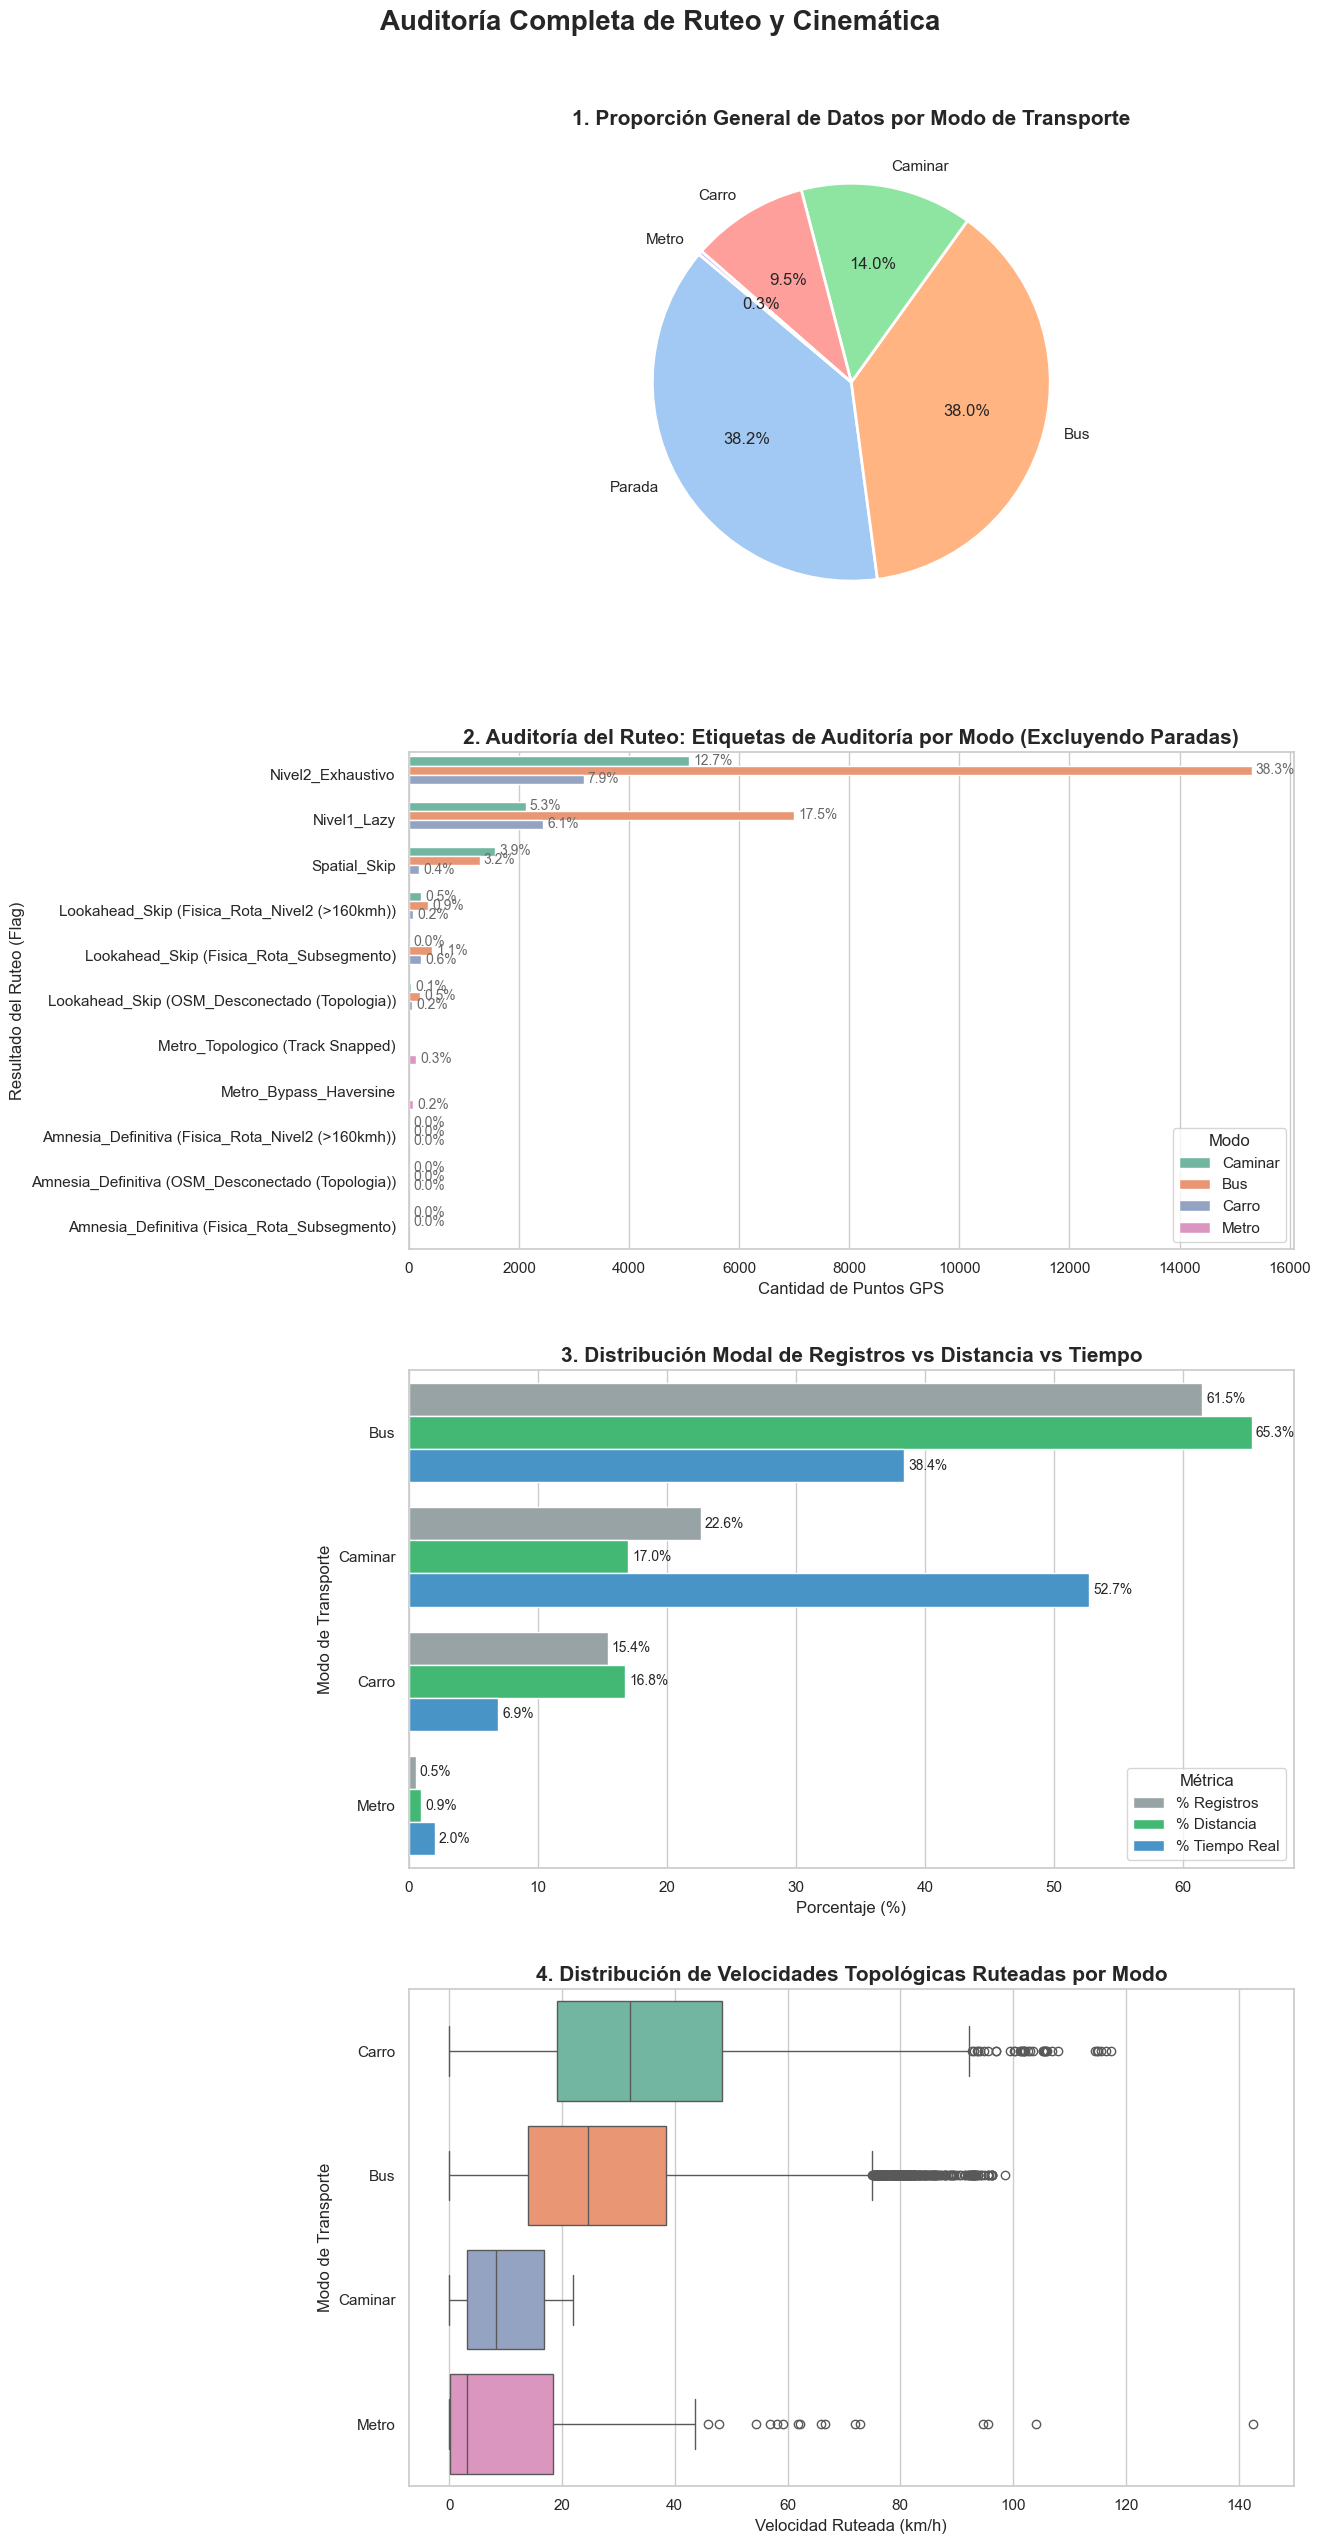

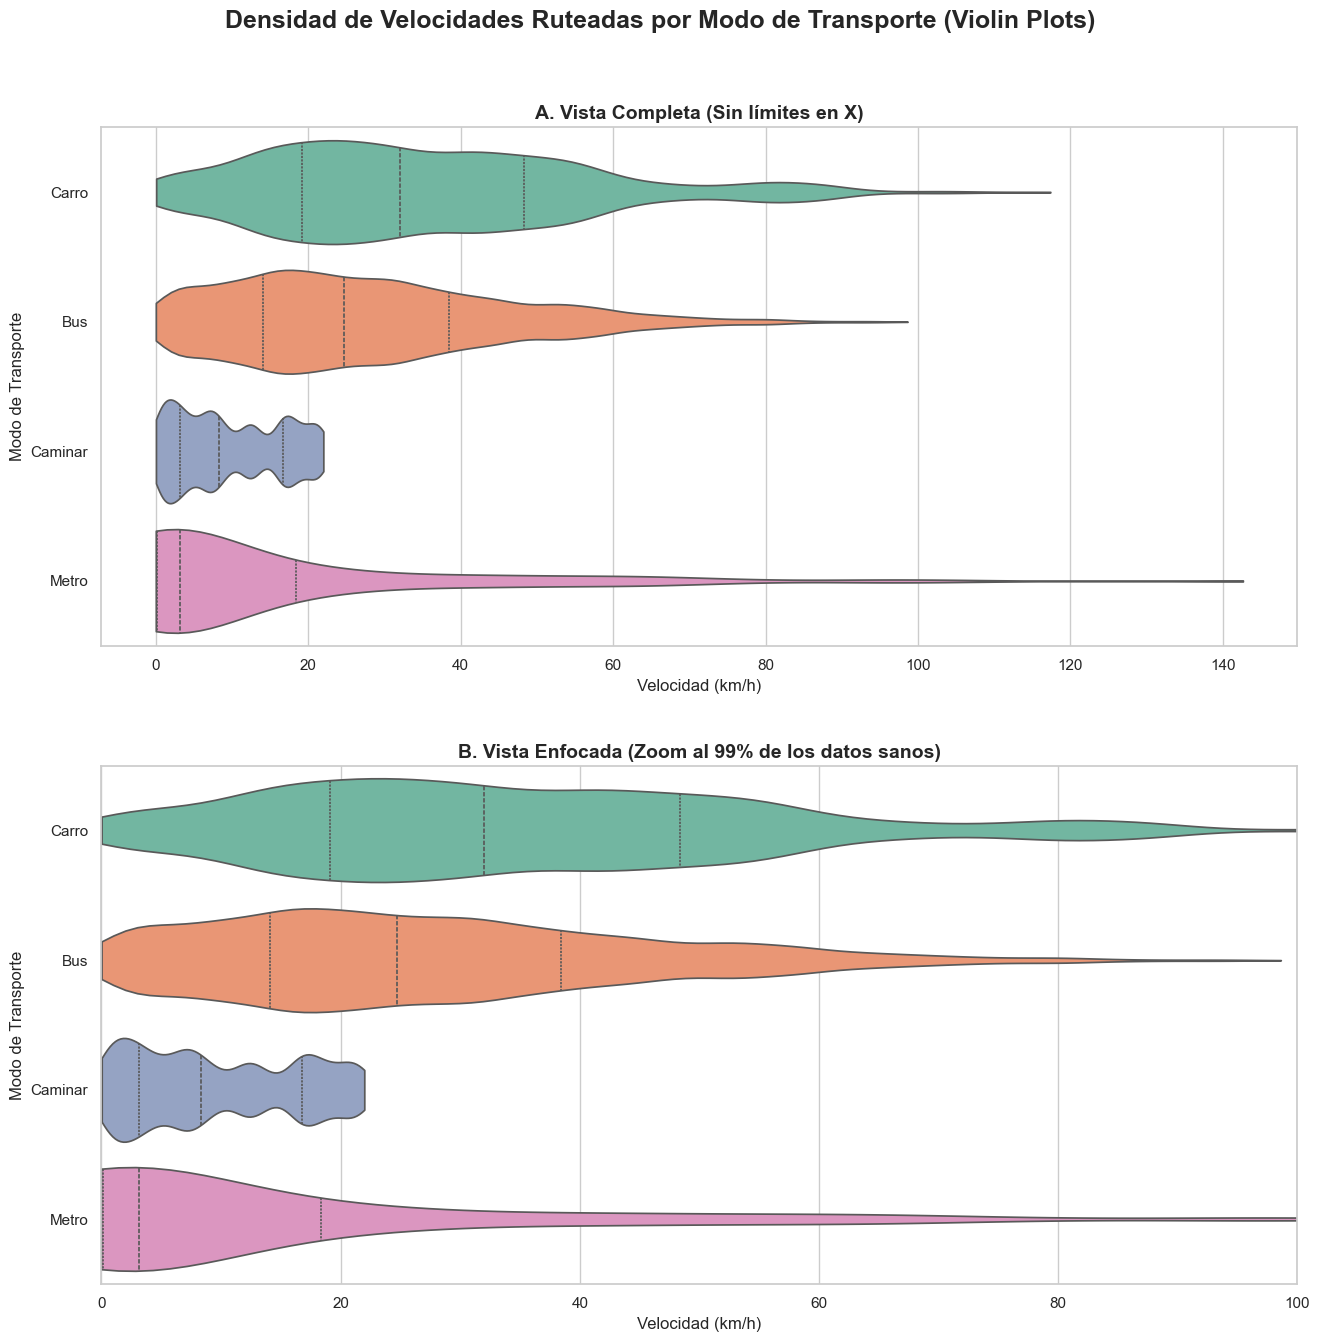

In [15]:
# ==============================================================================
# AUDITORÍA MAESTRA: DIAGNÓSTICO FÍSICO, TOPOLÓGICO Y VISUAL
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configuración de estilo visual
sns.set_theme(style="whitegrid")

print("="*70)
print("REPORTE DE DIAGNÓSTICO: RUTAS, MODOS Y FÍSICA")
print("="*70)

if df_completed_routes.empty:
    print("El DataFrame está vacío.")
else:
    # ---------------------------------------------------------
    # 1. MÉTRICAS GENERALES Y DISTRIBUCIÓN
    # ---------------------------------------------------------
    total_registros = len(df_completed_routes)
    
    # Asegurarnos de que el timestamp sea datetime y esté ordenado
    df_completed_routes['local_timestamp'] = pd.to_datetime(df_completed_routes['local_timestamp'])
    df_completed_routes = df_completed_routes.sort_values(['caid', 'trip', 'local_timestamp'])
    
    # El tiempo que toma cruzar la calle ACTUAL es la diferencia con el inicio de la SIGUIENTE calle.
    siguiente_tiempo = df_completed_routes.groupby(['caid', 'trip'])['local_timestamp'].shift(-1)
    df_completed_routes['time_delta_s'] = (siguiente_tiempo - df_completed_routes['local_timestamp']).dt.total_seconds().fillna(0)
    
    df_viajes = df_completed_routes[df_completed_routes['trip'] > 0].copy()
    total_viajes_puntos = len(df_viajes)
    
    print(f"▶ Total de puntos procesados: {total_registros:,}")
    print(f"▶ Puntos en movimiento (Viajes): {total_viajes_puntos:,}")
    
    print("\n▶ 1. Distribución Modal (Por Distancia Viajada):")
    distancia_por_modo = df_completed_routes.groupby('modo_transporte')['distance_m'].sum() / 1000 # a km
    distancia_pct = (distancia_por_modo / distancia_por_modo.sum()) * 100
    for modo, pct in distancia_pct.sort_values(ascending=False).items():
        if pct > 0:
            print(f"   - {modo}: {pct:.2f}% ({distancia_por_modo[modo]:,.2f} km)")

    # ---------------------------------------------------------
    # 2. SALUD DEL RUTEO (LOS DOS ESCUDOS)
    # ---------------------------------------------------------
    print("\n▶ 2. Salud Topológica y Filtros de Ruteo (flag_auditoria):")
    if 'flag_auditoria' in df_completed_routes.columns:
        flags_counts = df_completed_routes['flag_auditoria'].value_counts()
        flags_pct = df_completed_routes['flag_auditoria'].value_counts(normalize=True) * 100
        
        for flag, count in flags_counts.items():
            pct = flags_pct[flag]
            print(f"   - {flag}: {count:,} puntos ({pct:.2f}%)")
    else:
        print("Columna 'flag_auditoria' no encontrada.")

    print("="*70)
    print("GENERANDO GRÁFICOS DE AUDITORÍA AVANZADA...")
    print("="*70)

    # Crear figura con subgráficos (4 filas, 1 columna)
    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 26))
    fig.suptitle('Auditoría Completa de Ruteo y Cinemática', fontsize=20, fontweight='bold', y=0.99)

    # =========================================================
    # GRÁFICO 1: PROPORCIÓN GLOBAL DE MODOS
    # =========================================================
    modo_counts = df_completed_routes['modo_transporte'].value_counts()
    axes[0].pie(
        modo_counts.values, labels=modo_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'),
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    axes[0].set_title('1. Proporción General de Datos por Modo de Transporte', fontweight='bold', fontsize=15)

    # =========================================================
    # GRÁFICO 2: DESGLOSE DE BANDERAS POR MODO
    # =========================================================
    order_flags_viajes = df_viajes['flag_auditoria'].value_counts().index
    sns.countplot(
        data=df_viajes, y='flag_auditoria', hue='modo_transporte', 
        ax=axes[1], palette='Set2', order=order_flags_viajes
    )
    axes[1].set_title('2. Auditoría del Ruteo: Etiquetas de Auditoría por Modo (Excluyendo Paradas)', fontweight='bold', fontsize=15)
    axes[1].set_xlabel('Cantidad de Puntos GPS', fontsize=12)
    axes[1].set_ylabel('Resultado del Ruteo (Flag)', fontsize=12)
    axes[1].legend(title='Modo', loc='lower right')
    
    total_movimiento = len(df_viajes) 
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt=lambda x: f'{(x/total_movimiento)*100:.1f}%' if x > 0 else '', padding=3, fontsize=10, color='dimgray')
        
    # =========================================================
    # GRÁFICO 3: DISTRIBUCIÓN MODAL
    # =========================================================
    pct_regs = df_viajes['modo_transporte'].value_counts(normalize=True) * 100
    distancia_por_modo_viajes = df_viajes.groupby('modo_transporte')['distance_m'].sum()
    pct_dist = (distancia_por_modo_viajes / distancia_por_modo_viajes.sum()) * 100
    tiempo_por_modo = df_viajes.groupby('modo_transporte')['time_delta_s'].sum()
    pct_tiempo = (tiempo_por_modo / tiempo_por_modo.sum()) * 100

    df_modal = pd.DataFrame({
        '% Registros': pct_regs, '% Distancia': pct_dist, '% Tiempo Real': pct_tiempo
    }).fillna(0).reset_index()
    
    df_modal_melted = df_modal.melt(id_vars='modo_transporte', var_name='Métrica', value_name='Porcentaje')
    order_modos = df_modal.sort_values('% Distancia', ascending=False)['modo_transporte']

    sns.barplot(
        data=df_modal_melted, y='modo_transporte', x='Porcentaje', hue='Métrica', 
        ax=axes[2], palette=['#95a5a6', '#2ecc71', '#3498db'], order=order_modos
    )
    axes[2].set_title('3. Distribución Modal de Registros vs Distancia vs Tiempo', fontweight='bold', fontsize=15)
    axes[2].set_xlabel('Porcentaje (%)', fontsize=12)
    axes[2].set_ylabel('Modo de Transporte', fontsize=12)
    for container in axes[2].containers:
        axes[2].bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

    # =========================================================
    # GRÁFICO 4: VELOCIDADES POR MODO (LA VELOCIDAD PURA)
    # =========================================================
    df_plot_speed = df_viajes[(df_viajes['Speed [km/h]'] > 0) & (df_viajes['Speed [km/h]'] <= 150)]
    order_speed = df_plot_speed.groupby('modo_transporte')['Speed [km/h]'].median().sort_values(ascending=False).index

    sns.boxplot(
        data=df_plot_speed, y='modo_transporte', x='Speed [km/h]', 
        ax=axes[3], palette='Set2', order=order_speed
    )
    axes[3].set_title('4. Distribución de Velocidades Topológicas Ruteadas por Modo', fontweight='bold', fontsize=15)
    axes[3].set_xlabel('Velocidad Ruteada (km/h)', fontsize=12)
    axes[3].set_ylabel('Modo de Transporte', fontsize=12)

    plt.tight_layout(pad=3.0)
    plt.show()
    
    # =========================================================
    # GRÁFICOS EXTRAS: VIOLINES DE VELOCIDADES (COMPARATIVA)
    # =========================================================
    fig_v, axes_v = plt.subplots(nrows=2, ncols=1, figsize=(14, 14))
    fig_v.suptitle('Densidad de Velocidades Ruteadas por Modo de Transporte (Violin Plots)', fontsize=18, fontweight='bold', y=0.98)

    columna_velocidad = 'Speed [km/h]'

    sns.violinplot(
        data=df_plot_speed, y='modo_transporte', x=columna_velocidad, 
        ax=axes_v[0], palette='Set2', order=order_speed,
        inner='quartile', cut=0, scale='width'
    )
    axes_v[0].set_title('A. Vista Completa (Sin límites en X)', fontweight='bold', fontsize=14)
    axes_v[0].set_xlabel('Velocidad (km/h)', fontsize=12)
    axes_v[0].set_ylabel('Modo de Transporte', fontsize=12)

    sns.violinplot(
        data=df_plot_speed, y='modo_transporte', x=columna_velocidad, 
        ax=axes_v[1], palette='Set2', order=order_speed,
        inner='quartile', cut=0, scale='width'
    )
    axes_v[1].set_title('B. Vista Enfocada (Zoom al 99% de los datos sanos)', fontweight='bold', fontsize=14)
    axes_v[1].set_xlabel('Velocidad (km/h)', fontsize=12)
    axes_v[1].set_ylabel('Modo de Transporte', fontsize=12)
    
    limite_visual_violin = df_plot_speed[columna_velocidad].quantile(0.99)
    if pd.isna(limite_visual_violin) or limite_visual_violin == 0:
        limite_visual_violin = 100
    axes_v[1].set_xlim(0, max(100, limite_visual_violin))

    plt.tight_layout(pad=3.0)
    plt.show()

##### Diagnóstico a Nivel de Viaje

INICIANDO AGRUPACIÓN A NIVEL DE VIAJE...
Se consolidaron 170 viajes únicos para el análisis macro.


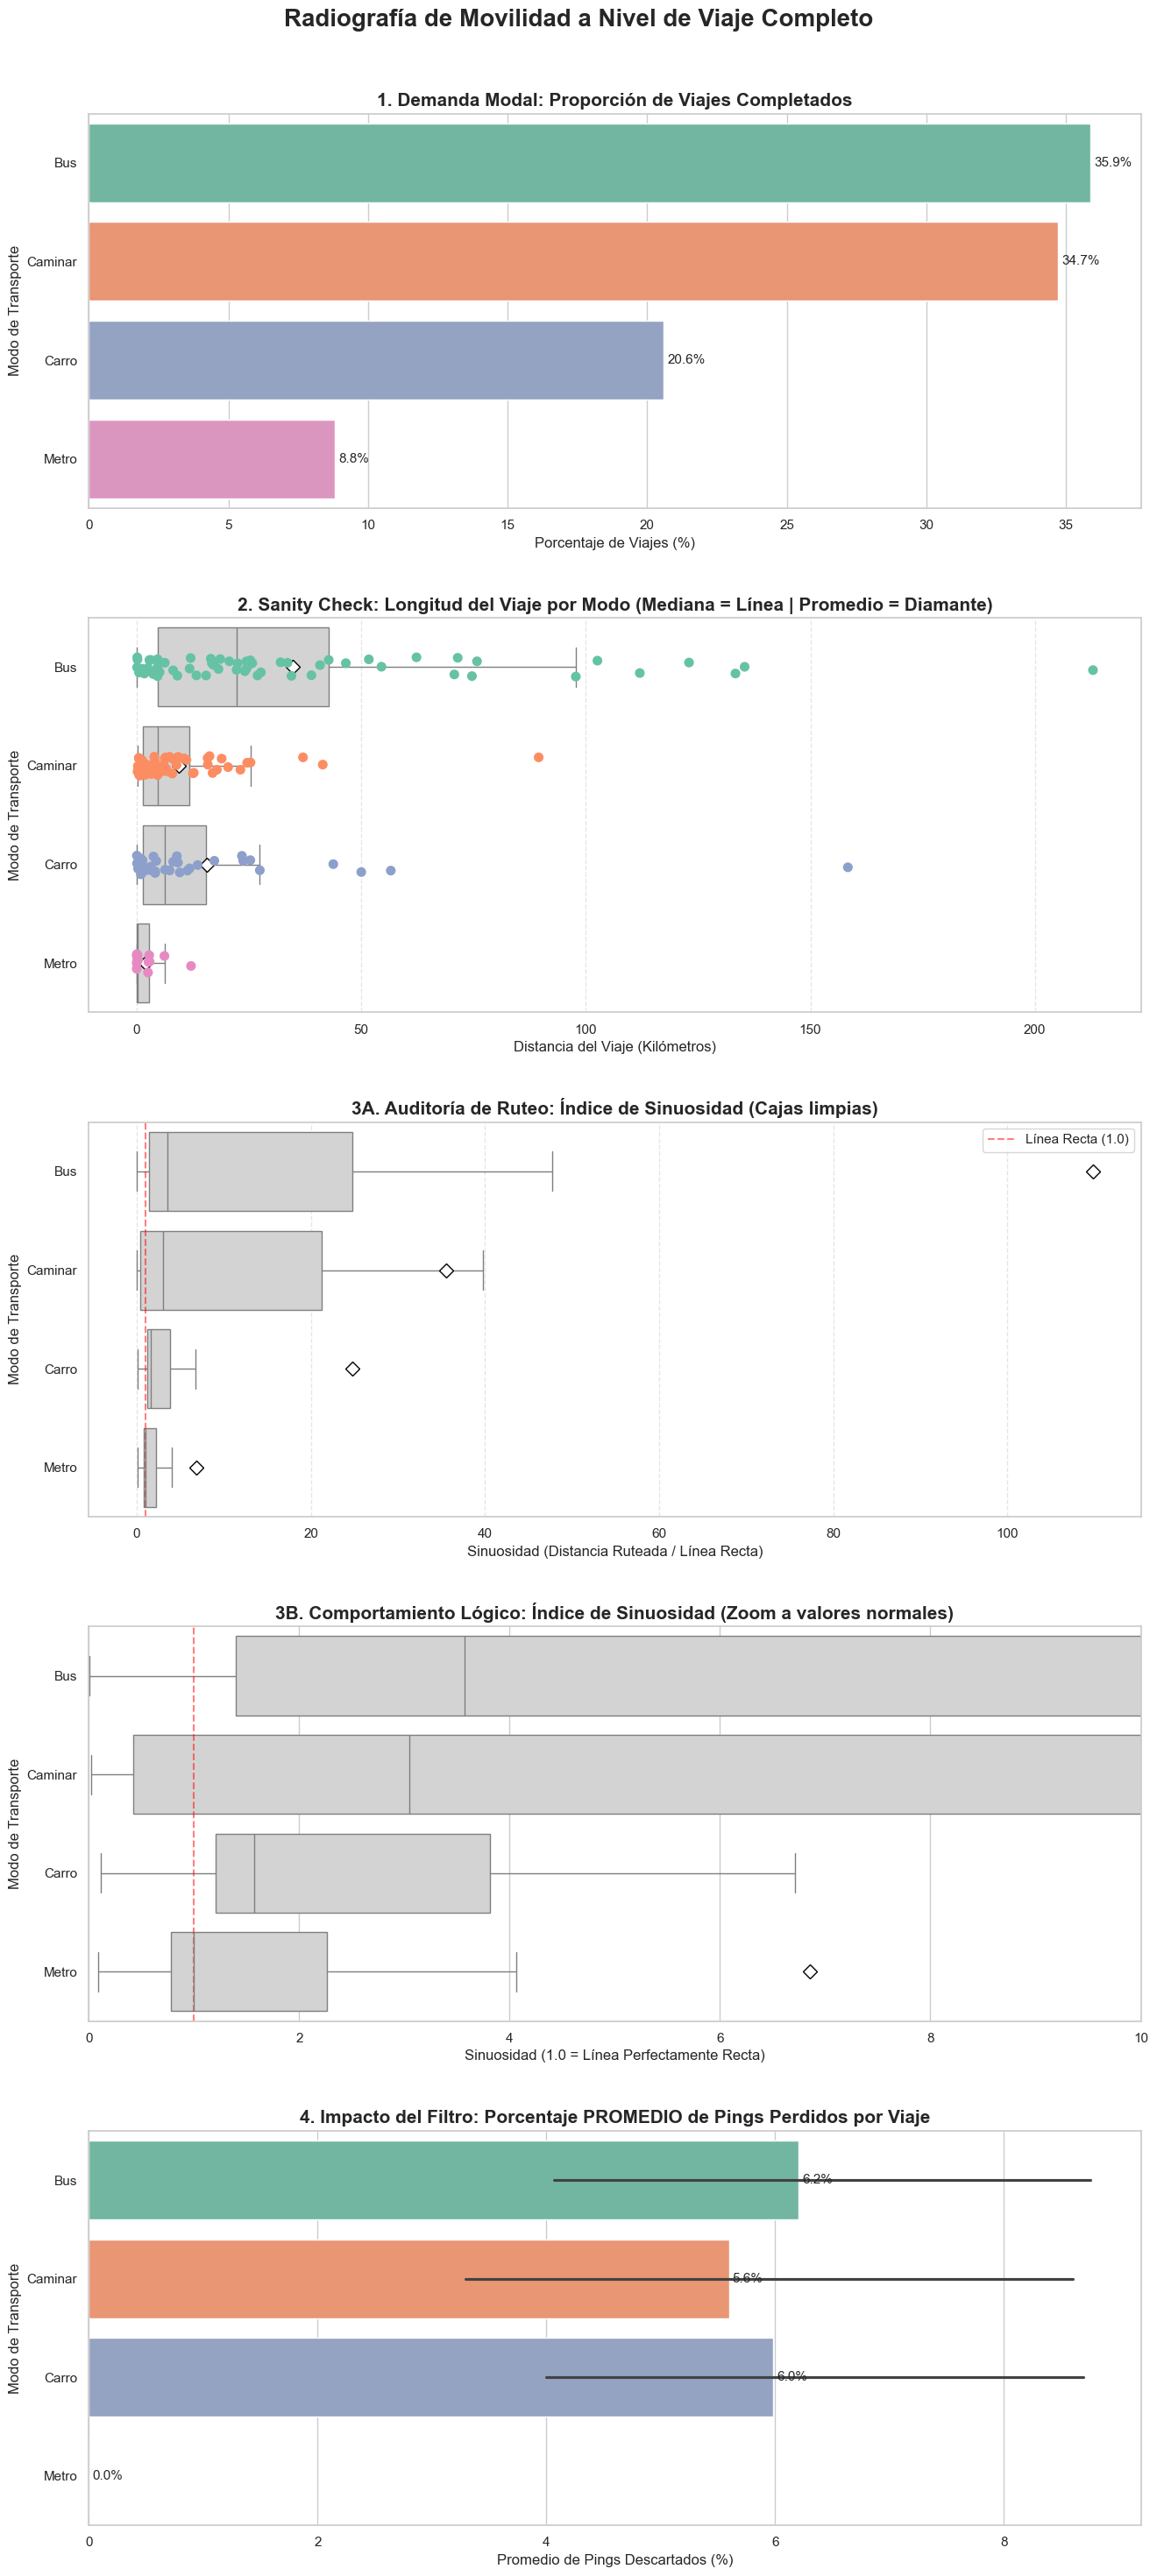

In [16]:
# ==============================================================================
# AUDITORÍA FASE 2: ANÁLISIS MACRO A NIVEL DE VIAJE (TRIP-LEVEL)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

print("="*70)
print("INICIANDO AGRUPACIÓN A NIVEL DE VIAJE...")
print("="*70)

# 1. Fórmula Haversine Vectorizada
def calc_haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371000.0  # Radio de la Tierra en metros
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2.0)**2
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))

# 2. Filtrar solo los datos en movimiento (excluir paradas)
df_viajes_pings = df_completed_routes[df_completed_routes['trip'] > 0].copy()

if df_viajes_pings.empty:
    print("No hay viajes en movimiento para analizar.")
else:
    # Asegurar el cálculo del tiempo con shift(-1)
    df_viajes_pings['local_timestamp'] = pd.to_datetime(df_viajes_pings['local_timestamp'])
    df_viajes_pings = df_viajes_pings.sort_values(['caid', 'trip', 'local_timestamp'])
    siguiente_tiempo = df_viajes_pings.groupby(['caid', 'trip'])['local_timestamp'].shift(-1)
    df_viajes_pings['time_delta_s_real'] = (siguiente_tiempo - df_viajes_pings['local_timestamp']).dt.total_seconds().fillna(0)

# 3. Agrupación (Separamos por Usuario, Viaje Y MODO DE TRANSPORTE)
    trip_stats = df_viajes_pings.groupby(['caid', 'trip', 'modo_transporte']).agg(
        distancia_total_m=('distance_m', 'sum'),
        tiempo_total_s=('time_delta_s_real', 'sum'), 
        total_pings=('caid', 'count'),
        pings_amnesia=('flag_auditoria', lambda x: x.str.contains('Amnesia|Lookahead', na=False).sum()), 
        lat_start=('latitude', 'first'),
        lon_start=('longitude', 'first'),
        lat_end=('latitude', 'last'),
        lon_end=('longitude', 'last')
    ).reset_index()

    # 4. Cálculo de Métricas Macro
    trip_stats['distancia_haversine_m'] = calc_haversine_vectorized(
        trip_stats['lat_start'], trip_stats['lon_start'], 
        trip_stats['lat_end'], trip_stats['lon_end']
    )

    # Cambio a Kilómetros
    trip_stats['distancia_total_km'] = trip_stats['distancia_total_m'] / 1000.0

    # Índice de Sinuosidad (Protegido contra NaN si la distancia haversine es 0 por ser viaje redondo)
    trip_stats['sinuosidad'] = np.where(
        trip_stats['distancia_haversine_m'] > 0,
        trip_stats['distancia_total_m'] / trip_stats['distancia_haversine_m'],
        1.0
    )

    # Tasa de daño por pérdida de ruteo
    trip_stats['tasa_amnesia_pct'] = (trip_stats['pings_amnesia'] / trip_stats['total_pings']) * 100

    # Limpiamos viajes nulos para graficar
    trip_stats_clean = trip_stats[(trip_stats['distancia_total_m'] > 0) & (trip_stats['tiempo_total_s'] > 0)].copy()

    print(f"Se consolidaron {len(trip_stats_clean):,} viajes únicos para el análisis macro.")
    print("="*70)

    if len(trip_stats_clean) == 0:
        print("No hay suficientes datos limpios para generar gráficos a nivel de viaje.")
    else:
        # ==============================================================================
        # GENERACIÓN DE GRÁFICOS (5 FILAS)
        # ==============================================================================
        fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 30))
        fig.suptitle('Radiografía de Movilidad a Nivel de Viaje Completo', fontsize=20, fontweight='bold', y=0.99)

        order_modos = trip_stats_clean['modo_transporte'].value_counts().index

        # --- Gráfico 1: Proporción de Viajes (PORCENTAJES) ---
        trip_counts_pct = trip_stats_clean['modo_transporte'].value_counts(normalize=True) * 100
        sns.barplot(
            x=trip_counts_pct.values, 
            y=trip_counts_pct.index, 
            ax=axes[0],
            palette='Set2',
            order=order_modos
        )
        axes[0].set_title('1. Demanda Modal: Proporción de Viajes Completados', fontweight='bold', fontsize=15)
        axes[0].set_xlabel('Porcentaje de Viajes (%)', fontsize=12)
        axes[0].set_ylabel('Modo de Transporte', fontsize=12)
        for container in axes[0].containers:
            axes[0].bar_label(container, fmt='%.1f%%', padding=3, fontsize=11)

    # Configuración visual para el marcador del promedio (Diamante blanco)
        mean_marker_props = {
            "marker": "D", 
            "markerfacecolor": "white", 
            "markeredgecolor": "black", 
            "markersize": "8"
        }

        # --- Gráfico 2: Distancia Promedio del Viaje ---
        sns.boxplot(
            data=trip_stats_clean, y='modo_transporte', x='distancia_total_km', 
            ax=axes[1], color='lightgray', showfliers=False, order=order_modos,
            showmeans=True, meanprops=mean_marker_props  # <--- MAGIA AQUÍ
        )
        sns.stripplot(data=trip_stats_clean, y='modo_transporte', x='distancia_total_km', ax=axes[1], palette='Set2', size=8, jitter=True, order=order_modos)
        axes[1].set_title('2. Sanity Check: Longitud del Viaje por Modo (Mediana = Línea | Promedio = Diamante)', fontweight='bold', fontsize=15)
        axes[1].set_xlabel('Distancia del Viaje (Kilómetros)', fontsize=12)
        axes[1].set_ylabel('Modo de Transporte', fontsize=12)
        axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

        # # --- Gráfico 3A: Sinuosidad (VISTA CRUDA CON OUTLIERS) ---
        # sns.boxplot(
        #     data=trip_stats_clean, y='modo_transporte', x='sinuosidad', 
        #     ax=axes[2], color='lightgray', showfliers=False, order=order_modos,
        #     showmeans=True, meanprops=mean_marker_props  # <--- MAGIA AQUÍ
        # )
        # sns.stripplot(data=trip_stats_clean, y='modo_transporte', x='sinuosidad', ax=axes[2], palette='Set2', size=8, jitter=True, order=order_modos)
        # axes[2].set_title('3A. Auditoría de Ruteo: Índice de Sinuosidad (Mediana = Línea | Promedio = Diamante)', fontweight='bold', fontsize=15)
        # axes[2].set_xlabel('Sinuosidad (Distancia Ruteada / Línea Recta)', fontsize=12)
        # axes[2].set_ylabel('Modo de Transporte', fontsize=12)
        # axes[2].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Línea Recta (1.0)')
        # axes[2].legend(loc='upper right')
        # axes[2].grid(True, axis='x', linestyle='--', alpha=0.5)

        # # --- Gráfico 3B: Sinuosidad (VISTA DETALLADA / ZOOM) ---
        # sns.boxplot(
        #     data=trip_stats_clean, y='modo_transporte', x='sinuosidad', 
        #     ax=axes[3], color='lightgray', showfliers=False, order=order_modos,
        #     showmeans=True, meanprops=mean_marker_props  # <--- MAGIA AQUÍ
        # )
        # sns.stripplot(data=trip_stats_clean, y='modo_transporte', x='sinuosidad', ax=axes[3], palette='Set2', size=8, jitter=True, order=order_modos)
        # axes[3].set_title('3B. Comportamiento Lógico: Índice de Sinuosidad (Zoom sin atípicos extremos)', fontweight='bold', fontsize=15)
        # axes[3].set_xlabel('Sinuosidad (1.0 = Línea Perfectamente Recta)', fontsize=12)
        # # Esto cortará el gráfico para que solo veas las sinuosidades normales (ej. de 0 a 5)
        # axes[3].set_xlim(0, 10)
        # axes[3].set_ylabel('Modo de Transporte', fontsize=12)
        # axes[3].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Línea Recta (1.0)')
        
    # --- Gráfico 3A: Sinuosidad (VISTA LIMPIA SIN PUNTOS) ---
        sns.boxplot(
            data=trip_stats_clean, y='modo_transporte', x='sinuosidad', 
            ax=axes[2], color='lightgray', showfliers=False, order=order_modos,
            showmeans=True, meanprops=mean_marker_props  
        )
        # ELIMINADO: La línea de sns.stripplot que agregaba los puntos de colores
        
        axes[2].set_title('3A. Auditoría de Ruteo: Índice de Sinuosidad (Cajas limpias)', fontweight='bold', fontsize=15)
        axes[2].set_xlabel('Sinuosidad (Distancia Ruteada / Línea Recta)', fontsize=12)
        axes[2].set_ylabel('Modo de Transporte', fontsize=12)
        axes[2].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Línea Recta (1.0)')
        axes[2].legend(loc='upper right')
        axes[2].grid(True, axis='x', linestyle='--', alpha=0.5)

        # --- Gráfico 3B: Sinuosidad (ZOOM PARA VER COMPORTAMIENTO LÓGICO) ---
        sns.boxplot(
            data=trip_stats_clean, y='modo_transporte', x='sinuosidad', 
            ax=axes[3], color='lightgray', showfliers=False, order=order_modos,
            showmeans=True, meanprops=mean_marker_props 
        )
        # ELIMINADO: La línea de sns.stripplot
        
        axes[3].set_title('3B. Comportamiento Lógico: Índice de Sinuosidad (Zoom a valores normales)', fontweight='bold', fontsize=15)
        axes[3].set_xlabel('Sinuosidad (1.0 = Línea Perfectamente Recta)', fontsize=12)
        axes[3].set_ylabel('Modo de Transporte', fontsize=12)
        axes[3].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Línea Recta (1.0)')
        
        # MAGIA AQUÍ: Forzamos el eje X para ignorar los valores absurdos (e.g. 400, 600)
        # y ver solo donde se concentra la masa de datos reales (ej. de 0 a 5 o 10)
        axes[3].set_xlim(0, 10)
    
        # --- Gráfico 4: Tasa de Amnesia por Viaje (GRÁFICO DE BARRAS PROMEDIO) ---
        sns.barplot(
            data=trip_stats_clean,
            y='modo_transporte',
            x='tasa_amnesia_pct',
            estimator="mean", 
            ax=axes[4],
            palette='Set2',
            order=order_modos
        )
        axes[4].set_title('4. Impacto del Filtro: Porcentaje PROMEDIO de Pings Perdidos por Viaje', fontweight='bold', fontsize=15)
        axes[4].set_xlabel('Promedio de Pings Descartados (%)', fontsize=12)
        axes[4].set_ylabel('Modo de Transporte', fontsize=12)
        for container in axes[4].containers:
            axes[4].bar_label(container, fmt='%.1f%%', padding=3, fontsize=11)

        plt.tight_layout(pad=3.0)
        plt.show()

In [17]:
# print("="*70)
# print("DIAGNÓSTICO PROFUNDO DE OUTLIERS DE SINUOSIDAD")
# print("="*70)

# total_viajes = len(trip_stats_clean)

# # 1. Viajes Imposibles
# imposibles = trip_stats_clean[trip_stats_clean['sinuosidad'] < 1.0]

# # 2. Viajes Redondos (Mucha ruta, pero inicio y fin a menos de 200m de distancia)
# redondos = trip_stats_clean[(trip_stats_clean['sinuosidad'] > 5.0) & (trip_stats_clean['distancia_haversine_m'] <= 200)]

# # 3. Telarañas de Ruteo (Mucha ruta, inicio y fin separados, pero el algoritmo dio demasiadas vueltas)
# telaranas = trip_stats_clean[(trip_stats_clean['sinuosidad'] > 5.0) & (trip_stats_clean['distancia_haversine_m'] > 200)]

# # 4. Viajes Sanos
# sanos = trip_stats_clean[(trip_stats_clean['sinuosidad'] >= 1.0) & (trip_stats_clean['sinuosidad'] <= 5.0)]

# print(f"Total de viajes analizados: {total_viajes:,}")
# print("-" * 50)
# print(f" Viajes Lógicos (Sinuosidad 1.0 - 5.0): {len(sanos)} ({(len(sanos)/total_viajes)*100:.1f}%)")
# print(f" Imposibles (Sinuosidad < 1.0): {len(imposibles)} ({(len(imposibles)/total_viajes)*100:.1f}%) -> Revisar Map-Matching / Pings estáticos")
# print(f" Redondos (Inicio/Fin muy cerca): {len(redondos)} ({(len(redondos)/total_viajes)*100:.1f}%) -> Normal en la vida real, pero rompe la métrica")
# print(f"🕸️ Telarañas (Sinuosidad excesiva): {len(telaranas)} ({(len(telaranas)/total_viajes)*100:.1f}%) -> Revisar rebotes de GPS en el ruteo")
# print("="*70)

# # Ver ejemplos crudos de los peores ofensores para inspección manual
# print("\nTop 3 peores 'Telarañas' (Revisa estos CAID/Trip manualmente):")
# print(telaranas[['caid', 'trip', 'modo_transporte', 'distancia_total_km', 'distancia_haversine_m', 'sinuosidad']].sort_values('sinuosidad', ascending=False).head(3))

In [18]:
# print("="*70)
# print("DIAGNÓSTICO MICRO: ANATOMÍA DEL ERROR")
# print("="*70)

# # --- 1. Radiografía de los "Imposibles" ---
# print("1. PERFIL DE LOS VIAJES IMPOSIBLES (< 1.0 Sinuosidad):")
# cero_km = imposibles[imposibles['distancia_total_km'] < 0.05] # Menos de 50 metros ruteados
# print(f"Total de viajes imposibles: {len(imposibles)}")
# print(f"Viajes que en realidad no se movieron (< 50m ruteados): {len(cero_km)} ({(len(cero_km)/len(imposibles))*100:.1f}%)")
# print("Conclusión: Si el % es alto, tu algoritmo hizo bien en no rutearlos, pero debes filtrarlos del análisis de viajes.\n")

# # --- 2. Autopsia del "Autobús Circular" ---
# # Tomamos el CAID problemático del Top 1
# caid_bus = telaranas.iloc[0]['caid']
# trip_bus = telaranas.iloc[0]['trip']

# # Filtramos los pings de ese viaje específico usando tu DataFrame  original de pings
# pings_bus = df_viajes_pings[(df_viajes_pings['caid'] == caid_bus) & (df_viajes_pings['trip'] == trip_bus)].copy()

# if not pings_bus.empty:
#     tiempo_inicio = pings_bus['local_timestamp'].min()
#     tiempo_fin = pings_bus['local_timestamp'].max()
#     duracion_horas = (tiempo_fin - tiempo_inicio).total_seconds() / 3600
    
#     print("2. AUTOPSIA DEL PEOR OFENSOR (El Autobús Circular):")
#     print(f"Modo: {telaranas.iloc[0]['modo_transporte']}")
#     print(f"Distancia Total Ruteada: {telaranas.iloc[0]['distancia_total_km']:.2f} km")
#     print(f"Hora de Inicio: {tiempo_inicio}")
#     print(f"Hora de Fin: {tiempo_fin}")
#     print(f"Duración Total del Viaje: {duracion_horas:.2f} horas")
#     print(f"Cantidad de Pings registrados: {len(pings_bus)}")
    
#     if duracion_horas > 1:
#         print("Conclusión: ¡Es un viaje real y válido! Fue un circuito largo. La métrica de sinuosidad no sirve para este viaje.")
#     else:
#         print("Conclusión: Ruteó demasiados km en muy poco tiempo. Hay un error grave de rebote de GPS.")
# else:
#     print("No se encontraron los pings de este viaje para la autopsia.")
# print("="*70)

Calculando Sinuosidad a nivel de segmento (ping a ping)...
Se evaluaron 33,079 micro-segmentos de ruteo.


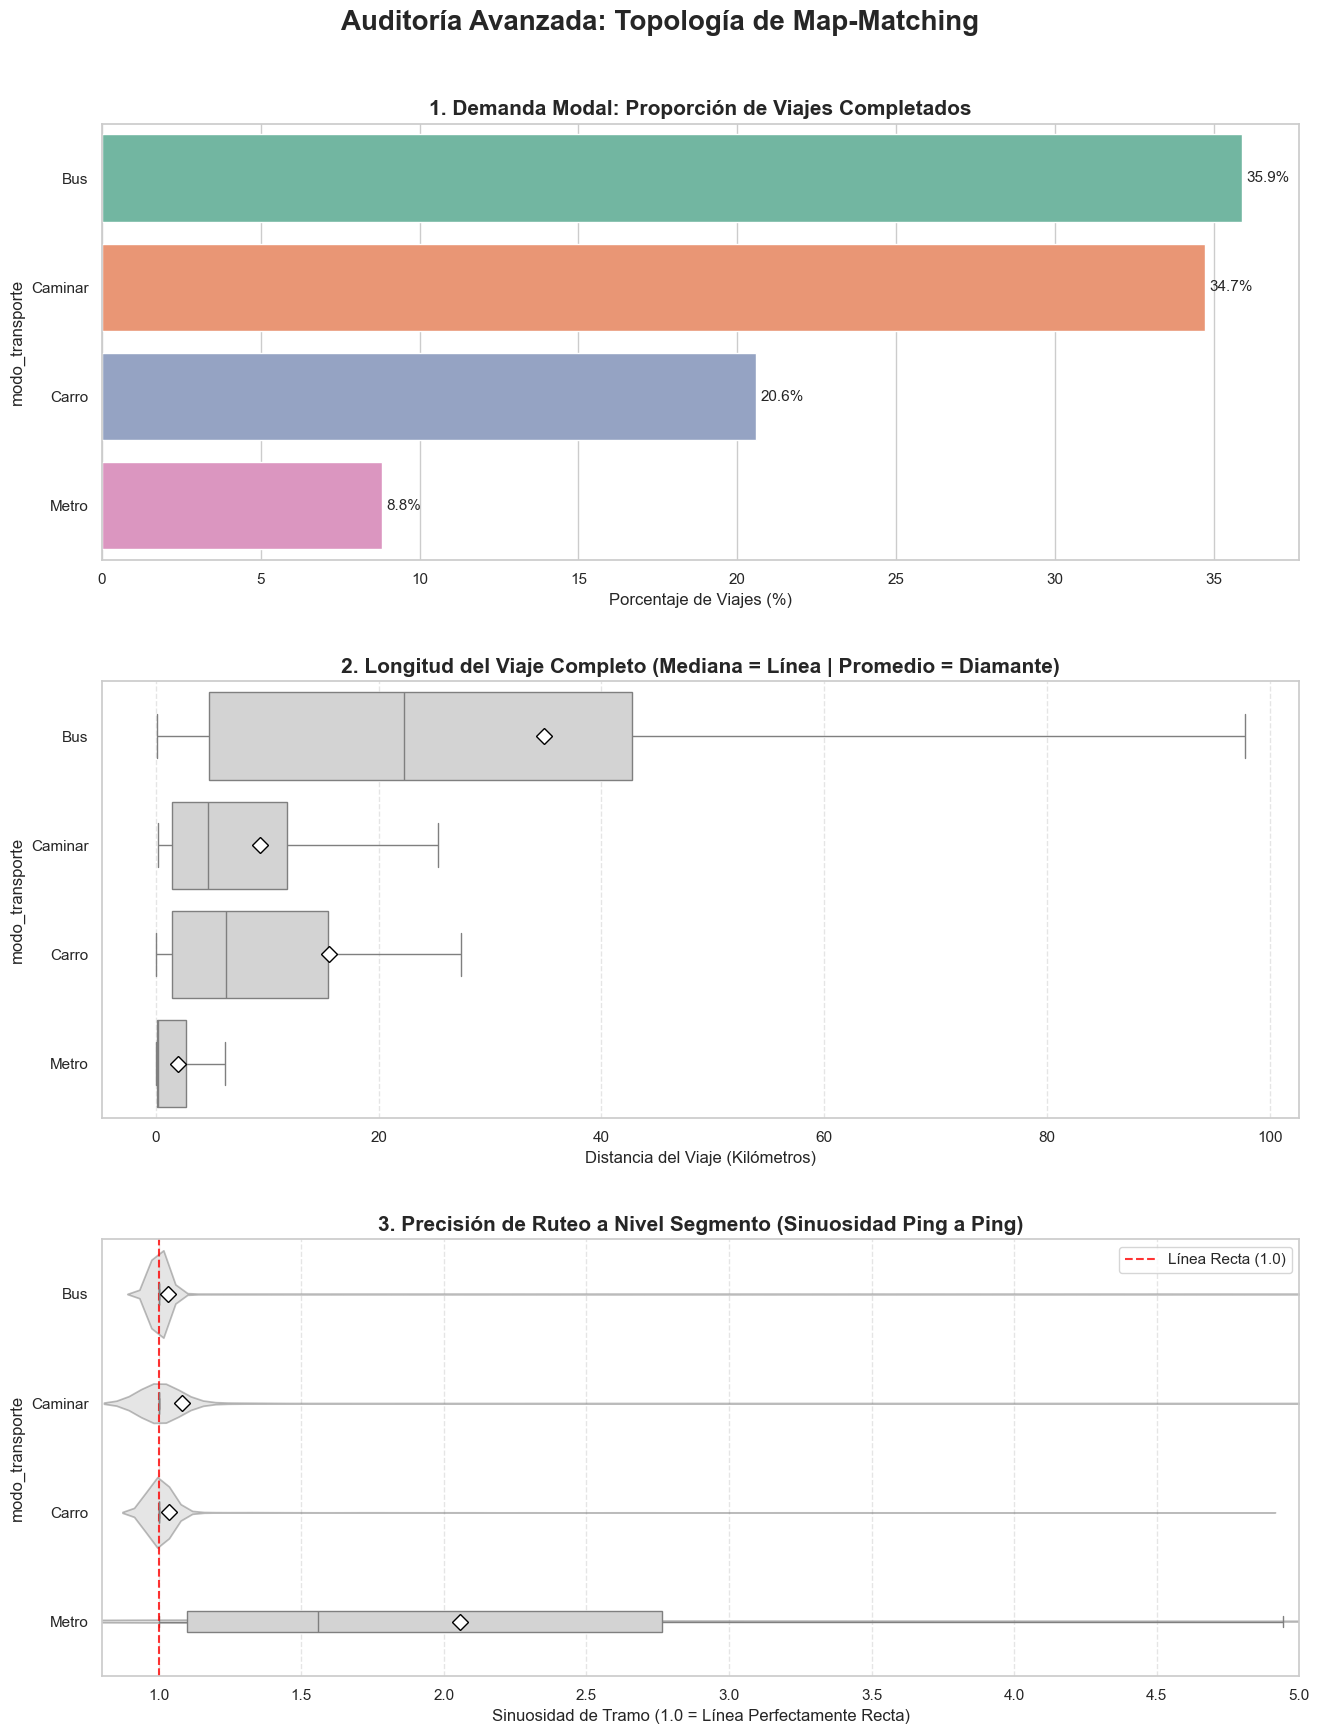

In [19]:
# ==============================================================================
# AUDITORÍA MICRO: ÍNDICE DE SINUOSIDAD POR SEGMENTO (PING-A-PING)
# ==============================================================================
print("Calculando Sinuosidad a nivel de segmento (ping a ping)...")

# 1. Calculamos las coordenadas del "Siguiente Ping" dentro del mismo viaje
df_viajes_pings['lat_next'] = df_viajes_pings.groupby(['caid', 'trip'])['latitude'].shift(-1)
df_viajes_pings['lon_next'] = df_viajes_pings.groupby(['caid', 'trip'])['longitude'].shift(-1)

# Nos deshacemos del último punto de cada viaje (no tiene un "siguiente")
df_segmentos = df_viajes_pings.dropna(subset=['lat_next', 'lon_next']).copy()

# 2. Calculamos la línea recta exacta de ese micro-segmento
df_segmentos['segment_haversine_m'] = calc_haversine_vectorized(
    df_segmentos['latitude'], df_segmentos['longitude'], 
    df_segmentos['lat_next'], df_segmentos['lon_next']
)

# 3. Calculamos la sinuosidad micro (Distancia ruteada / Distancia línea recta)
# Evitamos divisiones por cero filtrando haversines nulos o de menos de 5 metros (ruido puro)
df_segmentos = df_segmentos[df_segmentos['segment_haversine_m'] >= 5.0].copy()
df_segmentos['segment_sinuosity'] = df_segmentos['distance_m'] / df_segmentos['segment_haversine_m']

# 4. Limpieza matemática para el plot
# Aceptamos un 0.95 por redondeos geográficos, y topamos en 5.0 (límite lógico de la red)
df_segmentos_clean = df_segmentos[
    (df_segmentos['segment_sinuosity'] >= 0.95) & 
    (df_segmentos['segment_sinuosity'] <= 5.0)
].copy()

print(f"Se evaluaron {len(df_segmentos_clean):,} micro-segmentos de ruteo.")

# ==============================================================================
# GENERACIÓN DE GRÁFICOS (Reducimos a 3 paneles súper efectivos)
# ==============================================================================
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 18))
fig.suptitle('Auditoría Avanzada: Topología de Map-Matching', fontsize=20, fontweight='bold', y=0.98)

order_modos = trip_stats_clean['modo_transporte'].value_counts().index

mean_marker_props = {
    "marker": "D", 
    "markerfacecolor": "white", 
    "markeredgecolor": "black", 
    "markersize": "8"
}

# --- Gráfico 1: Demanda Modal ---
trip_counts_pct = trip_stats_clean['modo_transporte'].value_counts(normalize=True) * 100
sns.barplot(x=trip_counts_pct.values, y=trip_counts_pct.index, ax=axes[0], palette='Set2', order=order_modos)
axes[0].set_title('1. Demanda Modal: Proporción de Viajes Completados', fontweight='bold', fontsize=15)
axes[0].set_xlabel('Porcentaje de Viajes (%)', fontsize=12)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3, fontsize=11)

# --- Gráfico 2: Sanity Check (Longitud de Viaje) ---
sns.boxplot(
    data=trip_stats_clean, y='modo_transporte', x='distancia_total_km', 
    ax=axes[1], color='lightgray', showfliers=False, order=order_modos,
    showmeans=True, meanprops=mean_marker_props 
)
axes[1].set_title('2. Longitud del Viaje Completo (Mediana = Línea | Promedio = Diamante)', fontweight='bold', fontsize=15)
axes[1].set_xlabel('Distancia del Viaje (Kilómetros)', fontsize=12)
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

# --- Gráfico 3: LA NUEVA JOYA (Sinuosidad Ping-a-Ping) ---
# Usamos un ViolinPlot mezclado con un Boxplot para ver dónde se concentra la masa de datos
sns.violinplot(
    data=df_segmentos_clean, y='modo_transporte', x='segment_sinuosity', 
    ax=axes[2], inner=None, color=".8", order=order_modos, alpha=0.5
)
sns.boxplot(
    data=df_segmentos_clean, y='modo_transporte', x='segment_sinuosity', 
    ax=axes[2], color='lightgray', width=0.2, showfliers=False, order=order_modos,
    showmeans=True, meanprops=mean_marker_props 
)
axes[2].set_title('3. Precisión de Ruteo a Nivel Segmento (Sinuosidad Ping a Ping)', fontweight='bold', fontsize=15)
axes[2].set_xlabel('Sinuosidad de Tramo (1.0 = Línea Perfectamente Recta)', fontsize=12)
axes[2].axvline(1.0, color='red', linestyle='--', alpha=0.8, label='Línea Recta (1.0)')
axes[2].set_xlim(0.8, 5.0)
axes[2].legend(loc='upper right')
axes[2].grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout(pad=3.0)
plt.show()

### 2.4. Guardado de Completado de Rutas

In [20]:
# ==============================================================================
# 5. LIMPIEZA Y GUARDADO INTELIGENTE A PARQUET
# ==============================================================================

print("Guardando rutas completadas...")

# 1. Quitar las columnas temporales del ruteo espacial
cols_a_borrar = ["nodes_drive", "nodes_walk", "date", "drive_ids", "drive_dists", "walk_ids", "walk_dists"]
df_completed_routes = df_completed_routes.drop(columns=cols_a_borrar, errors="ignore")

# 2. LA APLANADORA DE TIPOS (Directo en memoria RAM)
print("Estandarizando tipos de datos para Apache Arrow...")

# Forzar columnas de Texto (Strings puros)
cols_texto = ['caid', 'start_node', 'end_node', 'osmid', 'highway', 'geometry', 'modo_transporte']
for col in cols_texto:
    if col in df_completed_routes.columns:
        df_completed_routes[col] = df_completed_routes[col].astype(str)

# Forzar columnas Numéricas (Enteros y Floats)
if 'trip' in df_completed_routes.columns:
    df_completed_routes['trip'] = df_completed_routes['trip'].fillna(-1).astype(int)
    
cols_float = ['latitude', 'longitude', 'Speed [km/h]', 'distance_m']
for col in cols_float:
    if col in df_completed_routes.columns:
        df_completed_routes[col] = pd.to_numeric(df_completed_routes[col], errors='coerce').astype(float)

# Forzar columna de Fecha/Hora 
if 'local_timestamp' in df_completed_routes.columns:
    df_completed_routes['local_timestamp'] = pd.to_datetime(df_completed_routes['local_timestamp'], errors='coerce')
    
# Forzar Booleanos 
if 'ruteo_fallido' in df_completed_routes.columns:
    df_completed_routes['ruteo_fallido'] = df_completed_routes['ruteo_fallido'].fillna(False).astype(bool)

if 'corregido_espacialmente' in df_completed_routes.columns:
    df_completed_routes['corregido_espacialmente'] = df_completed_routes['corregido_espacialmente'].fillna(False).astype(bool)

# 3. GUARDADO FINAL (USANDO PATHLIB)
print(f"Guardando archivo en formato Parquet en la carpeta '{INTERMEDIATE_DIR.name}'...")

# Usamos la variable inteligente de tu bloque de configuración
df_completed_routes.to_parquet(FILE_INTERMEDIO, index=False)

print("Ruteo finalizado y guardado con éxito.")

Guardando rutas completadas...
Estandarizando tipos de datos para Apache Arrow...
Guardando archivo en formato Parquet en la carpeta 'Intermediate Outputs'...
Ruteo finalizado y guardado con éxito.


# **MODULE 3: Código de Cálculo de Emisiones**

## Settings y Cálculo Dinámico 

In [21]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. CONFIGURACIÓN
# ==============================================================================
print("Iniciando Módulo 3: Cálculo de emisiones.")

COLUMNA_MODO = 'modo_transporte' 
COLUMNA_VELOCIDAD = 'Speed [km/h]'
COLUMNA_DISTANCIA = 'distance_m'

print("Cargando rutas y tasas de emisión...")

# Cargamos el archivo puente del Módulo 2
df_rutas = pd.read_parquet(FILE_INTERMEDIO)

# Cargamos la tabla de MOVES
df_emisiones_raw = pd.read_parquet(FILE_MOVES)

# INCLUSIÓN DE TODOS LOS CONTAMINANTES CRITERIO
POLLUTANTS = ['CO', 'CO2', 'CO2_Equiv', 'HC', 'NOx', 'PM10', 'PM25']

OSM_TO_MOVES_ROAD = {
    'motorway': 4, 'motorway_link': 4, 'trunk': 4, 'trunk_link': 4, 
    'primary': 4, 'primary_link': 4, 'secondary': 5, 'secondary_link': 5, 
    'tertiary': 5, 'tertiary_link': 5, 'unclassified': 5, 'residential': 5,
    'routing_error': 5 
}

# ==============================================================================
# 2. PREPARACIÓN DE VARIABLES
# ==============================================================================

print("Preparando variables temporales y espaciales...")
df_rutas['orden_original'] = range(len(df_rutas))

df_rutas['local_timestamp'] = pd.to_datetime(df_rutas['local_timestamp'])

# Extracción de Mes, Hora y Día
df_rutas['Month'] = df_rutas['local_timestamp'].dt.month
df_rutas['Hour'] = df_rutas['local_timestamp'].dt.hour + 1
df_rutas['Day'] = np.where(df_rutas['local_timestamp'].dt.dayofweek < 5, 5, 2)
    
df_rutas['Road'] = df_rutas['highway'].map(OSM_TO_MOVES_ROAD).fillna(5).astype(int)

# Clasificación de Source ID
condiciones = [
    df_rutas['trip'] < 0,
    df_rutas[COLUMNA_MODO].astype(str).str.contains('(?i)carro|auto', na=False),
    df_rutas[COLUMNA_MODO].astype(str).str.contains('(?i)bus', na=False)
]
opciones = [0, 21, 42]
df_rutas['Source'] = np.select(condiciones, opciones, default=0)

# SpeedBins
# NUEVO: Corrección de Física y Unidades MOVES - Usamos 'Speed [km/h]' (clampeada) en lugar de la cruda
df_rutas['avg_speed_mph'] = df_rutas['Speed [km/h]'] * 0.621371
bins = [0, 2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67.5, 72.5, float('inf')]
df_rutas['SpeedBin'] = pd.cut(df_rutas['avg_speed_mph'], bins=bins, labels=list(range(1, 17)), right=False)
df_rutas['SpeedBin'] = df_rutas['SpeedBin'].astype(object).fillna(1).astype(int)

# ==============================================================================
# 3. CRUCE CON MOVES EMISSION RATES
# ==============================================================================

print("Cruzando con factores de emisión...")

merge_cols = ['Day', 'Hour', 'Road', 'Source', 'SpeedBin']
cols_needed = merge_cols + POLLUTANTS
df_emisiones_raw = df_emisiones_raw[cols_needed].astype({
    'Day': int, 'Hour': int, 'Road': int, 'Source': int, 'SpeedBin': int
})

# Optimización de la tabla de emisiones
df_emisiones = df_emisiones_raw.groupby(merge_cols, as_index=False)[POLLUTANTS].mean()

df_motorizados = df_rutas[df_rutas['Source'] > 0].copy()
df_no_motorizados = df_rutas[df_rutas['Source'] == 0].copy()

# NIVEL 1: Cruce Exacto
df_motorizados = pd.merge(df_motorizados, df_emisiones, on=merge_cols, how='left')

mask_faltantes = df_motorizados[POLLUTANTS[0]].isna()
if mask_faltantes.any():
    print(f"▶ Imputando {mask_faltantes.sum():,} registros sin cruce exacto...")
    
    promedios_sb = df_emisiones.groupby(['Source', 'SpeedBin'])[POLLUTANTS].mean().reset_index()
    promedios_source = df_emisiones.groupby('Source')[POLLUTANTS].mean().reset_index()
    
    # NIVEL 2: Imputación por SpeedBin (Vecino cercano)
    fuentes_unicas = df_emisiones['Source'].unique()
    idx_completo = pd.MultiIndex.from_product([fuentes_unicas, range(1, 17)], names=['Source', 'SpeedBin'])
    df_curvas = promedios_sb.set_index(['Source', 'SpeedBin']).reindex(idx_completo).groupby(level='Source').ffill().groupby(level='Source').bfill().reset_index()
    
    df_curvas = df_curvas.rename(columns={p: f"{p}_curve" for p in POLLUTANTS})
    df_motorizados = pd.merge(df_motorizados, df_curvas, on=['Source', 'SpeedBin'], how='left')
    
    df_global = promedios_source.rename(columns={p: f"{p}_global" for p in POLLUTANTS})
    df_motorizados = pd.merge(df_motorizados, df_global, on='Source', how='left')
    
    # Aplicar cascada completa
    for p in POLLUTANTS:
        df_motorizados[p] = df_motorizados[p].fillna(df_motorizados[f"{p}_curve"])
        df_motorizados[p] = df_motorizados[p].fillna(df_motorizados[f"{p}_global"])
        df_motorizados[p] = df_motorizados[p].fillna(0.0) # Fallback final extremo
        
    df_motorizados = df_motorizados.drop(columns=[f"{p}_curve" for p in POLLUTANTS] + [f"{p}_global" for p in POLLUTANTS])

# Unir y limpiar
for p in POLLUTANTS: df_no_motorizados[p] = 0.0 
df_final = pd.concat([df_motorizados, df_no_motorizados], ignore_index=True).sort_values('orden_original').reset_index(drop=True)

# ==============================================================================
# 4. CÁLCULO DE TOTALES (CORREGIDO: BASE MOVES EN G/KM NATIIVAS)
# ==============================================================================

print("Calculando masa total de emisiones...")
df_final['distance_km_calc'] = df_final['distance_m'] / 1000.0

OCUPACION_MEDIA_BUS = 25 # Factor de ocupación media para buses

for p in POLLUTANTS:
    # Como la tasa original ya viene en g/km, la asignación de densidad es directa
    df_final[f"Densidad_{p}_g_km"] = df_final[p]
    
    # Masa total = Tasa (g/km) * Distancia (km). Si es Bus, se divide entre ocupantes.
    df_final[f"Total_{p}_g"] = np.where(
        df_final['Source'] == 42, 
        (df_final[f"Densidad_{p}_g_km"] * df_final['distance_km_calc']) / OCUPACION_MEDIA_BUS,
        df_final[f"Densidad_{p}_g_km"] * df_final['distance_km_calc']
    )

df_final['fecha_kepler'] = df_final['local_timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

print("Módulo 3 completado.")

Iniciando Módulo 3: Cálculo de emisiones.
Cargando rutas y tasas de emisión...
Preparando variables temporales y espaciales...
Cruzando con factores de emisión...
▶ Imputando 2,109 registros sin cruce exacto...
Calculando masa total de emisiones...
Módulo 3 completado.


#### Module 3 Sanity Check

In [22]:
# ==============================================================================
# SANITY CHECK: MÓDULO 3 (EMISIONES MOVES)
# ==============================================================================
print("="*60)
print("REPORTE DE DIAGNÓSTICO: INVENTARIO DE EMISIONES")
print("="*60)

print("▶ 1. Mapeo de Identificadores (Source ID):")
resumen_source = df_final.groupby('Source').agg(
    Registros=('Source', 'size'),
    Distancia_km=('distance_km_calc', 'sum')
)
total_regs = resumen_source['Registros'].sum()
total_dist = resumen_source['Distancia_km'].sum()

for source, row in resumen_source.iterrows():
    pct_reg = (row['Registros'] / total_regs) * 100
    pct_dist = (row['Distancia_km'] / total_dist) * 100 if total_dist > 0 else 0
    nombre = 'No Motorizado/Parada' if source == 0 else ('Carro' if source == 21 else 'Bus')
    print(f"   - {nombre} (ID {source}): {row['Registros']:,} registros ({pct_reg:.2f}%) | {row['Distancia_km']:,.2f} km ({pct_dist:.2f}%)")

POLLUTANTS_noeqiv = ['CO', 'CO2', 'HC', 'NOx', 'PM10', 'PM25']

print("\n▶ 2. Inventario Total de Contaminantes (Global):")
totales_emisiones = {p: df_final[f"Total_{p}_g"].sum() for p in POLLUTANTS_noeqiv} 
serie_totales = pd.Series(totales_emisiones).sort_values(ascending=False)
total_masa = serie_totales.sum()

for p, masa in serie_totales.items():
    pct = (masa / total_masa) * 100 if total_masa > 0 else 0
    print(f"   - {p}: {masa:,.2f} g ({pct:.4f}%)")

print("\n▶ 3. Inventario Local de Calidad del Aire (EXCLUYENDO CO2 y CO2_Equiv):")
pol_excluidos = [p for p in POLLUTANTS if p not in ['CO2', 'CO2_Equiv']]
totales_sin_co2 = {p: df_final[f"Total_{p}_g"].sum() for p in pol_excluidos}
serie_sin_co2 = pd.Series(totales_sin_co2).sort_values(ascending=False)
total_masa_sin_co2 = serie_sin_co2.sum()

for p, masa in serie_sin_co2.items():
    pct = (masa / total_masa_sin_co2) * 100 if total_masa_sin_co2 > 0 else 0
    print(f"   - {p}: {masa:,.2f} g ({pct:.2f}%)")

print("\n▶ 4. Calidad del Cruce con MOVES (Efectividad del Modelo):")
# Filtramos solo los que usan motor (Carro, Bus)
motorizados = df_final[df_final['Source'] > 0]
total_motorizados = len(motorizados)

ceros_injustificados = motorizados[motorizados['Densidad_CO2_Equiv_g_km'] == 0]
segmentos_cero_dist = motorizados[motorizados['distance_m'] == 0]
fallos = len(ceros_injustificados)

if total_motorizados > 0:
    tasa_exito = ((total_motorizados - fallos) / total_motorizados) * 100
    print(f"   - Registros motorizados procesados: {total_motorizados:,}")
    print(f"   - Registros con factor de emisión asignado: {total_motorizados - fallos:,}")
    print(f"   - TASA DE ÉXITO DE MAPEO: {tasa_exito:.2f} %")
    
    if fallos > 0:
        print(f"   - Registros huérfanos (sin match en MOVES): {fallos:,} ({(fallos/total_motorizados)*100:.2f}%)")
else:
    print("   - No hay registros motorizados para evaluar.")

print(f"\n   Nota: Hay {len(segmentos_cero_dist):,} segmentos motorizados donde la distancia avanzada fue 0 metros.")
print("="*60)

REPORTE DE DIAGNÓSTICO: INVENTARIO DE EMISIONES
▶ 1. Mapeo de Identificadores (Source ID):
   - No Motorizado/Parada (ID 0): 33,996.0 registros (52.51%) | 582.95 km (17.93%)
   - Carro (ID 21): 6,162.0 registros (9.52%) | 545.15 km (16.77%)
   - Bus (ID 42): 24,585.0 registros (37.97%) | 2,123.38 km (65.31%)

▶ 2. Inventario Total de Contaminantes (Global):
   - CO2: 369,758.05 g (96.6054%)
   - CO: 8,828.95 g (2.3067%)
   - NOx: 2,180.79 g (0.5698%)
   - HC: 1,892.69 g (0.4945%)
   - PM10: 48.38 g (0.0126%)
   - PM25: 42.06 g (0.0110%)

▶ 3. Inventario Local de Calidad del Aire (EXCLUYENDO CO2 y CO2_Equiv):
   - CO: 8,828.95 g (67.95%)
   - NOx: 2,180.79 g (16.78%)
   - HC: 1,892.69 g (14.57%)
   - PM10: 48.38 g (0.37%)
   - PM25: 42.06 g (0.32%)

▶ 4. Calidad del Cruce con MOVES (Efectividad del Modelo):
   - Registros motorizados procesados: 30,747
   - Registros con factor de emisión asignado: 30,540
   - TASA DE ÉXITO DE MAPEO: 99.33 %
   - Registros huérfanos (sin match en MOVES)

## Guardado de Resultados Finales

#### In Parquet format

In [23]:
df_final.to_parquet(FILE_FINAL_PARQUET)
print(f"Proceso terminado. Archivo de emisiones guardado en: {FILE_FINAL_PARQUET.name}")

Proceso terminado. Archivo de emisiones guardado en: Resultados_Datos_Emisiones_GPS_VERASET.parquet


####    In CSV Format

In [24]:
import pandas as pd

print("Exportando mapa a CSV para Kepler...")

df_mapa = pd.read_parquet(FILE_FINAL_PARQUET)

print("Seleccionando columnas para Kepler...")

columnas_mantener = ['caid', 'trip', 'fecha_kepler', 'Speed [km/h]', 'osmid', 'highway',
       'geometry', 'distance_m', 'modo_transporte', 'Densidad_CO_g_km', 'Total_CO_g', 'Densidad_CO2_g_km', 'Total_CO2_g',
       'Densidad_CO2_Equiv_g_km', 'Total_CO2_Equiv_g', 'Densidad_HC_g_km',
       'Total_HC_g', 'Densidad_NOx_g_km', 'Total_NOx_g', 'Densidad_PM10_g_km',
       'Total_PM10_g', 'Densidad_PM25_g_km', 'Total_PM25_g', 'latitude', 'longitude']

columnas_presentes = [c for c in columnas_mantener if c in df_mapa.columns]
df_mapa = df_mapa[columnas_presentes].copy()
df_mapa = df_mapa.dropna(subset=['geometry'])

print(f"Escribiendo {len(df_mapa)} segmentos a CSV...")
df_mapa.to_csv(FILE_FINAL_CSV, index=False) 

print(f"Archivo CSV guardado exitosamente en:\n'{FILE_FINAL_CSV}'")

Exportando mapa a CSV para Kepler...
Seleccionando columnas para Kepler...
Escribiendo 64743 segmentos a CSV...
Archivo CSV guardado exitosamente en:
'c:\Users\Eydan\OneDrive\Escritorio\ITESM\MAITEC Lab\Eventos Masivos\GPS_Emissions_Project_Pipeline-v2.0\Outputs\Final Outputs\Resultados_Mapa_Emisiones_GPS_Kepler_VERASET.csv'


 # **MODULE 4: EDA and Impact Estimation**

### IMPACT MACRO ANALYSIS

In [25]:
# # ==============================================================================
# # MODULE 4 - MACRO PHASE (TOP-DOWN)
# # ==============================================================================

# import pandas as pd
# import numpy as np
# import pyarrow.parquet as pq
# import sys

# # Configurar encoding utf-8 para evitar errores de consola en Windows
# if sys.stdout.encoding != 'utf-8':
#     try:
#         sys.stdout.reconfigure(encoding='utf-8')
#     except Exception:
#         pass

# # --- CONFIGURACIÓN CRÍTICA DEL EXPERIMENTO ---
# DIA_DEL_EVENTO_MES = 26
# MES_DEL_EVENTO = 12
# MESES_A_PROCESAR = [10, 11, 12]  # Modificable si incluyes meses de control anteriores
# NUM_USUARIOS = 100       # None para procesar todo el dataset de la tarde

# hora_inicio_partido = '20:15'
# hora_fin_partido = '22:25'

# input_file = "Outputs\\Final Outputs\\Resultados_Datos_Emisiones_GPS_100_all_v1.1.parquet" 

# # Columnas estrictas solicitadas por el usuario
# POLLUTANTS_RAW = ['CO2_Equiv', 'NOx', 'PM25']
# POLLUTANTS_TOTALS = [f'Total_{p}_g' for p in POLLUTANTS_RAW]
# POLLUTANTS_DENSITIES = [f'Density_{p}_g_km' for p in POLLUTANTS_RAW]

# columnas_estrictas = [
#     'caid', 'osmid', 'local_timestamp', 'geometry', 'latitude', 'longitude',
#     'modo_transporte', 'Speed [km/h]', 'distance_km_calc', 'Month'
# ] + POLLUTANTS_TOTALS + POLLUTANTS_DENSITIES

# # ========================================================
# # 1. FILTRADO EXTRACTIVO DE USUARIOS Y TIEMPO (CHUNKED)
# # ========================================================
# print("Configuring and sampling user database...")

# if NUM_USUARIOS is not None:
#     meta = pq.read_table(input_file, columns=['caid', 'local_timestamp'])
#     meta_df = meta.to_pandas()
#     meta_df['local_timestamp'] = pd.to_datetime(meta_df['local_timestamp'], format='mixed')
#     meta_df['ts_logico'] = meta_df['local_timestamp'] - pd.Timedelta(hours=4)
#     meta_df['dia_del_mes'] = meta_df['ts_logico'].dt.day
#     meta_df['dia_semana'] = meta_df['ts_logico'].dt.dayofweek
    
#     usuarios_evento = meta_df[meta_df['dia_del_mes'] == DIA_DEL_EVENTO_MES]['caid'].unique()
#     usuarios_base = meta_df[(meta_df['dia_del_mes'] != DIA_DEL_EVENTO_MES) & (meta_df['dia_semana'] < 4)]['caid'].unique()
#     usuarios_validos = np.intersect1d(usuarios_evento, usuarios_base)
    
#     if len(usuarios_validos) == 0:
#         raise ValueError("No se encontraron usuarios que tengan datos el dia del evento y en la linea base.")
        
#     np.random.seed(42)  # Garantizar que se seleccione el mismo pack de usuarios que en Micro
#     usuarios_seleccionados = np.random.choice(usuarios_validos, size=min(NUM_USUARIOS, len(usuarios_validos)), replace=False)
# else:
#     usuarios_seleccionados = None
#     print("-> Processing entire universe of users.")

# print("Loading kinematic and environmental batches...")
# parquet_file = pq.ParquetFile(input_file)
# chunks_procesados = []

# for batch in parquet_file.iter_batches(batch_size=100_000, columns=columnas_estrictas):
#     chunk_df = batch.to_pandas()
    
#     # Restricción temporal nativa
#     chunk_df = chunk_df[chunk_df['Month'].isin(MESES_A_PROCESAR)]
#     if usuarios_seleccionados is not None:
#         chunk_df = chunk_df[chunk_df['caid'].isin(usuarios_seleccionados)]
        
#     if chunk_df.empty: continue
    
#     # Downcasting controlado de tipos estructurados
#     chunk_df['modo_transporte'] = chunk_df['modo_transporte'].astype('category')
#     chunk_df['caid'] = chunk_df['caid'].astype(str)
#     chunk_df['osmid'] = chunk_df['osmid'].astype(str)
    
#     chunks_procesados.append(chunk_df)

# df = pd.concat(chunks_procesados, ignore_index=True)
# del chunks_procesados
# print(f"Dataset assembled. Records loaded: {len(df):,}")

# # ========================================================
# # 2. FILTRADO CALENDARIO Y DISCRETIZACIÓN TEMPORAL
# # ========================================================
# print("Calculating logical windows and isolating Baseline (Mon-Thu)...")

# df['local_timestamp'] = pd.to_datetime(df['local_timestamp'], format='mixed')
# df['ts_logico'] = df['local_timestamp'] - pd.Timedelta(hours=4)
# df['dia_del_mes'] = df['ts_logico'].dt.day
# df['dia_semana'] = df['ts_logico'].dt.dayofweek 

# # Incluir todos los modos de transporte (eliminando el filtro estricto de solo Carro)
# df_cars = df.copy()
# df_cars['time_logico'] = df_cars['ts_logico'].dt.floor('15min').dt.time

# # Separación de escenarios
# mask_evento = df_cars['dia_del_mes'] == DIA_DEL_EVENTO_MES
# mask_base = (df_cars['dia_del_mes'] != DIA_DEL_EVENTO_MES) & (df_cars['dia_semana'] < 4)

# df_evento = df_cars[mask_evento]
# df_base = df_cars[mask_base]
# dias_base_num = df_base['dia_del_mes'].nunique()
# print(f" -> Historical window calibrated over {dias_base_num} días de control.")

# # ========================================================
# # 3. REPORTE EJECUTIVO MACRO (FOTO COMPLETA ACUMULADA)
# # ========================================================
# print("\n" + "="*75)
# print("CUMULATIVE EMISSIONS INVENTORY: FULL DAY")
# print("="*75)

# cols_analisis = ['distance_km_calc'] + POLLUTANTS_TOTALS

# # Agrupaciones agregadas para series de tiempo temporales generales
# agg_base_timeline = df_base.groupby(['dia_del_mes', 'time_logico'])[cols_analisis].sum().reset_index()
# timeline_base_mean = agg_base_timeline.groupby('time_logico').mean().reset_index()
# timeline_base_std = agg_base_timeline.groupby('time_logico').std().reset_index().fillna(0)
# timeline_event = df_evento.groupby('time_logico')[cols_analisis].sum().reset_index()

# comparison_timeline = pd.merge(timeline_base_mean, timeline_event, on='time_logico', suffixes=('_base', '_event'))
# comparison_timeline = pd.merge(comparison_timeline, timeline_base_std.rename(columns={c: f"{c}_std" for c in cols_analisis}), on='time_logico')

# def get_real_time_str(t_logico):
#     real_hour = (t_logico.hour + 4) % 24
#     return f"{real_hour:02d}:{t_logico.minute:02d}"
# comparison_timeline['time_str'] = comparison_timeline['time_logico'].apply(get_real_time_str)

# if comparison_timeline.empty:
#     print("WARNING: No data found to compare.")
# else:
#     from IPython.display import display, Markdown
    
#     markdown_lines = []
#     markdown_lines.append("| Metric / Pollutant | Baseline | Event | Net Delta | % Change |")
#     markdown_lines.append("| :--- | :--- | :--- | :--- | :--- |")
    
#     for col in cols_analisis:
#         total_base = comparison_timeline[f"{col}_base"].sum()
#         total_event = comparison_timeline[f"{col}_event"].sum()
#         total_delta = total_event - total_base
#         pct_cambio = (total_delta / total_base) * 100 if total_base > 0 else float('inf')
        
#         # Conversión de unidades para legibilidad visual
#         if "distance" in col:
#             val_base, val_event, val_delta, unidad = total_base, total_event, total_delta, "km"
#         else:
#             val_base, val_event, val_delta, unidad = total_base/1000, total_event/1000, total_delta/1000, "kg"
            
#         nombre_mostrar = col.replace('Total_', '').replace('_g', '')
#         pct_str = f"{pct_cambio:+.1f}%" if pct_cambio != float('inf') else "N/A"
        
#         markdown_lines.append(f"| {nombre_mostrar} | {val_base:,.2f} {unidad} | {val_event:,.2f} {unidad} | {val_delta:+,.2f} {unidad} | {pct_str} |")
        
#     display(Markdown("\n".join(markdown_lines)))
# print("="*75)

# # ========================================================
# # GRAFICACIÓN DE DELTA ACUMULADO TEMPORAL (MACRO)
# # ========================================================
# # GRAFICACIÓN DE DELTA ACUMULADO TEMPORAL (MACRO)
# # ========================================================
# # GRAFICACIÓN DE DELTA ACUMULADO TEMPORAL (MACRO)
# # ========================================================
# # GRAFICACIÓN DE DELTA ACUMULADO TEMPORAL (MACRO)
# # ========================================================
# # GRAFICACIÓN DE DELTA ACUMULADO TEMPORAL (MACRO)
# # ========================================================
# import matplotlib.pyplot as plt

# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
# plt.rcParams['axes.grid'] = False

# fig, ax = plt.subplots(figsize=(14, 6))

# times_96 = pd.date_range(start="00:00", end="23:45", freq="15min").time
# grid_96 = pd.DataFrame({'time_logico': times_96})
# plot_df = pd.merge(grid_96, comparison_timeline, on='time_logico', how='left')
# plot_df['time_str'] = plot_df['time_logico'].apply(get_real_time_str)
# plot_df['Delta_CO2_kg'] = (plot_df['Total_CO2_Equiv_g_event'] - plot_df['Total_CO2_Equiv_g_base']) / 1000.0

# x_indices = np.arange(96)
# colores_barras = np.where(plot_df['Delta_CO2_kg'].fillna(0) >= 0, "#9A3333", "#5F9762")

# # Dibujar barras (las posiciones con NaN no dibujan nada pero mantienen el espacio en el eje X)
# ax.bar(x_indices, plot_df['Delta_CO2_kg'], color=colores_barras, width=0.8, edgecolor='black', linewidth=0.5)

# # Sombreado del partido
# partido_indices = plot_df[(plot_df['time_str'] >= hora_inicio_partido) & (plot_df['time_str'] <= hora_fin_partido)].index
# if len(partido_indices) > 0:
#     idx_ini = partido_indices[0]
#     idx_fin = partido_indices[-1]
#     ax.axvspan(idx_ini - 0.5, idx_fin + 0.5, color='#FBC02D', alpha=0.3, label='Mass Event Time Window (20:15 - 22:25)')
    
# # Línea horizontal en 0
# ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# # Configuración de ejes
# ax.set_title("Macrostructural Approach to Road Network: Cumulative Emission Deltas - CO2e", fontsize=20, fontweight='bold')
# ax.set_ylabel("Cumulative Delta of CO2e (kg / Operational Interval)", fontsize=17)
# ax.set_xlabel("Timeline", fontsize=17)

# # Mostrar una etiqueta cada 4 bloques, eje horizontal (sin inclinación) y solo el número de la hora
# ticks_visibles = np.arange(0, 96, 4)
# ax.set_xticks(ticks_visibles)
# labels_horas = plot_df['time_str'].iloc[ticks_visibles].apply(lambda x: x.split(':')[0])
# ax.set_xticklabels(labels_horas, rotation=0, fontsize=15)
# ax.tick_params(axis='both', labelsize=15)

# ax.grid(False)
# ax.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=15)
# plt.tight_layout()
# plt.show()

# # ========================================================
# # 4. ANÁLISIS DE SIGNIFICANCIA EN PICOS (Z-SCORE)
# # ========================================================
# print("\n--- STATISTICAL SIGNIFICANCE ANALYSIS (Z-SCORE) ---")
# df_antes = comparison_timeline[comparison_timeline['time_str'] < hora_inicio_partido]
# df_despues = comparison_timeline[comparison_timeline['time_str'] > hora_fin_partido]

# def evaluar_pico(df_fase, nombre_fase):
#     if df_fase.empty: return
#     pico_idx = df_fase['Total_CO2_Equiv_g_event'].idxmax()
#     pico = df_fase.loc[pico_idx]
    
#     ev, bs, sd = pico['Total_CO2_Equiv_g_event'], pico['Total_CO2_Equiv_g_base'], pico['Total_CO2_Equiv_g_std']
#     z = (ev - bs) / (sd + 0.0001)
    
#     print(f" [{nombre_fase}] detected at {pico['time_str']}:")
#     print(f"    Typical Base: {bs/1000:,.2f} kg (± {sd/1000:,.2f} kg) | Event Real: {ev/1000:,.2f} kg")
#     print(f"    Statistical Deviation (Z-Score): {z:.2f} s")
#     if z > 3: print("    VERDICT: HIGHLY SIGNIFICANT (P < 0.001)")
#     elif z > 1.96: print("    VERDICT: SIGNIFICANT (P < 0.05)")
#     else: print("    VERDICT: WITHIN NORMAL VARIABILITY")

# evaluar_pico(df_antes, "PICO DE LLEGADA")
# evaluar_pico(df_despues, "PICO DE SALIDA")

# # ========================================================
# # 5. GENERACIÓN DEL OUTPUT MACRO ENRIQUECIDO (CALLE-TIEMPO)
# # ========================================================
# print("\nGrouping road network topology for export...")

# # Agrupación espacial-temporal de la Baseline (Normalizada por el número de días L-J)
# base_vial = df_base.groupby(['osmid', 'time_logico'], observed=False)[POLLUTANTS_TOTALS].sum() / max(1, dias_base_num)
# base_vial = base_vial.reset_index()

# # Agrupación espacial-temporal del Event
# evento_vial = df_evento.groupby(['osmid', 'time_logico'], observed=False)[POLLUTANTS_TOTALS].sum().reset_index()

# # Cruce completo (Outer join para no ocultar tramos con reducción o calles cerradas)
# macro_output = pd.merge(base_vial, evento_vial, on=['osmid', 'time_logico'], how='outer', suffixes=('_base', '_evento')).fillna(0)

# # Construcción rigurosa de las 3 variables por cada contaminante objetivo con lógica condicional de NaN
# for p in POLLUTANTS_RAW:
#     # 1. La Baseline
#     macro_output[f"Masa_Base_{p}_g"] = macro_output[f"Total_{p}_g_base"]
#     # 2. El total en el Event
#     macro_output[f"Masa_Event_{p}_g"] = macro_output[f"Total_{p}_g_evento"]
#     # 3. El Delta Neto Excedente (NaN si no hay datos en el evento)
#     macro_output[f"Masa_Delta_{p}_g"] = np.where(
#         macro_output[f"Masa_Event_{p}_g"] > 0,
#         macro_output[f"Masa_Event_{p}_g"] - macro_output[f"Masa_Base_{p}_g"],
#         np.nan
#     )

# # Recuperación de atributos espaciales y geometría para Kepler
# coords_viales = df_cars.groupby('osmid')[['latitude', 'longitude', 'geometry']].first().reset_index()
# # Extraemos también la densidad de MOVES promedio observada el día del evento para enriquecer el CSV
# densidad_evento = df_evento.groupby(['osmid', 'time_logico'])[POLLUTANTS_DENSITIES].mean().reset_index()

# macro_output = pd.merge(macro_output, coords_viales, on='osmid', how='inner')
# macro_output = pd.merge(macro_output, densidad_evento, on=['osmid', 'time_logico'], how='left').fillna(0)

# # Formatear estampa temporal continua para la animación de video en Kepler (optimizado)
# macro_output['timestamp_animacion'] = macro_output['time_logico'].apply(
#     lambda t: f"2019-{MES_DEL_EVENTO:02d}-{DIA_DEL_EVENTO_MES:02d} {get_real_time_str(t)}:00"
# )

# # Limpieza final de columnas del pozo de combinación incluyendo geometría
# columnas_finales_macro = [
#     'osmid', 'latitude', 'longitude', 'geometry', 'timestamp_animacion'
# ] + [f"Masa_Base_{p}_g" for p in POLLUTANTS_RAW] +     [f"Masa_Event_{p}_g" for p in POLLUTANTS_RAW] +     [f"Masa_Delta_{p}_g" for p in POLLUTANTS_RAW] + POLLUTANTS_DENSITIES

# macro_output = macro_output[columnas_finales_macro]

# # Guardado físico del Archivo 2 (Macro)
# macro_output.to_csv('Macro_Inventario_Impacto_Vial.csv', index=False)
# print("File 2 'Macro_Inventario_Impacto_Vial.csv' exported for Kepler.")


New macro with Gemini corrections that I still need to audit better.

<!-- ## Audit tests -->

In [26]:
# import pandas as pd

In [27]:
# df_og_moves_rates = pd.read_parquet(r"Inputs\Emission rates\cleaned_emission_rates_formatted_SB.parquet")
# df_resultados_module3 = pd.read_parquet(r"Outputs\Final Outputs\Resultados_Datos_Emisiones_GPS_v1.1.parquet")

In [28]:
# print(df_og_moves_rates.head(7).to_markdown())

In [29]:
# print(df_resultados_module3.head(7).to_markdown())

In [30]:
# print(df_resultados_module3.columns)

### IMPACT MICRO ANALYSIS

In [31]:
# ==============================================================================
# MÓDULO 4 - FASE MICRO (BOTTOM-UP) AGREGACIÓN ACUMULADA DE MULTIUSUARIOS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import sys

# Configurar encoding utf-8 para evitar errores de consola en Windows
if sys.stdout.encoding != 'utf-8':
    try:
        sys.stdout.reconfigure(encoding='utf-8')
    except Exception:
        pass

# --- CONFIGURACIÓN CRÍTICA ---
input_file = "Outputs\\Final Outputs\\Resultados_Datos_Emisiones_GPS_100_all_v1.1.parquet"
DIA_DEL_EVENTO_MES = 26
MES_DEL_EVENTO = 12
# CANTIDAD_USUARIOS = 100

hora_inicio_partido = '20:15'
hora_fin_partido = '22:25'

# ========================================================
# 1. SELECCIÓN DE LA MUESTRA DE MULTIUSUARIOS
# ========================================================
# print("Searching for candidate users in metadata...")
# meta = pq.read_table(input_file, columns=['caid', 'local_timestamp'])
# meta_df = meta.to_pandas()
# meta_df['local_timestamp'] = pd.to_datetime(meta_df['local_timestamp'], format='mixed')
# meta_df['ts_logico'] = meta_df['local_timestamp'] - pd.Timedelta(hours=4)
# meta_df['dia_del_mes'] = meta_df['ts_logico'].dt.day
# meta_df['dia_semana'] = meta_df['ts_logico'].dt.dayofweek

# usuarios_evento = meta_df[meta_df['dia_del_mes'] == DIA_DEL_EVENTO_MES]['caid'].unique()
# usuarios_base = meta_df[(meta_df['dia_del_mes'] != DIA_DEL_EVENTO_MES) & (meta_df['dia_semana'] < 4)]['caid'].unique()
# usuarios_validos = np.intersect1d(usuarios_evento, usuarios_base)

# if len(usuarios_validos) == 0:
#     raise ValueError("No se encontraron usuarios que tengan datos el dia del evento y en la linea base.")

# np.random.seed(42) # Usar la misma semilla para consistencia en la muestra
# if len(usuarios_validos) < CANTIDAD_USUARIOS:
#     usuarios_muestrear = usuarios_validos
# else:
#     usuarios_muestrear = np.random.choice(usuarios_validos, size=CANTIDAD_USUARIOS, replace=False)
# print(f"Processing cumulative aggregation for {len(usuarios_muestrear)} users...")

# df_all_users = pd.read_parquet(
#     input_file,
#     filters=[('caid', 'in', list(usuarios_muestrear))],
#     columns=['caid', 'local_timestamp', 'modo_transporte', 'Total_CO2_Equiv_g', 'Total_NOx_g', 'Total_PM25_g', 'latitude', 'longitude']
# )

# ========================================================
# 1. SELECCIÓN DE LA MUESTRA DE MULTIUSUARIOS
# ========================================================
print("Searching for candidate users in metadata...")
meta = pq.read_table(input_file, columns=['caid', 'local_timestamp'])
meta_df = meta.to_pandas()

# ASIGNACIÓN DIRECTA DE CANTIDAD_USUARIOS BASADA EN EL ARCHIVO
CANTIDAD_USUARIOS = meta_df['caid'].nunique()
print(f"Total number of users identified in the file: {CANTIDAD_USUARIOS}")

meta_df['local_timestamp'] = pd.to_datetime(meta_df['local_timestamp'], format='mixed')
meta_df['ts_logico'] = meta_df['local_timestamp'] - pd.Timedelta(hours=4)
meta_df['dia_del_mes'] = meta_df['ts_logico'].dt.day
meta_df['dia_semana'] = meta_df['ts_logico'].dt.dayofweek

usuarios_evento = meta_df[meta_df['dia_del_mes'] == DIA_DEL_EVENTO_MES]['caid'].unique()
usuarios_base = meta_df[(meta_df['dia_del_mes'] != DIA_DEL_EVENTO_MES) & (meta_df['dia_semana'] < 4)]['caid'].unique()
usuarios_validos = np.intersect1d(usuarios_evento, usuarios_base)

if len(usuarios_validos) == 0:
    raise ValueError("No se encontraron usuarios que tengan datos el dia del evento y en la linea base.")

# PROCESAR AL 100% DE LOS USUARIOS VÁLIDOS EN SU ORDEN NATURAL
usuarios_muestrear = usuarios_validos
print(f"Processing cumulative aggregation for {len(usuarios_muestrear)} users...")

df_all_users = pd.read_parquet(
    input_file,
    filters=[('caid', 'in', list(usuarios_muestrear))],
    columns=['caid', 'local_timestamp', 'modo_transporte', 'Total_CO2_Equiv_g', 'Total_NOx_g', 'Total_PM25_g', 'latitude', 'longitude']
)



def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# ========================================================
# 2. CÁLCULO INDIVIDUAL DE DELTAS CON LÓGICA DE PARADAS
# ========================================================
resultados_usuarios = []
user_totals = []

for user in usuarios_muestrear:
    df_user = df_all_users[df_all_users['caid'] == user].copy()
    
    df_user['local_timestamp'] = pd.to_datetime(df_user['local_timestamp'], format='mixed')
    df_user['ts_logico'] = df_user['local_timestamp'] - pd.Timedelta(hours=4)
    df_user['dia_del_mes'] = df_user['ts_logico'].dt.day
    df_user['dia_semana'] = df_user['ts_logico'].dt.dayofweek
    df_user['time_logico'] = df_user['ts_logico'].dt.floor('15min').dt.time
    
    df_user_evento = df_user[df_user['dia_del_mes'] == DIA_DEL_EVENTO_MES].copy()
    df_user_base = df_user[(df_user['dia_del_mes'] != DIA_DEL_EVENTO_MES) & (df_user['dia_semana'] < 4)].copy()
    
    if df_user_evento.empty or df_user_base.empty:
        continue
        
    # Baseline con Grid Temporal de 24 horas (96 bloques) por día individual
    dias_base = df_user_base['dia_del_mes'].unique()
    days_dfs = []
    
    df_user_base_sorted = df_user_base.sort_values('ts_logico').reset_index(drop=True)
    
    for d in dias_base:
        df_day = df_user_base[df_user_base['dia_del_mes'] == d].copy()
        if df_day.empty:
            continue
            
        y_day = df_day['ts_logico'].dt.year.iloc[0]
        m_day = df_day['ts_logico'].dt.month.iloc[0]
        
        intervalos_dia = pd.date_range(start=pd.Timestamp(year=y_day, month=m_day, day=int(d), hour=0, minute=0), periods=96, freq='15min')
        grid_dia = pd.DataFrame({
            'time_logico': [t.time() for t in intervalos_dia],
            'ts_logico_grid': intervalos_dia
        })
        
        day_grouped = df_day.groupby('time_logico').agg(
            CO2_day=('Total_CO2_Equiv_g', 'sum'),
            NOx_day=('Total_NOx_g', 'sum'),
            PM25_day=('Total_PM25_g', 'sum'),
            pings_count=('caid', 'count')
        ).reset_index()
        
        day_completo = pd.merge(grid_dia, day_grouped, on='time_logico', how='left')
        
        for i, row in day_completo.iterrows():
            if pd.isna(row['pings_count']):
                t_target = day_completo.at[i, 'ts_logico_grid']
                antes = df_user_base_sorted[df_user_base_sorted['ts_logico'] < t_target]
                despues = df_user_base_sorted[df_user_base_sorted['ts_logico'] > t_target]
                
                if not antes.empty and not despues.empty:
                    reg_antes = antes.iloc[-1]
                    reg_despues = despues.iloc[0]
                    dist = haversine(reg_antes['latitude'], reg_antes['longitude'], reg_despues['latitude'], reg_despues['longitude'])
                    es_parada = (reg_antes['modo_transporte'] == 'Parada') or (reg_despues['modo_transporte'] == 'Parada') or (dist < 0.2)
                    
                    if es_parada:
                        day_completo.at[i, 'CO2_day'] = 0.0
                        day_completo.at[i, 'NOx_day'] = 0.0
                        day_completo.at[i, 'PM25_day'] = 0.0
                    else:
                        day_completo.at[i, 'CO2_day'] = np.nan
                        day_completo.at[i, 'NOx_day'] = np.nan
                        day_completo.at[i, 'PM25_day'] = np.nan
                else:
                    day_completo.at[i, 'CO2_day'] = np.nan
                    day_completo.at[i, 'NOx_day'] = np.nan
                    day_completo.at[i, 'PM25_day'] = np.nan
                    
        days_dfs.append(day_completo[['time_logico', 'CO2_day', 'NOx_day', 'PM25_day']])
        
    if not days_dfs:
        continue
        
    df_user_days = pd.concat(days_dfs, ignore_index=True)
    baseline = df_user_days.groupby('time_logico')[['CO2_day', 'NOx_day', 'PM25_day']].mean().reset_index()
    baseline.columns = ['time_logico', 'CO2_base', 'NOx_base', 'PM25_base']
    
    # Event con Grid de 24 horas (96 bloques) y lógica de paradas
    y_ev = df_user_evento['ts_logico'].dt.year.iloc[0]
    m_ev = df_user_evento['ts_logico'].dt.month.iloc[0]
    intervalos_grid = pd.date_range(start=pd.Timestamp(year=y_ev, month=m_ev, day=DIA_DEL_EVENTO_MES, hour=0, minute=0), periods=96, freq='15min')
    grid_df = pd.DataFrame({
        'time_logico': [t.time() for t in intervalos_grid],
        'ts_logico_grid': intervalos_grid
    })
    
    evento_grouped = df_user_evento.groupby('time_logico').agg(
        CO2_event=('Total_CO2_Equiv_g', 'sum'),
        NOx_event=('Total_NOx_g', 'sum'),
        PM25_event=('Total_PM25_g', 'sum'),
        pings_count=('caid', 'count')
    ).reset_index()
    
    evento_completo = pd.merge(grid_df, evento_grouped, on='time_logico', how='left')
    df_user_evento_sorted = df_user_evento.sort_values('ts_logico').reset_index(drop=True)
    
    for i, row in evento_completo.iterrows():
        if pd.isna(row['pings_count']):
            t_target = evento_completo.at[i, 'ts_logico_grid']
            antes = df_user_evento_sorted[df_user_evento_sorted['ts_logico'] < t_target]
            despues = df_user_evento_sorted[df_user_evento_sorted['ts_logico'] > t_target]
            
            if not antes.empty and not despues.empty:
                reg_antes = antes.iloc[-1]
                reg_despues = despues.iloc[0]
                dist = haversine(reg_antes['latitude'], reg_antes['longitude'], reg_despues['latitude'], reg_despues['longitude'])
                es_parada = (reg_antes['modo_transporte'] == 'Parada') or (reg_despues['modo_transporte'] == 'Parada') or (dist < 0.2)
                
                if es_parada:
                    evento_completo.at[i, 'CO2_event'] = 0.0
                    evento_completo.at[i, 'NOx_event'] = 0.0
                    evento_completo.at[i, 'PM25_event'] = 0.0
                else:
                    evento_completo.at[i, 'CO2_event'] = np.nan
                    evento_completo.at[i, 'NOx_event'] = np.nan
                    evento_completo.at[i, 'PM25_event'] = np.nan
            else:
                evento_completo.at[i, 'CO2_event'] = np.nan
                evento_completo.at[i, 'NOx_event'] = np.nan
                evento_completo.at[i, 'PM25_event'] = np.nan
                
    comparison = pd.merge(baseline, evento_completo, on='time_logico', how='inner')
    comparison['Delta_CO2'] = comparison['CO2_event'] - comparison['CO2_base']
    comparison['Delta_NOx'] = comparison['NOx_event'] - comparison['NOx_base']
    comparison['Delta_PM25'] = comparison['PM25_event'] - comparison['PM25_base']
    
    user_totals.append({
        'CO2_base': comparison['CO2_base'].sum(),
        'NOx_base': comparison['NOx_base'].sum(),
        'PM25_base': comparison['PM25_base'].sum(),
        'CO2_event': comparison['CO2_event'].sum(),
        'NOx_event': comparison['NOx_event'].sum(),
        'PM25_event': comparison['PM25_event'].sum(),
    })
    
    resultados_usuarios.append(comparison[['time_logico', 'Delta_CO2', 'Delta_NOx', 'Delta_PM25']])

# ========================================================
# 3. AGREGACIÓN ACUMULADA DE LOS DELTAS
# ========================================================
if len(resultados_usuarios) == 0:
    print("No data found to process user aggregation.")
else:
    df_acumulado = pd.concat(resultados_usuarios, ignore_index=True)
    agg_acumulado = df_acumulado.groupby('time_logico')[['Delta_CO2', 'Delta_NOx', 'Delta_PM25']].sum(min_count=1).reset_index()
    agg_acumulado = agg_acumulado.sort_values('time_logico').reset_index(drop=True)
    
    def get_real_time_str(t_logico):
        real_hour = (t_logico.hour + 4) % 24
        return f"{real_hour:02d}:{t_logico.minute:02d}"
        
    agg_acumulado['time_str'] = agg_acumulado['time_logico'].apply(get_real_time_str)
    
    # Conversión a Kilogramos
    agg_acumulado['Delta_CO2_kg'] = agg_acumulado['Delta_CO2'] / 1000.0

Searching for candidate users in metadata...
Total number of users identified in the file: 100
Processing cumulative aggregation for 97 users...


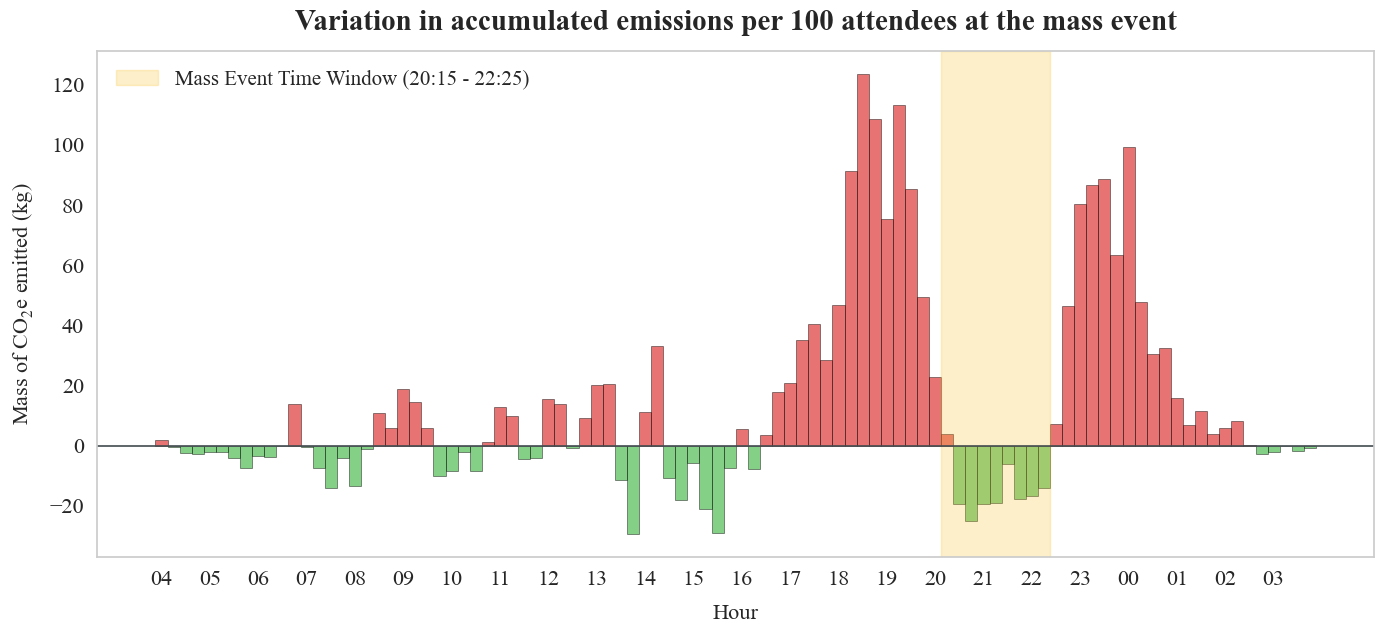


POLLUTANT INVENTORY (BOTTOM-UP METHOD)
Pollutant            | Base Mass (kg)  | Event Mass (kg)  | Net Delta (kg)
-------------------------------------------------------------------------
CO2_Equiv            |        3,260.15 |         4,453.89 |       +1,193.74
NOx                  |           24.32 |            32.61 |           +8.28
PM25                 |            0.42 |             0.57 |           +0.15


In [32]:
# ========================================================
# 4. VISUALIZACIÓN ACUMULADA
# ========================================================
agg_normalizado = agg_acumulado.copy()

# Configuración de tipografía académica homogénea
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams['axes.grid'] = False

fig, ax = plt.subplots(figsize=(14, 6.5))
x_indices = np.arange(96)

# Paleta de colores semi-transparentes estilo Paper Científico
# Verde suave para ahorro (#4CAF50), Rojo/Naranja suave para incremento (#FF5722)
colores_relleno = np.where(agg_acumulado['Delta_CO2_kg'].fillna(0) >= 0, "#D71616", "#32B136")
colores_borde = np.where(agg_acumulado['Delta_CO2_kg'].fillna(0) >= 0, "#000000", "#000000")

# Dibujar barras con transparencia en el relleno (alpha=0.35) y borde sólido fuerte
ax.bar(x_indices, agg_acumulado['Delta_CO2_kg'], 
       color=colores_relleno, alpha=0.6,
       edgecolor=colores_borde, linewidth=0.5, width=1)

# # Dibujar el histograma de densidad y pintar individualmente las barras
# n, bins, patches = ax.hist(user_delta['Delta_CO2_kg'], bins=30, edgecolor='black', linewidth=0.5, alpha=0.6, density=True)
# for patch, left, right in zip(patches, bins[:-1], bins[1:]):
#     center = (left + right) / 2.0
#     if center >= 0:
#         patch.set_facecolor("#D71616")
#     else:
#         patch.set_facecolor("#32B136")

# Sombreado de la duración del evento (Ajustado a gris tenue para no competir con las barras)
partido_indices = agg_acumulado[(agg_acumulado['time_str'] >= hora_inicio_partido) & (agg_acumulado['time_str'] <= hora_fin_partido)].index
if len(partido_indices) > 0:
    idx_ini = partido_indices[0]
    idx_fin = partido_indices[-1]
    ax.axvspan(idx_ini - 0.5, idx_fin + 0.5, color="#FBC02D", alpha=0.25, 
               label=f'Mass Event Time Window ({hora_inicio_partido} - {hora_fin_partido})')
    
# Línea base de control (Diferencial cero)
ax.axhline(0, color="#434C50", linewidth=1.2, linestyle='-')

# Títulos con automatización dinámica de N usuarios
ax.set_title(f"Variation in accumulated emissions per {CANTIDAD_USUARIOS} attendees at the mass event", 
             fontsize=21, fontweight='bold', pad=15)

# CORRECCIÓN DE FUENTE: \mathregular evita que el subíndice cambie a la tipografía default de LaTeX
ax.set_ylabel(r"Mass of $\mathregular{CO_{2}e}$ emitted (kg)", fontsize=16, labelpad=10)
ax.set_xlabel("Hour", fontsize=16, labelpad=10)

# Configuración del Eje X (Etiquetas horizontales y limpias cada hora)
ticks_visibles = np.arange(0, 96, 4)
ax.set_xticks(ticks_visibles)
labels_horas = agg_normalizado['time_str'].iloc[ticks_visibles].apply(lambda x: x.split(':')[0])
ax.set_xticklabels(labels_horas, rotation=0, fontsize=16)
ax.tick_params(axis='both', labelsize=16)

# Ajustes estéticos finales
ax.grid(False)
ax.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=15, loc='upper left')

plt.tight_layout()
plt.show()

# ========================================================
# 5. INVENTARIO CONSOLIDADO
# ========================================================
df_totals = pd.DataFrame(user_totals)
total_CO2_base_kg = df_totals['CO2_base'].sum() / 1000.0
total_NOx_base_kg = df_totals['NOx_base'].sum() / 1000.0
total_PM25_base_kg = df_totals['PM25_base'].sum() / 1000.0

total_CO2_event_kg = df_totals['CO2_event'].sum() / 1000.0
total_NOx_event_kg = df_totals['NOx_event'].sum() / 1000.0
total_PM25_event_kg = df_totals['PM25_event'].sum() / 1000.0

delta_CO2_kg = total_CO2_event_kg - total_CO2_base_kg
delta_NOx_kg = total_NOx_event_kg - total_NOx_base_kg
delta_PM25_kg = total_PM25_event_kg - total_PM25_base_kg

print("\n======================================================================")
print("POLLUTANT INVENTORY (BOTTOM-UP METHOD)")
print("======================================================================")
print("Pollutant            | Base Mass (kg)  | Event Mass (kg)  | Net Delta (kg)")
print("-------------------------------------------------------------------------")
print(f"CO2_Equiv            | {total_CO2_base_kg:15,.2f} | {total_CO2_event_kg:16,.2f} | {delta_CO2_kg:+15,.2f}")
print(f"NOx                  | {total_NOx_base_kg:15,.2f} | {total_NOx_event_kg:16,.2f} | {delta_NOx_kg:+15,.2f}")
print(f"PM25                 | {total_PM25_base_kg:15,.2f} | {total_PM25_event_kg:16,.2f} | {delta_PM25_kg:+15,.2f}")
print("======================================================================")

Calculating normalized emission rate for 97 users...


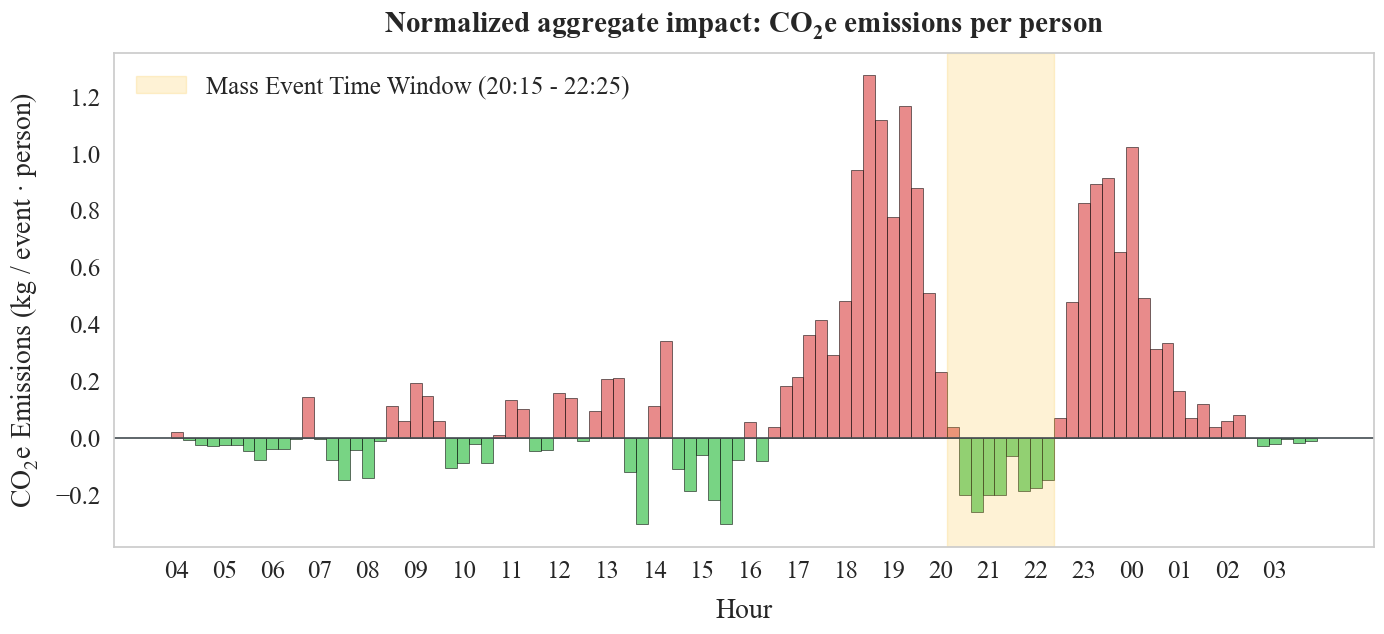

In [33]:
# ==============================================================================
# MÓDULO 4 - FASE MICRO (BOTTOM-UP) VISUALIZACIÓN NORMALIZADA INDIVIDUAL
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Determinar dinámicamente la cantidad de usuarios procesados en la muestra
# Evitamos definir constantes fijas para permitir cambios dinámicos de escala
if 'user_totals' in globals() and len(user_totals) > 0:
    N_usuarios = len(user_totals)
elif 'usuarios_muestrear' in globals():
    N_usuarios = len(usuarios_muestrear)
else:
    # Fallback por seguridad
    N_usuarios = 97

print(f"Calculating normalized emission rate for {N_usuarios} users...")

# Copia del dataframe de agregación acumulada para evitar alterar datos previos
agg_normalizado = agg_acumulado.copy()

# Normalización por usuario (kg / 15-min · persona)
# Dividimos por N_usuarios para obtener la emisión individual promedio por cada intervalo de 15 minutos
agg_normalizado['Delta_CO2_normalized_kg_person'] = agg_normalizado['Delta_CO2_kg'] / N_usuarios

# Configurar estilo visual académico homogéneo
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams['axes.grid'] = False

fig, ax = plt.subplots(figsize=(14, 6.5))

x_indices = np.arange(96)

# Paleta de colores semi-transparentes estilo Paper Científico
colores_relleno = np.where(agg_normalizado['Delta_CO2_normalized_kg_person'].fillna(0) >= 0, "#E16464", "#4BC65B")
colores_borde = np.where(agg_normalizado['Delta_CO2_normalized_kg_person'].fillna(0) >= 0, "#000000", "#000000")

    #     patch.set_facecolor("#FC7B7B")
    # else:
    #     patch.set_facecolor("#5CD46C")

# Dibujar barras con transparencia en el relleno (alpha=0.64) y borde sólido fuerte
ax.bar(x_indices, agg_normalizado['Delta_CO2_normalized_kg_person'], 
       color=colores_relleno, alpha=0.75,
       edgecolor=colores_borde, linewidth=0.5, width=1)

# Sombreado de la duración del partido si las variables globales existen
if 'hora_inicio_partido' in globals() and 'hora_fin_partido' in globals():
    partido_indices = agg_normalizado[(agg_normalizado['time_str'] >= hora_inicio_partido) & (agg_normalizado['time_str'] <= hora_fin_partido)].index
    if len(partido_indices) > 0:
        idx_ini = partido_indices[0]
        idx_fin = partido_indices[-1]
        ax.axvspan(idx_ini - 0.5, idx_fin + 0.5, color="#FBC02D", alpha=0.2, 
                   label=f'Mass Event Time Window ({hora_inicio_partido} - {hora_fin_partido})')

# Línea horizontal de referencia en 0 (Gris oscuro sólido homogéneo)
ax.axhline(0, color="#434C50", linewidth=1.2, linestyle='-')

# Configuración formal de títulos y etiquetas corregidas
ax.set_title(r"Normalized aggregate impact: $\mathregular{CO_{2}e}$ emissions per person", fontsize=21, fontweight='bold', pad=15)
ax.set_ylabel(r"$\mathregular{CO_{2}e}$ Emissions (kg / event · person)", fontsize=20, labelpad=10)
ax.set_xlabel("Hour", fontsize=20, labelpad=10)

# Mostrar una etiqueta cada 4 bloques con eje horizontal (sin inclinación) y escalado de fuentes a 16
ticks_visibles = np.arange(0, 96, 4)
ax.set_xticks(ticks_visibles)
labels_horas = agg_normalizado['time_str'].iloc[ticks_visibles].apply(lambda x: x.split(':')[0])
ax.set_xticklabels(labels_horas, rotation=0, fontsize=18)
ax.tick_params(axis='both', labelsize=18)

# Ajustes estéticos finales de leyenda
ax.grid(False)
ax.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=18, loc='upper left')

plt.tight_layout()
plt.show()


### MICRO ANALYSIS DEEPDIVE

Loading spatial and traffic flow columns...
Calculating percentage change in operational speed compared to baseline...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Plotting kinematic emission curves...


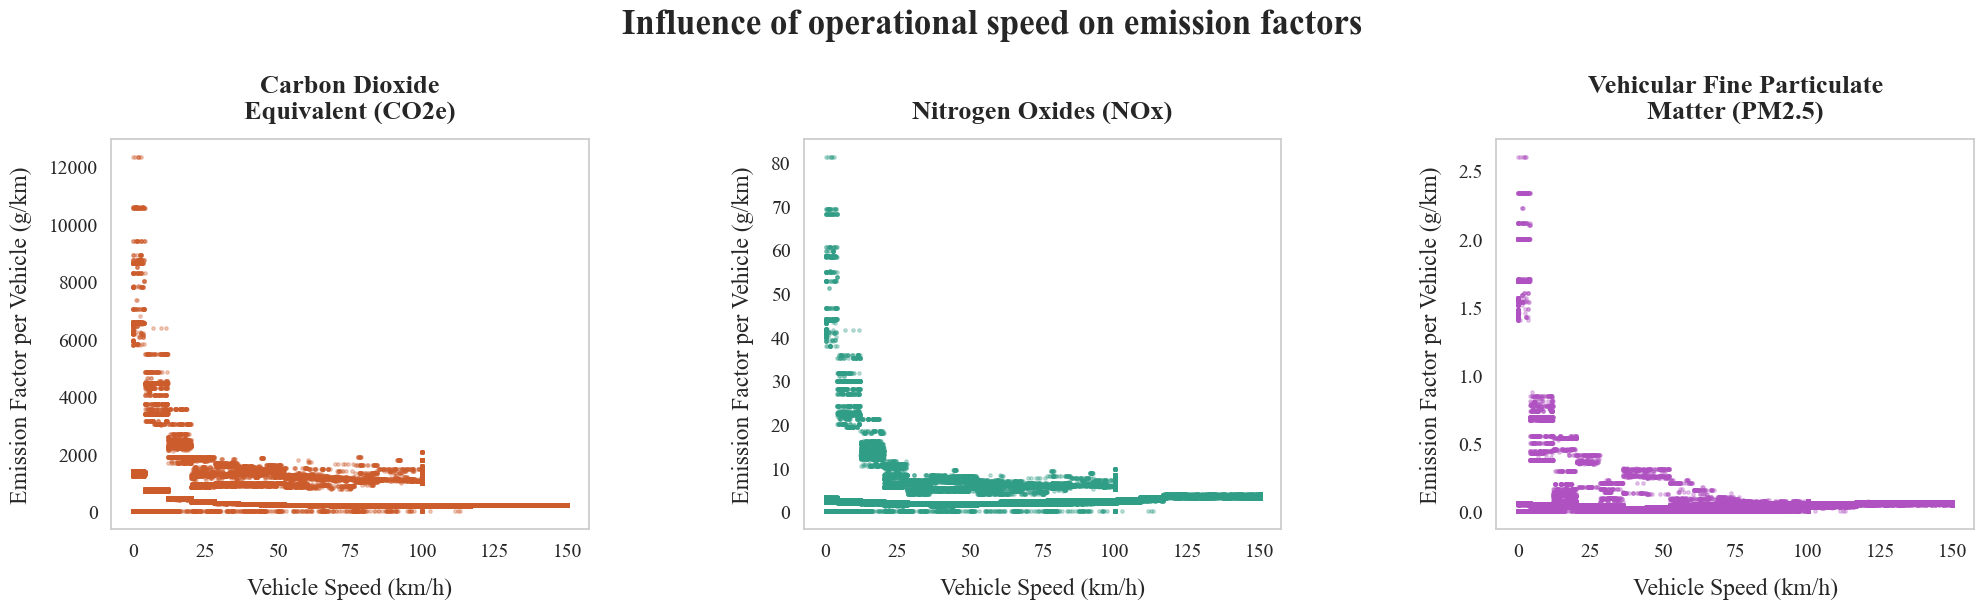

Evaluating radial dispersion in concentric geofences...
Evaluating impact by road infrastructure...



### CONCENTRIC GEOFENCES ANALYSIS (BUFFER ANALYSIS)

| Concentric Zone | CO2e Base (kg) | CO2e Event (kg) | CO2e Delta (kg) | NOx Base (kg) | NOx Event (kg) | NOx Delta (kg) | PM2.5 Base (kg) | PM2.5 Event (kg) | PM2.5 Delta (kg) |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Core Zone (0-1 km) | 27.76 | 384.49 | 356.74 | 0.21 | 2.13 | 1.92 | 0.00 | 0.04 | 0.03 |
| Access Zone (1-3 km) | 132.04 | 430.53 | 298.49 | 0.98 | 3.00 | 2.02 | 0.02 | 0.05 | 0.03 |
| Influence Zone (3-5 km) | 247.38 | 506.68 | 259.30 | 1.77 | 3.74 | 1.97 | 0.03 | 0.07 | 0.04 |
| Outer Zone (>5 km) | 2,393.48 | 3,132.32 | 738.84 | 17.84 | 23.74 | 5.90 | 0.31 | 0.41 | 0.11 |

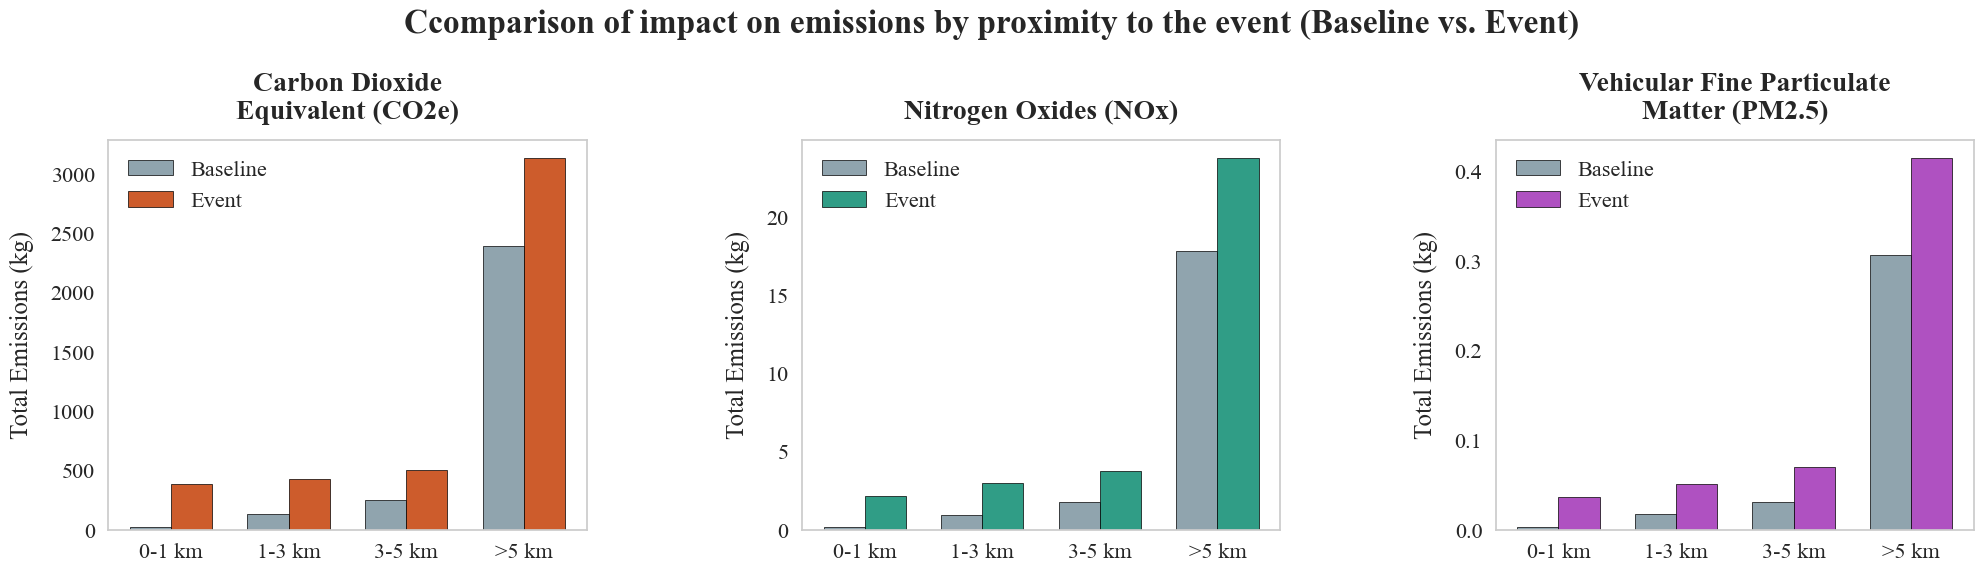


### TOP 5 ROAD CORRIDORS WITH HIGHEST ABSOLUTE EMISSIONS INCREASE

| Road ID (OSM) | Classification | CO2e Base (kg) | CO2e Event (kg) | Delta CO2e (kg) | Baseline Speed (km/h) | Velocidad Event (km/h) | Speed Drop (km/h) |
| :--- | :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| 575699481 | secondary | 1.75 | 39.47 | 37.72 | 71.31 | 81.42 | -10.11 |
| 431249469 | unclassified | 1.12 | 36.01 | 34.89 | 26.41 | 27.62 | -1.21 |
| 575699492 | tertiary | 0.75 | 19.06 | 18.31 | 37.46 | 49.11 | -11.65 |
| 782771026 | trunk | 4.21 | 21.19 | 16.97 | 84.19 | 68.78 | 15.41 |
| 90526192 | trunk | 4.35 | 20.59 | 16.25 | 87.23 | 67.10 | 20.14 |


### TOP 5 RESILIENT ROAD CORRIDORS (BASELINE ROAD PERCENTILE > 60% AND DELTA CO2 <= 0.1 kg)

| Road ID (OSM) | Classification | Pings Base | CO2e Base (kg) | CO2e Event (kg) | Delta CO2e (kg) | Baseline Speed (km/h) | Velocidad Event (km/h) | Speed Drop (km/h) |
| :--- | :--- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| 79761888 | residential | 649 | 8.39 | 0.62 | -7.77 | 17.73 | 15.42 | 2.31 |
| 869965206 | tertiary | 1,276 | 3.70 | 0.18 | -3.52 | 47.86 | 45.07 | 2.79 |
| 140259397 | residential | 1,327 | 4.72 | 1.42 | -3.30 | 27.74 | 26.78 | 0.96 |
| 777760024 | tertiary | 444 | 3.20 | 0.18 | -3.02 | 37.06 | 68.35 | -31.29 |
| 802740088 | tertiary | 767 | 3.82 | 1.24 | -2.58 | 74.09 | 84.75 | -10.66 |

In [34]:
# ==============================================================================
# MÓDULO 4 - FASE MICRO: ANÁLISIS GEOSPACIAL Y CINEMÁTICO AVANZADO DISGREGADO
# ==============================================================================

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import sys
from IPython.display import display, Markdown

# Configurar encoding utf-8 para evitar errores de consola en Windows
if sys.stdout.encoding != 'utf-8':
    try:
        sys.stdout.reconfigure(encoding='utf-8')
    except Exception:
        pass

# --- VALIDACIÓN DE VARIABLES EN MEMORIA ---
if 'df_all_users' not in globals() or 'usuarios_muestrear' not in globals() or 'input_file' not in globals():
    input_file = "Outputs\\Final Outputs\\Resultados_Datos_Emisiones_GPS_100_all_v1.1.parquet"
    DIA_DEL_EVENTO_MES = 26
    CANTIDAD_USUARIOS = 100
    
    print("Initializing control sample due to absence of global variables...")
    meta = pq.read_table(input_file, columns=['caid', 'local_timestamp'])
    meta_df = meta.to_pandas()
    meta_df['local_timestamp'] = pd.to_datetime(meta_df['local_timestamp'], format='mixed')
    meta_df['ts_logico'] = meta_df['local_timestamp'] - pd.Timedelta(hours=4)
    meta_df['dia_del_mes'] = meta_df['ts_logico'].dt.day
    meta_df['dia_semana'] = meta_df['ts_logico'].dt.dayofweek
 
    usuarios_evento = meta_df[meta_df['dia_del_mes'] == DIA_DEL_EVENTO_MES]['caid'].unique()
    usuarios_base = meta_df[(meta_df['dia_del_mes'] != DIA_DEL_EVENTO_MES) & (meta_df['dia_semana'] < 4)]['caid'].unique()
    usuarios_validos = np.intersect1d(usuarios_evento, usuarios_base)

    np.random.seed(42)
    if len(usuarios_validos) < CANTIDAD_USUARIOS:
        usuarios_muestrear = usuarios_validos
    else:
        usuarios_muestrear = np.random.choice(usuarios_validos, size=CANTIDAD_USUARIOS, replace=False)
        
    df_all_users = pd.read_parquet(
        input_file,
        filters=[('caid', 'in', list(usuarios_muestrear))],
        columns=['caid', 'local_timestamp', 'modo_transporte', 'Total_CO2_Equiv_g', 'Total_NOx_g', 'Total_PM25_g', 'latitude', 'longitude']
    )
    print(f"Sample successfully initialized with {len(usuarios_muestrear)} usuarios.")


# ========================================================
# 1. INGESTA Y PREPARACIÓN DE COLUMNAS AVANZADAS
# ========================================================
print("Loading spatial and traffic flow columns...")
df_extra = pd.read_parquet(
    input_file,
    filters=[('caid', 'in', list(usuarios_muestrear))],
    columns=['caid', 'local_timestamp', 'osmid', 'highway', 'Speed [km/h]', 'Densidad_CO2_Equiv_g_km', 'Densidad_NOx_g_km', 'Densidad_PM25_g_km']
)

df_extra['local_timestamp'] = pd.to_datetime(df_extra['local_timestamp'], format='mixed')
df_all_users['local_timestamp'] = pd.to_datetime(df_all_users['local_timestamp'], format='mixed')

# Fusión con los pings en movimiento generados en la celda anterior
df_adv = pd.merge(df_all_users, df_extra, on=['caid', 'local_timestamp'], how='inner')

# Configuración del tiempo lógico
df_adv['ts_logico'] = df_adv['local_timestamp'] - pd.Timedelta(hours=4)
df_adv['dia_del_mes'] = df_adv['ts_logico'].dt.day
df_adv['dia_semana'] = df_adv['ts_logico'].dt.dayofweek
df_adv['date_logico'] = df_adv['ts_logico'].dt.date
df_adv['time_logico'] = df_adv['ts_logico'].dt.floor('15min').dt.time

df_adv_base = df_adv[(df_adv['dia_del_mes'] != DIA_DEL_EVENTO_MES) & (df_adv['dia_semana'] < 4)].copy()
df_adv_event = df_adv[df_adv['dia_del_mes'] == DIA_DEL_EVENTO_MES].copy()

# ========================================================
# 2. DEGRADACIÓN VIAL E INFLEXIÓN CINEMÁTICA
# ========================================================
print("Calculating percentage change in operational speed compared to baseline...")
baseline_speed = df_adv_base.groupby(['osmid', 'time_logico'])['Speed [km/h]'].mean().reset_index().rename(columns={'Speed [km/h]': 'Speed_base_mean'})
df_event_speed = pd.merge(df_adv_event, baseline_speed, on=['osmid', 'time_logico'], how='left')
df_event_speed['Speed_pct_change'] = ((df_event_speed['Speed [km/h]'] - df_event_speed['Speed_base_mean']) / (df_event_speed['Speed_base_mean'] + 0.001)) * 100

# Gráfico de Dispersión de Emisiones
print("Plotting kinematic emission curves...")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

df_plot = df_event_speed[['Speed [km/h]', 'Densidad_CO2_Equiv_g_km', 'Densidad_NOx_g_km', 'Densidad_PM25_g_km']].dropna()
df_plot = df_plot[(df_plot['Speed [km/h]'] >= 0) & (df_plot['Speed [km/h]'] <= 150)]

if not df_plot.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
    
    # 1. CO2e
    axes[0].scatter(df_plot['Speed [km/h]'], df_plot['Densidad_CO2_Equiv_g_km'], color="#CD5C2C", alpha=0.3, s=6)
    axes[0].set_title("Carbon Dioxide\nEquivalent (CO2e)", fontsize=19, fontweight='bold', pad=15)
    axes[0].set_xlabel("Vehicle Speed (km/h)", fontsize=17, labelpad=12)
    axes[0].set_ylabel("Emission Factor per Vehicle (g/km)", fontsize=17, labelpad=12)
    axes[0].tick_params(axis='both', labelsize=14)
    axes[0].grid(False)
    axes[0].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=14)
    
    # 2. NOx
    axes[1].scatter(df_plot['Speed [km/h]'], df_plot['Densidad_NOx_g_km'], color="#309D86", alpha=0.3, s=6)
    axes[1].set_title("Nitrogen Oxides (NOx)", fontsize=19, fontweight='bold', pad=15)
    axes[1].set_xlabel("Vehicle Speed (km/h)", fontsize=17, labelpad=12)
    axes[1].set_ylabel("Emission Factor per Vehicle (g/km)", fontsize=17, labelpad=12)
    axes[1].tick_params(axis='both', labelsize=14)
    axes[1].grid(False)
    axes[1].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=14)
    
    # 3. PM2.5
    axes[2].scatter(df_plot['Speed [km/h]'], df_plot['Densidad_PM25_g_km'], color="#AF51C1", alpha=0.3, s=6)
    axes[2].set_title("Vehicular Fine Particulate\nMatter (PM2.5)", fontsize=19, fontweight='bold', pad=15)
    axes[2].set_xlabel("Vehicle Speed (km/h)", fontsize=17, labelpad=12)
    axes[2].set_ylabel("Emission Factor per Vehicle (g/km)", fontsize=17, labelpad=12)
    axes[2].tick_params(axis='both', labelsize=14)
    axes[2].grid(False)
    axes[2].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=14)
    
    # Un solo título general superior para las tres subgráficas
    fig.suptitle("Influence of operational speed on emission factors", fontsize=25, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.78, bottom=0.18, wspace=0.45)
    plt.show()
else:
    print("No valid records found for the kinematic plot.")

# ========================================================
# 3. ANÁLISIS ESPACIAL DE GEOCERCAS CONCÉNTRICAS
# ========================================================
print("Evaluating radial dispersion in concentric geofences...")
lat_estadio = 25.6692
lon_estadio = -100.2444

def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df_adv['dist_estadio'] = haversine_vectorized(df_adv['latitude'], df_adv['longitude'], lat_estadio, lon_estadio)

conds = [
    (df_adv['dist_estadio'] >= 0.0) & (df_adv['dist_estadio'] < 1.0),
    (df_adv['dist_estadio'] >= 1.0) & (df_adv['dist_estadio'] < 3.0),
    (df_adv['dist_estadio'] >= 3.0) & (df_adv['dist_estadio'] <= 5.0),
    (df_adv['dist_estadio'] > 5.0)
]
choices = ['Core Zone (0-1 km)', 'Access Zone (1-3 km)', 'Influence Zone (3-5 km)', 'Outer Zone (>5 km)']
df_adv['buffer_zone'] = np.select(conds, choices, default='Fuera de Rango')

df_base_buf = df_adv[(df_adv['dia_del_mes'] != DIA_DEL_EVENTO_MES) & (df_adv['dia_semana'] < 4) & (df_adv['buffer_zone'] != 'Fuera de Rango')].copy()
df_event_buf = df_adv[(df_adv['dia_del_mes'] == DIA_DEL_EVENTO_MES) & (df_adv['buffer_zone'] != 'Fuera de Rango')].copy()

# Obtener los días de línea base activos por cada usuario para evitar inflar el denominador
active_user_days = df_adv_base.groupby(['caid', 'date_logico']).size().reset_index()[['caid', 'date_logico']]

# Generar la grilla expandiendo los días activos por las zonas buffer correspondientes (choices)
df_choices = pd.DataFrame({'buffer_zone': choices})
grid_buf = active_user_days.merge(df_choices, how='cross')

# Agrupar las emisiones reales
base_grouped_buf = df_base_buf.groupby(['caid', 'date_logico', 'buffer_zone'])[['Total_CO2_Equiv_g', 'Total_NOx_g', 'Total_PM25_g']].sum().reset_index()
base_grid_buf = pd.merge(grid_buf, base_grouped_buf, on=['caid', 'date_logico', 'buffer_zone'], how='left')

# Imputación de ceros para las zonas no transitadas en días activos
for col in ['Total_CO2_Equiv_g', 'Total_NOx_g', 'Total_PM25_g']:
    base_grid_buf[col] = base_grid_buf[col].fillna(0.0)

# Calcular el promedio diario real por usuario (basado únicamente en sus días de monitoreo activo)
baseline_buf_user = base_grid_buf.groupby(['caid', 'buffer_zone'])[['Total_CO2_Equiv_g', 'Total_NOx_g', 'Total_PM25_g']].mean().reset_index()
baseline_buf_total = baseline_buf_user.groupby('buffer_zone')[['Total_CO2_Equiv_g', 'Total_NOx_g', 'Total_PM25_g']].sum().reset_index()
baseline_buf_total.columns = ['buffer_zone', 'CO2_base', 'NOx_base', 'PM25_base']

# Emisiones observadas durante el día de evento por buffer
event_grouped_buf = df_event_buf.groupby(['caid', 'buffer_zone'])[['Total_CO2_Equiv_g', 'Total_NOx_g', 'Total_PM25_g']].sum().reset_index()
grid_buf_ev_idx = pd.MultiIndex.from_product(
    [usuarios_muestrear, choices],
    names=['caid', 'buffer_zone']
)
grid_buf_ev = pd.DataFrame(index=grid_buf_ev_idx).reset_index()

event_grid_buf = pd.merge(grid_buf_ev, event_grouped_buf, on=['caid', 'buffer_zone'], how='left').fillna(0.0)
event_buf_total = event_grid_buf.groupby('buffer_zone')[['Total_CO2_Equiv_g', 'Total_NOx_g', 'Total_PM25_g']].sum().reset_index()
event_buf_total.columns = ['buffer_zone', 'CO2_event', 'NOx_event', 'PM25_event']

buf_comparison = pd.merge(baseline_buf_total, event_buf_total, on='buffer_zone')

for p in ['CO2', 'NOx', 'PM25']:
    buf_comparison[f'{p}_base_kg'] = buf_comparison[f'{p}_base'] / 1000.0
    buf_comparison[f'{p}_event_kg'] = buf_comparison[f'{p}_event'] / 1000.0
    buf_comparison[f'{p}_delta_kg'] = buf_comparison[f'{p}_event_kg'] - buf_comparison[f'{p}_base_kg']

# Ordenar por proximidad lógica
buf_comparison['buffer_zone'] = pd.Categorical(buf_comparison['buffer_zone'], categories=choices, ordered=True)
buf_comparison = buf_comparison.sort_values('buffer_zone').reset_index(drop=True)

# ========================================================
# 4. CORREDORES DE ALTA DEMANDA Y VÍAS RESILIENTES
# ========================================================
print("Evaluating impact by road infrastructure...")
user_days = df_adv_base.groupby('caid')['date_logico'].nunique().reset_index(name='N_u')

base_street = df_adv_base.groupby(['caid', 'osmid', 'highway']).agg(
    CO2_sum=('Total_CO2_Equiv_g', 'sum'),
    NOx_sum=('Total_NOx_g', 'sum'),
    PM25_sum=('Total_PM25_g', 'sum'),
    Speed_mean=('Speed [km/h]', 'mean')
).reset_index()

base_street = pd.merge(base_street, user_days, on='caid')
base_street['CO2_base_mean'] = base_street['CO2_sum'] / base_street['N_u']
base_street['NOx_base_mean'] = base_street['NOx_sum'] / base_street['N_u']
base_street['PM25_base_mean'] = base_street['PM25_sum'] / base_street['N_u']

base_street_total = base_street.groupby(['osmid', 'highway']).agg(
    CO2_base=('CO2_base_mean', 'sum'),
    NOx_base=('NOx_base_mean', 'sum'),
    PM25_base=('PM25_base_mean', 'sum'),
    Speed_base=('Speed_mean', 'mean')
).reset_index()

event_street = df_adv_event.groupby(['osmid', 'highway']).agg(
    CO2_event=('Total_CO2_Equiv_g', 'sum'),
    NOx_event=('Total_NOx_g', 'sum'),
    PM25_event=('Total_PM25_g', 'sum'),
    Speed_event=('Speed [km/h]', 'mean')
).reset_index()

street_comparison = pd.merge(base_street_total, event_street, on=['osmid', 'highway'], how='outer')
emissions_cols = ['CO2_base', 'NOx_base', 'PM25_base', 'CO2_event', 'NOx_event', 'PM25_event']
street_comparison[emissions_cols] = street_comparison[emissions_cols].fillna(0.0)

street_comparison['CO2_base_kg'] = street_comparison['CO2_base'] / 1000.0
street_comparison['CO2_event_kg'] = street_comparison['CO2_event'] / 1000.0
street_comparison['Delta_CO2_kg'] = street_comparison['CO2_event_kg'] - street_comparison['CO2_base_kg']
street_comparison['Delta_NOx_kg'] = (street_comparison['NOx_event'] - street_comparison['NOx_base']) / 1000.0
street_comparison['Delta_PM25_kg'] = (street_comparison['PM25_event'] - street_comparison['PM25_base']) / 1000.0
street_comparison['Speed_drop_kmh'] = street_comparison['Speed_base'] - street_comparison['Speed_event']

# Identificar Corredores Resilientes (Volumen > Percentil 60 de pings base, Delta CO2 <= 0.1 kg)
pings_base = df_adv_base.groupby(['osmid', 'highway']).size().reset_index(name='pings_base')
street_comparison = pd.merge(street_comparison, pings_base, on=['osmid', 'highway'], how='left').fillna({'pings_base': 0})
p60_vol = street_comparison['pings_base'].quantile(0.60)
resilient_streets = street_comparison[(street_comparison['pings_base'] > p60_vol) & (street_comparison['Delta_CO2_kg'] <= 0.1)]

# ========================================================
# 5. IMPRESIÓN DE RESULTADOS COMPARATIVOS EN TABLAS MARKDOWN
# ========================================================
def df_to_markdown_console(df, columns_mapping, formats=None, alignments=None):
    cols = list(columns_mapping.keys())
    headers = [columns_mapping[c] for c in cols]
    
    md_lines = []
    header_str = "| " + " | ".join(headers) + " |"
    md_lines.append(header_str)
    
    sep_parts = []
    for c in cols:
        align = alignments.get(c, 'l') if alignments else 'l'
        if align == 'l':
            sep_parts.append(":---")
        elif align == 'c':
            sep_parts.append(":---:")
        elif align == 'r':
            sep_parts.append("---:")
        else:
            sep_parts.append("---")
    sep_str = "| " + " | ".join(sep_parts) + " |"
    md_lines.append(sep_str)
    
    for idx, row in df.iterrows():
        row_parts = []
        for c in cols:
            val = row[c]
            if formats and c in formats and isinstance(val, (int, float)) and not pd.isna(val):
                fmt = formats[c]
                val_str = f"{val:{fmt}}"
            else:
                val_str = str(val) if not pd.isna(val) else "N/A"
            row_parts.append(val_str)
        row_str = "| " + " | ".join(row_parts) + " |"
        md_lines.append(row_str)
    
    display(Markdown("\n".join(md_lines)))

# 1. Tabla de Análisis Espacial de Geocercas Concéntricas
display(Markdown("\n### CONCENTRIC GEOFENCES ANALYSIS (BUFFER ANALYSIS)"))
columns_mapping_buf = {
    'buffer_zone': 'Concentric Zone',
    'CO2_base_kg': 'CO2e Base (kg)',
    'CO2_event_kg': 'CO2e Event (kg)',
    'CO2_delta_kg': 'CO2e Delta (kg)',
    'NOx_base_kg': 'NOx Base (kg)',
    'NOx_event_kg': 'NOx Event (kg)',
    'NOx_delta_kg': 'NOx Delta (kg)',
    'PM25_base_kg': 'PM2.5 Base (kg)',
    'PM25_event_kg': 'PM2.5 Event (kg)',
    'PM25_delta_kg': 'PM2.5 Delta (kg)'
}
formats_buf = {c: ',.2f' for c in columns_mapping_buf if c != 'buffer_zone'}
alignments_buf = {c: 'r' for c in columns_mapping_buf if c != 'buffer_zone'}
alignments_buf['buffer_zone'] = 'l'
df_to_markdown_console(buf_comparison, columns_mapping_buf, formats_buf, alignments_buf)

# Gráfico para la Tabla 1 (Buffer zones comparison)
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
x = np.arange(len(buf_comparison['buffer_zone']))
width = 0.35

# Crear etiquetas limpias sin la palabra "Zona" ni descripciones textuales redundantes
label_map = {
    'Core Zone (0-1 km)': '0-1 km',
    'Access Zone (1-3 km)': '1-3 km',
    'Influence Zone (3-5 km)': '3-5 km',
    'Outer Zone (>5 km)': '>5 km'
}
x_labels = [label_map.get(z, z) for z in buf_comparison['buffer_zone']]

# 1. CO2e
axes[0].bar(x - width/2, buf_comparison['CO2_base_kg'], width, label='Baseline', color='#90A4AE', edgecolor='black', linewidth=0.5)
axes[0].bar(x + width/2, buf_comparison['CO2_event_kg'], width, label='Event', color='#CD5C2C', edgecolor='black', linewidth=0.5)
axes[0].set_title("Carbon Dioxide\nEquivalent (CO2e)", fontsize=20, fontweight='bold', pad=15)
axes[0].set_ylabel("Total Emissions (kg)", fontsize=18, labelpad=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, fontsize=16)
axes[0].tick_params(axis='both', labelsize=16)
axes[0].grid(False)
axes[0].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=16)

# 2. NOx
axes[1].bar(x - width/2, buf_comparison['NOx_base_kg'], width, label='Baseline', color='#90A4AE', edgecolor='black', linewidth=0.5)
axes[1].bar(x + width/2, buf_comparison['NOx_event_kg'], width, label='Event', color='#309D86', edgecolor='black', linewidth=0.5)
axes[1].set_title("Nitrogen Oxides (NOx)", fontsize=20, fontweight='bold', pad=15)
axes[1].set_ylabel("Total Emissions (kg)", fontsize=18, labelpad=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, fontsize=16)
axes[1].tick_params(axis='both', labelsize=16)
axes[1].grid(False)
axes[1].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=16)

# 3. PM2.5
axes[2].bar(x - width/2, buf_comparison['PM25_base_kg'], width, label='Baseline', color='#90A4AE', edgecolor='black', linewidth=0.5)
axes[2].bar(x + width/2, buf_comparison['PM25_event_kg'], width, label='Event', color='#AF51C1', edgecolor='black', linewidth=0.5)
axes[2].set_title("Vehicular Fine Particulate\nMatter (PM2.5)", fontsize=20, fontweight='bold', pad=15)
axes[2].set_ylabel("Total Emissions (kg)", fontsize=18, labelpad=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels(x_labels, fontsize=16)
axes[2].tick_params(axis='both', labelsize=16)
axes[2].grid(False)
axes[2].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=16)

fig.suptitle("Ccomparison of impact on emissions by proximity to the event (Baseline vs. Event)", fontsize=24, fontweight='bold', y=0.98)
plt.tight_layout()
fig.subplots_adjust(top=0.78, bottom=0.18, wspace=0.45)
plt.show()

# 2. Tabla de Top 5 Corredores Viales (Súper-Emisores inducidos)
display(Markdown("\n### TOP 5 ROAD CORRIDORS WITH HIGHEST ABSOLUTE EMISSIONS INCREASE"))
top_5_castigadas = street_comparison.sort_values(by='Delta_CO2_kg', ascending=False).head(5)
columns_mapping_castigadas = {
    'osmid': 'Road ID (OSM)',
    'highway': 'Classification',
    'CO2_base_kg': 'CO2e Base (kg)',
    'CO2_event_kg': 'CO2e Event (kg)',
    'Delta_CO2_kg': 'Delta CO2e (kg)',
    'Speed_base': 'Baseline Speed (km/h)',
    'Speed_event': 'Velocidad Event (km/h)',
    'Speed_drop_kmh': 'Speed Drop (km/h)'
}
formats_castigadas = {c: ',.2f' for c in columns_mapping_castigadas if c not in ['osmid', 'highway']}
alignments_castigadas = {c: 'r' for c in columns_mapping_castigadas if c not in ['osmid', 'highway']}
alignments_castigadas['osmid'] = 'l'
alignments_castigadas['highway'] = 'l'
df_to_markdown_console(top_5_castigadas, columns_mapping_castigadas, formats_castigadas, alignments_castigadas)

# 3. Tabla de Top 5 Corredores Resilientes
display(Markdown("\n### TOP 5 RESILIENT ROAD CORRIDORS (BASELINE ROAD PERCENTILE > 60% AND DELTA CO2 <= 0.1 kg)"))
top_5_resilientes = resilient_streets.sort_values(by='Delta_CO2_kg', ascending=True).head(5)
columns_mapping_resilientes = {
    'osmid': 'Road ID (OSM)',
    'highway': 'Classification',
    'pings_base': 'Pings Base',
    'CO2_base_kg': 'CO2e Base (kg)',
    'CO2_event_kg': 'CO2e Event (kg)',
    'Delta_CO2_kg': 'Delta CO2e (kg)',
    'Speed_base': 'Baseline Speed (km/h)',
    'Speed_event': 'Velocidad Event (km/h)',
    'Speed_drop_kmh': 'Speed Drop (km/h)'
}

formats_resilientes = {c: ',.2f' for c in columns_mapping_resilientes if c not in ['osmid', 'highway', 'pings_base']}
formats_resilientes['pings_base'] = ',.0f'
alignments_resilientes = {c: 'r' for c in columns_mapping_resilientes if c not in ['osmid', 'highway']}
alignments_resilientes['osmid'] = 'l'
alignments_resilientes['highway'] = 'l'
df_to_markdown_console(top_5_resilientes, columns_mapping_resilientes, formats_resilientes, alignments_resilientes)

Loading data from emissions file for diagnosis...
Data loaded successfully.
Processing disaggregated road data by segment...


### TABLE 1: GLOBAL POOL IMPACT INVENTORY (MICRO BOTTOM-UP METHOD)
| Pollutant | Base Mass (kg) | Event Mass (kg) | Net Delta (kg) | % Change |
| :--- | :--- | :--- | :--- | :--- |
| CO2e | 3,260.15 | 4,453.89 | +1,193.74 | +36.62 |
| NOx | 24.32 | 32.61 | +8.28 | +34.04 |
| PM2.5 | 0.42 | 0.57 | +0.15 | +35.53 |


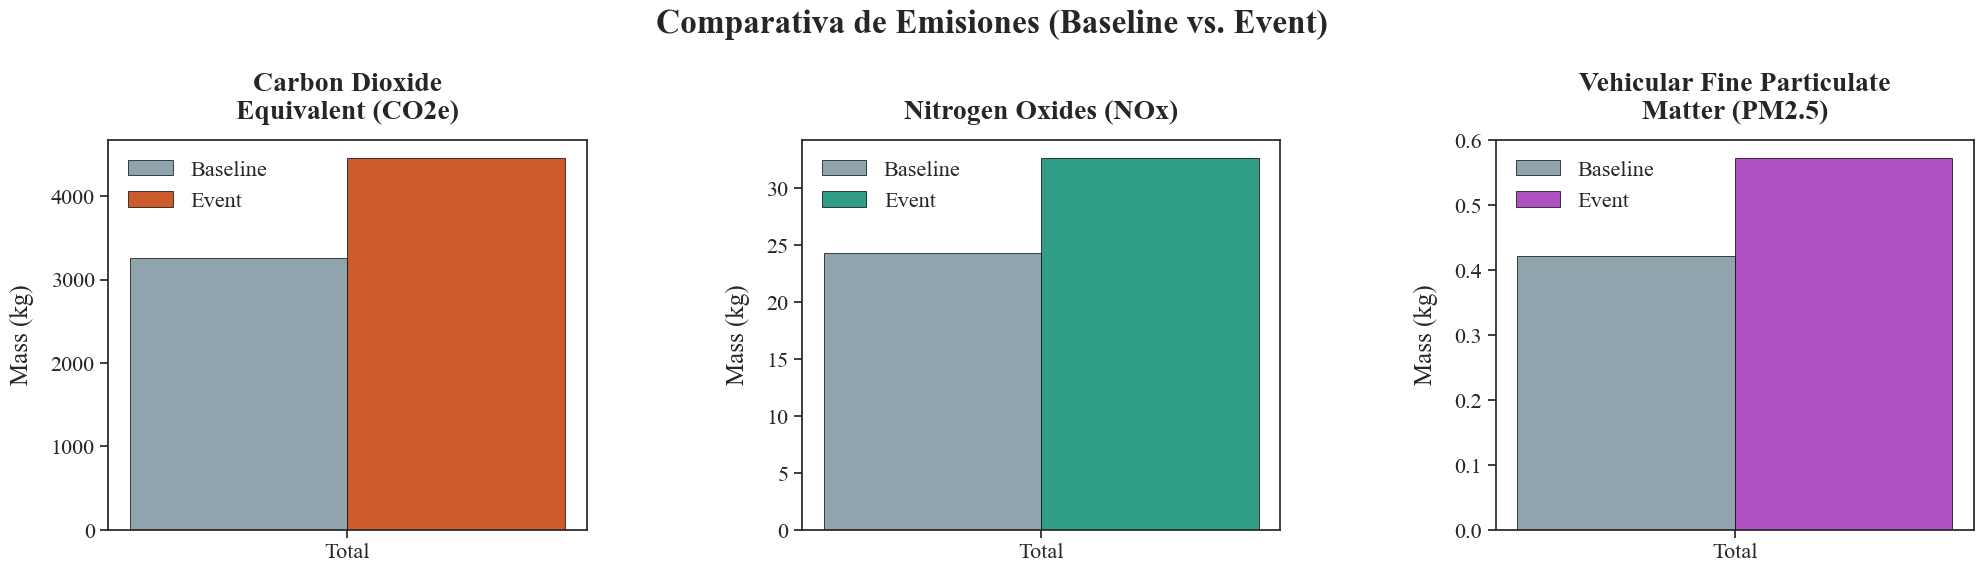

### TABLE 2: TOP 5 CRITICAL CORRIDORS (HIGHEST NORMALIZED CO2e DELTA)
| Road ID (OSM) | Classification | Baseline Volume (pings/day) | Volumen Event (pings) | % Volume Increase | CO2e Base (kg/day) | CO2e Event (kg) | Delta CO2e (kg) | % CO2e Increase | Normalized CO2e Delta (kg/km) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 431249466 | tertiary | 43.4 | 922 | +2,026.48 | 0.45 | 11.59 | +11.14 | +2,457.57 | +663.25 |
| 575699481 | secondary | 38.9 | 654 | +1,583.36 | 1.59 | 39.89 | +38.30 | +2,405.69 | +371.47 |
| 488114046 | secondary | 43.6 | 534 | +1,123.34 | 0.73 | 16.70 | +15.97 | +2,193.98 | +358.11 |
| 575699492 | tertiary | 35.8 | 506 | +1,314.59 | 1.20 | 19.52 | +18.32 | +1,532.45 | +293.36 |
| 83296522 | secondary | 26.4 | 437 | +1,553.93 | 0.61 | 14.87 | +14.26 | +2,343.84 | +229.25 |


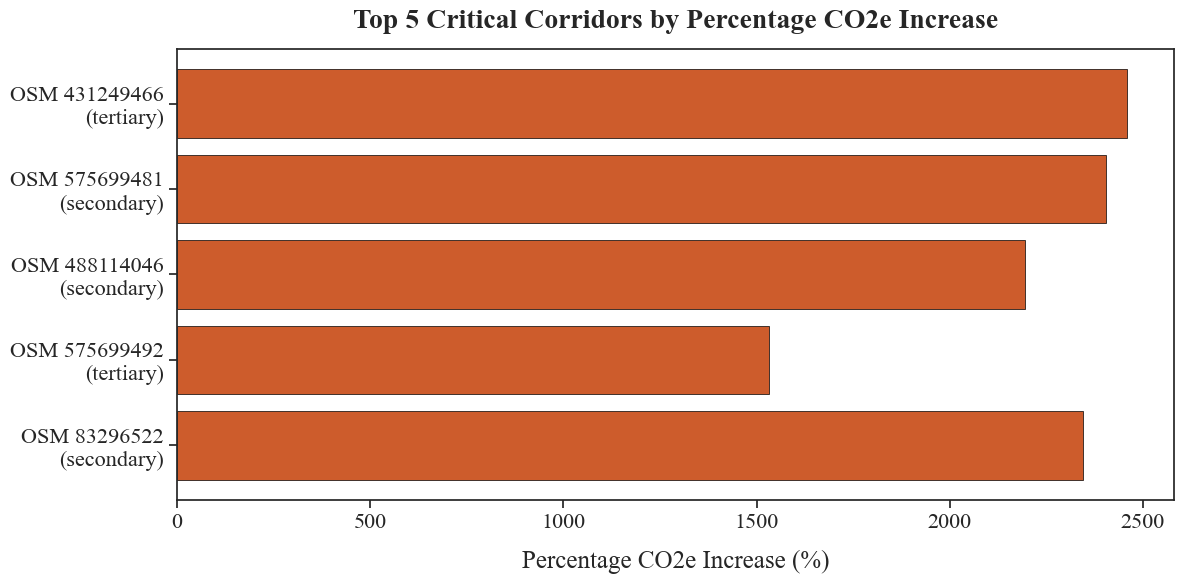

### TABLE 3: TOP 5 REAL RESILIENT CORRIDORS (BASELINE DEMAND PERCENTILE >= 60)
| Road ID (OSM) | Classification | Baseline Demand (kg CO2e/day) | Normalized CO2e Delta (kg/km) | % CO2e Reduction |
| :--- | :--- | :--- | :--- | :--- |
| 79761888 | residential | 7.92 | -127.80 | -92.22 |
| 869965206 | tertiary | 3.74 | -99.88 | -95.21 |
| 752728269 | residential | 2.40 | -40.79 | -75.37 |
| 155917802 | residential | 2.44 | -40.45 | -83.13 |
| 140259397 | residential | 4.72 | -34.50 | -69.91 |


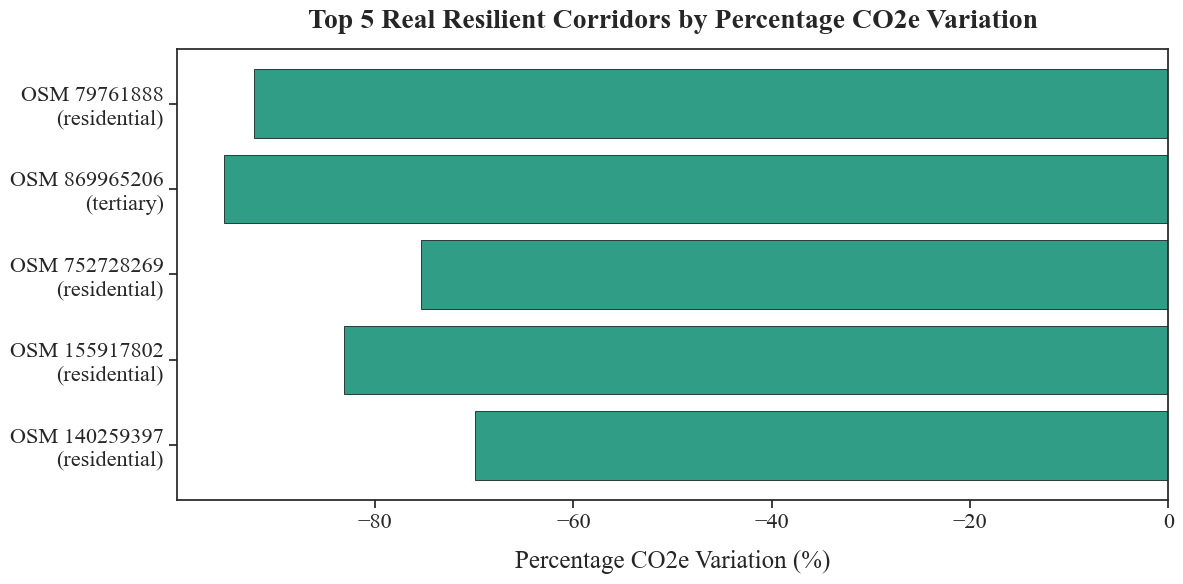

In [35]:
# ==============================================================================
# DIAGNÓSTICO AVANZADO POR ARISTAS VIALES Y CONDUCTA INDIVIDUAL
# ==============================================================================

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Configurar estilo visual académico
sns.set_theme(style="ticks")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams['axes.grid'] = False

# --- CARGAR VARIABLES DESDE EL ENTORNO GLOBAL ---
if 'input_file' not in globals():
    input_file = "Outputs\\Final Outputs\\Resultados_Datos_Emisiones_GPS_100_all_v1.1.parquet"
    
if 'DIA_DEL_EVENTO_MES' not in globals():
    DIA_DEL_EVENTO_MES = 26

# Cargamos siempre los datos frescos desde el archivo parquet con las columnas necesarias
print("Loading data from emissions file for diagnosis...")
df_data = pd.read_parquet(
    input_file,
    columns=['caid', 'local_timestamp', 'osmid', 'highway', 'Total_CO2_Equiv_g', 'Total_NOx_g', 'Total_PM25_g', 'distance_km_calc']
)
df_data['local_timestamp'] = pd.to_datetime(df_data['local_timestamp'], format='mixed')
df_data['ts_logico'] = df_data['local_timestamp'] - pd.Timedelta(hours=4)
df_data['dia_del_mes'] = df_data['ts_logico'].dt.day
df_data['dia_semana'] = df_data['ts_logico'].dt.dayofweek
df_data['date_logico'] = df_data['ts_logico'].dt.date

df_adv_base_diag = df_data[(df_data['dia_del_mes'] != DIA_DEL_EVENTO_MES) & (df_data['dia_semana'] < 4)].copy()
df_adv_event_diag = df_data[df_data['dia_del_mes'] == DIA_DEL_EVENTO_MES].copy()
print("Data loaded successfully.")

# ========================================================
# 1. AGRUPACIÓN VIAL Y PROCESAMIENTO CONTRA SESGOS
# ========================================================
print("Processing disaggregated road data by segment...")

# Línea base vial (con denominador dinámico por segmento)
base_street_grouped = df_adv_base_diag.groupby(['osmid', 'highway']).agg(
    CO2_base_sum=('Total_CO2_Equiv_g', 'sum'),
    NOx_base_sum=('Total_NOx_g', 'sum'),
    PM25_base_sum=('Total_PM25_g', 'sum'),
    days_active=('date_logico', 'nunique'),
    distance_km=('distance_km_calc', 'mean'),
    volume_base=('caid', 'count')
).reset_index()

base_street_grouped['CO2_base_daily_g'] = base_street_grouped['CO2_base_sum'] / base_street_grouped['days_active']
base_street_grouped['NOx_base_daily_g'] = base_street_grouped['NOx_base_sum'] / base_street_grouped['days_active']
base_street_grouped['PM25_base_daily_g'] = base_street_grouped['PM25_base_sum'] / base_street_grouped['days_active']
base_street_grouped['volume_base_daily'] = base_street_grouped['volume_base'] / base_street_grouped['days_active']

# Escenario del evento (26 de diciembre)
event_street_grouped = df_adv_event_diag.groupby(['osmid', 'highway']).agg(
    CO2_event_g=('Total_CO2_Equiv_g', 'sum'),
    NOx_event_g=('Total_NOx_g', 'sum'),
    PM25_event_g=('Total_PM25_g', 'sum'),
    volume_event=('caid', 'count')
).reset_index()

# Filtrado de Calles Activas (Inner Merge y eliminación de ceros/NaNs)
street_comparison = pd.merge(base_street_grouped, event_street_grouped, on=['osmid', 'highway'], how='inner')
street_comparison = street_comparison[
    (street_comparison['volume_base'] > 0) & 
    (street_comparison['volume_event'] > 0) & 
    (street_comparison['CO2_base_daily_g'] > 0) & 
    (street_comparison['CO2_event_g'] > 0)
].copy()

# Conversiones a kilogramos y deltas normalizados (kg/km de calle)
for p in ['CO2', 'NOx', 'PM25']:
    street_comparison[f'{p}_base_kg'] = street_comparison[f'{p}_base_daily_g'] / 1000.0
    street_comparison[f'{p}_event_kg'] = street_comparison[f'{p}_event_g'] / 1000.0
    street_comparison[f'Delta_{p}_kg'] = street_comparison[f'{p}_event_kg'] - street_comparison[f'{p}_base_kg']
    street_comparison[f'Delta_{p}_normalized_kg_km'] = street_comparison[f'Delta_{p}_kg'] / street_comparison['distance_km']

# ========================================================
# 2. GENERACIÓN DE TABLAS DE ANÁLISIS DE RESILIENCIA VIAL
# ========================================================

# Función auxiliar para imprimir tablas en Markdown puro
def display_markdown_table(title, df, col_map, formats=None):
    cols = list(col_map.keys())
    headers = [col_map[c] for c in cols]
    
    md_lines = []
    header_str = "| " + " | ".join(headers) + " |"
    md_lines.append(header_str)
    
    sep_str = "| " + " | ".join([":---" for _ in cols]) + " |"
    md_lines.append(sep_str)
    
    for idx, row in df.iterrows():
        row_str = []
        for c in cols:
            val = row[c]
            if formats and c in formats and isinstance(val, (int, float)) and not pd.isna(val):
                row_str.append(f"{val:{formats[c]}}")
            else:
                row_str.append(str(val) if not pd.isna(val) else "N/A")
        md_lines.append("| " + " | ".join(row_str) + " |")
        
    display(Markdown(f"### {title}\n" + "\n".join(md_lines) + "\n"))

# Tabla 1: Inventario de Impacto Global del Pool (Basado en Análisis Micro Bottom-Up)
# Obtenemos las variables de referencia directamente del análisis micro de la Celda 56
if 'total_CO2_base_kg' in globals():
    base_CO2 = total_CO2_base_kg
    event_CO2 = total_CO2_event_kg
    delta_CO2 = delta_CO2_kg
    
    base_NOx = total_NOx_base_kg
    event_NOx = total_NOx_event_kg
    delta_NOx = delta_NOx_kg
    
    base_PM25 = total_PM25_base_kg
    event_PM25 = total_PM25_event_kg
    delta_PM25 = delta_PM25_kg
elif 'user_totals' in globals() and len(user_totals) > 0:
    df_totals_temp = pd.DataFrame(user_totals)
    base_CO2 = df_totals_temp['CO2_base'].sum() / 1000.0
    event_CO2 = df_totals_temp['CO2_event'].sum() / 1000.0
    delta_CO2 = event_CO2 - base_CO2
    
    base_NOx = df_totals_temp['NOx_base'].sum() / 1000.0
    event_NOx = df_totals_temp['NOx_event'].sum() / 1000.0
    delta_NOx = event_NOx - base_NOx
    
    base_PM25 = df_totals_temp['PM25_base'].sum() / 1000.0
    event_PM25 = df_totals_temp['PM25_event'].sum() / 1000.0
    delta_PM25 = event_PM25 - base_PM25
else:
    # Fallback por consistencia sumando segmentos
    base_CO2 = street_comparison['CO2_base_kg'].sum()
    event_CO2 = street_comparison['CO2_event_kg'].sum()
    delta_CO2 = street_comparison['Delta_CO2_kg'].sum()
    
    base_NOx = street_comparison['NOx_base_kg'].sum()
    event_NOx = street_comparison['NOx_event_kg'].sum()
    delta_NOx = street_comparison['Delta_NOx_kg'].sum()
    
    base_PM25 = street_comparison['PM25_base_kg'].sum()
    event_PM25 = street_comparison['PM25_event_kg'].sum()
    delta_PM25 = street_comparison['Delta_PM25_kg'].sum()

t1_rows = [
    {'contaminante': 'CO2e', 'base': base_CO2, 'event': event_CO2, 'delta': delta_CO2, 'pct': (delta_CO2 / base_CO2 * 100) if base_CO2 > 0 else 0.0},
    {'contaminante': 'NOx', 'base': base_NOx, 'event': event_NOx, 'delta': delta_NOx, 'pct': (delta_NOx / base_NOx * 100) if base_NOx > 0 else 0.0},
    {'contaminante': 'PM2.5', 'base': base_PM25, 'event': event_PM25, 'delta': delta_PM25, 'pct': (delta_PM25 / base_PM25 * 100) if base_PM25 > 0 else 0.0}
]
df_t1 = pd.DataFrame(t1_rows)
display_markdown_table("TABLE 1: GLOBAL POOL IMPACT INVENTORY (MICRO BOTTOM-UP METHOD)", df_t1, {
    'contaminante': 'Pollutant',
    'base': 'Base Mass (kg)',
    'event': 'Event Mass (kg)',
    'delta': 'Net Delta (kg)',
    'pct': '% Change'
}, formats={'base': ',.2f', 'event': ',.2f', 'delta': '+,.2f', 'pct': '+,.2f'})

# Gráfico para Tabla 1 en Cell 60 (Impacto Global del Pool)
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
x = np.arange(1)
width = 0.35

# 1. CO2e
axes[0].bar(x - width/2, [base_CO2], width, label='Baseline', color='#90A4AE', edgecolor='black', linewidth=0.5)
axes[0].bar(x + width/2, [event_CO2], width, label='Event', color='#CD5C2C', edgecolor='black', linewidth=0.5)
axes[0].set_title("Carbon Dioxide\nEquivalent (CO2e)", fontsize=20, fontweight='bold', pad=15)
axes[0].set_ylabel("Mass (kg)", fontsize=18, labelpad=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Total'], fontsize=16)
axes[0].tick_params(axis='both', labelsize=16)
axes[0].grid(False)
axes[0].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=16)

# 2. NOx
axes[1].bar(x - width/2, [base_NOx], width, label='Baseline', color='#90A4AE', edgecolor='black', linewidth=0.5)
axes[1].bar(x + width/2, [event_NOx], width, label='Event', color='#309D86', edgecolor='black', linewidth=0.5)
axes[1].set_title("Nitrogen Oxides (NOx)", fontsize=20, fontweight='bold', pad=15)
axes[1].set_ylabel("Mass (kg)", fontsize=18, labelpad=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Total'], fontsize=16)
axes[1].tick_params(axis='both', labelsize=16)
axes[1].grid(False)
axes[1].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=16)

# 3. PM2.5
axes[2].bar(x - width/2, [base_PM25], width, label='Baseline', color='#90A4AE', edgecolor='black', linewidth=0.5)
axes[2].bar(x + width/2, [event_PM25], width, label='Event', color='#AF51C1', edgecolor='black', linewidth=0.5)
axes[2].set_title("Vehicular Fine Particulate\nMatter (PM2.5)", fontsize=20, fontweight='bold', pad=15)
axes[2].set_ylabel("Mass (kg)", fontsize=18, labelpad=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Total'], fontsize=16)
axes[2].tick_params(axis='both', labelsize=16)
axes[2].grid(False)
axes[2].legend(frameon=True, facecolor='white', edgecolor='none', fontsize=16)

fig.suptitle("Comparativa de Emisiones (Baseline vs. Event)", fontsize=24, fontweight='bold', y=0.98)
plt.tight_layout()
fig.subplots_adjust(top=0.78, bottom=0.18, wspace=0.45)
plt.show()

# Tabla 2: Top 5 Corredores Críticos
top_5_criticos = street_comparison.sort_values(by='Delta_CO2_normalized_kg_km', ascending=False).head(5).copy()
top_5_criticos['pct_vol_inc'] = ((top_5_criticos['volume_event'] - top_5_criticos['volume_base_daily']) / (top_5_criticos['volume_base_daily'] + 0.001)) * 100
top_5_criticos['pct_co2_inc'] = (top_5_criticos['Delta_CO2_kg'] / top_5_criticos['CO2_base_kg']) * 100
display_markdown_table("TABLE 2: TOP 5 CRITICAL CORRIDORS (HIGHEST NORMALIZED CO2e DELTA)", top_5_criticos, {
    'osmid': 'Road ID (OSM)',
    'highway': 'Classification',
    'volume_base_daily': 'Baseline Volume (pings/day)',
    'volume_event': 'Volumen Event (pings)',
    'pct_vol_inc': '% Volume Increase',
    'CO2_base_kg': 'CO2e Base (kg/day)',
    'CO2_event_kg': 'CO2e Event (kg)',
    'Delta_CO2_kg': 'Delta CO2e (kg)',
    'pct_co2_inc': '% CO2e Increase',
    'Delta_CO2_normalized_kg_km': 'Normalized CO2e Delta (kg/km)'
}, formats={'volume_base_daily': ',.1f', 'volume_event': ',.0f', 'pct_vol_inc': '+,.2f', 'CO2_base_kg': ',.2f', 'CO2_event_kg': ',.2f', 'Delta_CO2_kg': '+,.2f', 'pct_co2_inc': '+,.2f', 'Delta_CO2_normalized_kg_km': '+,.2f'})

# Gráfico para Tabla 2 en Cell 60 (Top 5 Corredores Críticos - Porcentaje de Incremento CO2e)
fig, ax = plt.subplots(figsize=(12, 6))
y_labels = [f"OSM {row['osmid']}\n({row['highway']})" for idx, row in top_5_criticos.iterrows()]
y_pos = np.arange(len(y_labels))

ax.barh(y_pos, top_5_criticos['pct_co2_inc'], align='center', color='#CD5C2C', edgecolor='black', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=16)
ax.invert_yaxis()  # top-down
ax.set_xlabel("Percentage CO2e Increase (%)", fontsize=18, labelpad=12)
ax.set_title("Top 5 Critical Corridors by Percentage CO2e Increase", fontsize=20, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=16)
ax.grid(False)
plt.tight_layout()
plt.show()

# Tabla 3: Top 5 Corredores Resilientes Reales
p60_base_CO2 = street_comparison['CO2_base_kg'].quantile(0.60)
resilient_candidates = street_comparison[street_comparison['CO2_base_kg'] >= p60_base_CO2].copy()
top_5_resilientes = resilient_candidates.sort_values(by='Delta_CO2_normalized_kg_km', ascending=True).head(5).copy()
top_5_resilientes['pct_reduction'] = (top_5_resilientes['Delta_CO2_kg'] / top_5_resilientes['CO2_base_kg']) * 100
display_markdown_table("TABLE 3: TOP 5 REAL RESILIENT CORRIDORS (BASELINE DEMAND PERCENTILE >= 60)", top_5_resilientes, {
    'osmid': 'Road ID (OSM)',
    'highway': 'Classification',
    'CO2_base_kg': 'Baseline Demand (kg CO2e/day)',
    'Delta_CO2_normalized_kg_km': 'Normalized CO2e Delta (kg/km)',
    'pct_reduction': '% CO2e Reduction'
}, formats={'CO2_base_kg': ',.2f', 'Delta_CO2_normalized_kg_km': '+,.2f', 'pct_reduction': '+,.2f'})

# Gráfico para Tabla 3 en Cell 60 (Top 5 Corredores Resilientes Reales - Variación Porcentual)
fig, ax = plt.subplots(figsize=(12, 6))
y_labels = [f"OSM {row['osmid']}\n({row['highway']})" for idx, row in top_5_resilientes.iterrows()]
y_pos = np.arange(len(y_labels))

ax.barh(y_pos, top_5_resilientes['pct_reduction'], align='center', color='#309D86', edgecolor='black', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=16)
ax.invert_yaxis()  # top-down
ax.set_xlabel("Percentage CO2e Variation (%)", fontsize=18, labelpad=12)
ax.set_title("Top 5 Real Resilient Corridors by Percentage CO2e Variation", fontsize=20, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=16)
ax.grid(False)
plt.tight_layout()
plt.show()

Calculating emission behavior at individual behavior level...
Generating density histogram of individual deltas for 97 users...


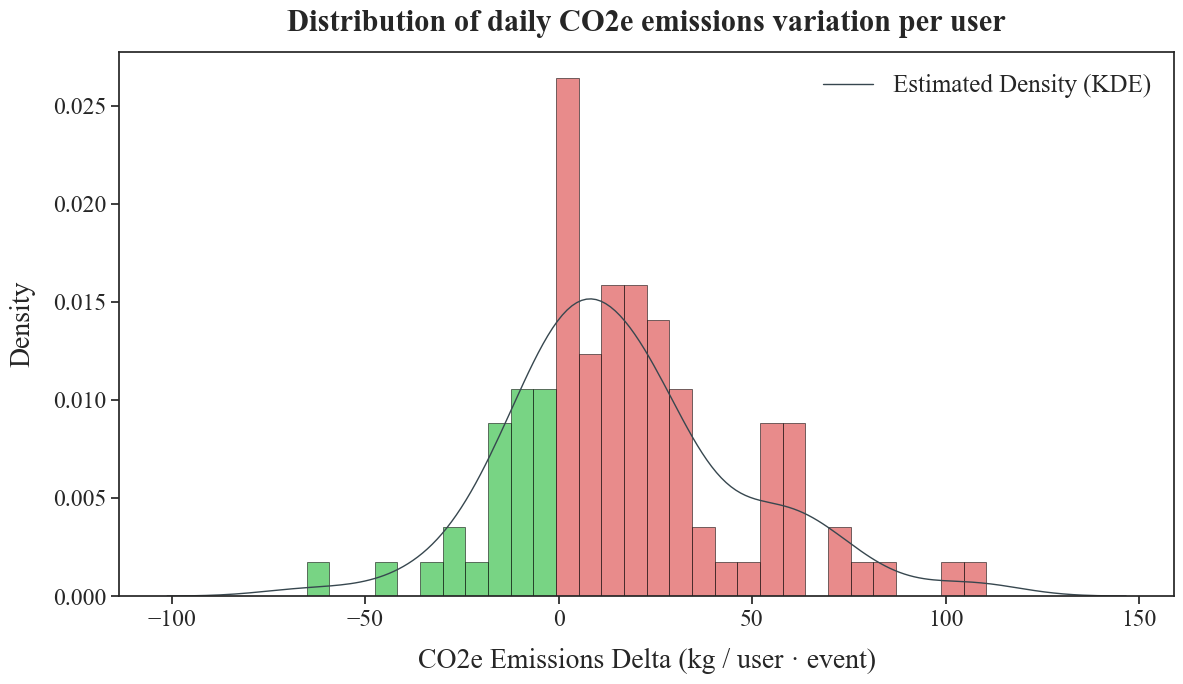

In [36]:

# ========================================================
# 3. ANÁLISIS DE CONDUCTA INDIVIDUAL Y VISUALIZACIÓN
# ========================================================
print("Calculating emission behavior at individual behavior level...")

user_base = df_adv_base_diag.groupby(['caid', 'date_logico'])['Total_CO2_Equiv_g'].sum().reset_index()
user_base_daily = user_base.groupby('caid')['Total_CO2_Equiv_g'].mean().reset_index().rename(columns={'Total_CO2_Equiv_g': 'CO2_base_daily_g'})

user_event = df_adv_event_diag.groupby('caid')['Total_CO2_Equiv_g'].sum().reset_index().rename(columns={'Total_CO2_Equiv_g': 'CO2_event_g'})

user_delta = pd.merge(user_base_daily, user_event, on='caid', how='inner')
user_delta['Delta_CO2_kg'] = (user_delta['CO2_event_g'] - user_delta['CO2_base_daily_g']) / 1000.0

print(f"Generating density histogram of individual deltas for {len(user_delta)} users...")
fig, ax = plt.subplots(figsize=(12, 7))

# Dibujar el histograma de densidad y pintar individualmente las barras
n, bins, patches = ax.hist(user_delta['Delta_CO2_kg'], bins=30, edgecolor='black', linewidth=0.5, alpha=0.75, density=True)
for patch, left, right in zip(patches, bins[:-1], bins[1:]):
    center = (left + right) / 2.0
    if center >= 0:
        patch.set_facecolor("#E16464")
    else:
        patch.set_facecolor("#4BC65B")


# Graficar curva de estimación de densidad kernel (KDE)
sns.kdeplot(user_delta['Delta_CO2_kg'], color="#37474F", ax=ax, linewidth=1, label='Estimated Density (KDE)')

ax.set_title("Distribution of daily CO2e emissions variation per user", fontsize=22, fontweight='bold', pad=15)
ax.set_xlabel("CO2e Emissions Delta (kg / user · event)", fontsize=20, labelpad=12)
ax.set_ylabel("Density", fontsize=20, labelpad=12)
ax.tick_params(axis='both', labelsize=17)
ax.grid(False)
ax.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=18)
plt.tight_layout()
plt.show()
